In [4]:
import warnings
warnings.filterwarnings("ignore")

In [5]:
import pandas as pd
from collections import deque
import matplotlib.pyplot as plt
import numpy as np

In [6]:
# Load the orders dataset
orders_df = pd.read_csv('orders-1.csv')
orders_df

,Timestamp,Group ID,Side,Price,Size
0,9/30/2024 20:26:01,5,buy,8.00,50
1,9/30/2024 20:26:11,14,sell,11.00,20
2,9/30/2024 20:26:14,10,sell,11.00,100
3,9/30/2024 20:26:15,12,sell,10.00,50
4,9/30/2024 20:26:16,7,buy,5.00,50
...,...,...,...,...,...
95,9/30/2024 20:42:24,12,sell,9.50,15
96,9/30/2024 20:42:24,9,buy,9.10,250
97,9/30/2024 20:42:41,9,buy,9.60,500
98,9/30/2024 20:43:00,20,sell,13.00,60


In [7]:
orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Timestamp  100 non-null    object 
 1   Group ID   100 non-null    int64  
 2   Side       100 non-null    object 
 3   Price      100 non-null    float64
 4   Size       100 non-null    int64  
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ KB


____________________________________________________________________________________

Order Book after 5th order:
   Bid Size  Bid Price  Ask Price  Ask Size
0        50        8.0       10.0        50
1        50        5.0       11.0       120

Trade Log:
Empty DataFrame
Columns: []
Index: []


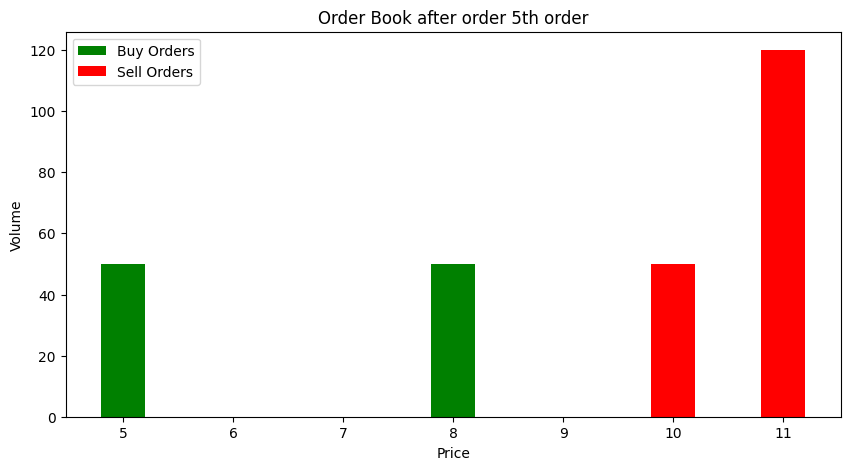

____________________________________________________________________________________
____________________________________________________________________________________

Order Book after 20th order:
   Bid Size  Bid Price  Ask Price  Ask Size
0        90       10.0       11.0       110
1       150        8.0       12.0       100
2       142        7.0       12.5        20
3        50        5.0       15.0        40
4      <NA>        NaN       30.0       150
5      <NA>        NaN      100.0        50

Trade Log:
            timestamp  buy_group  sell_group  price  size
0  9/30/2024 20:26:34         11          12   10.0    40
1  9/30/2024 20:26:39          9          12   10.0    10
2  9/30/2024 20:26:39          9           4   10.0    50
3  9/30/2024 20:26:47          3           4   10.0    10
4  9/30/2024 20:27:20          1          14   11.0    10


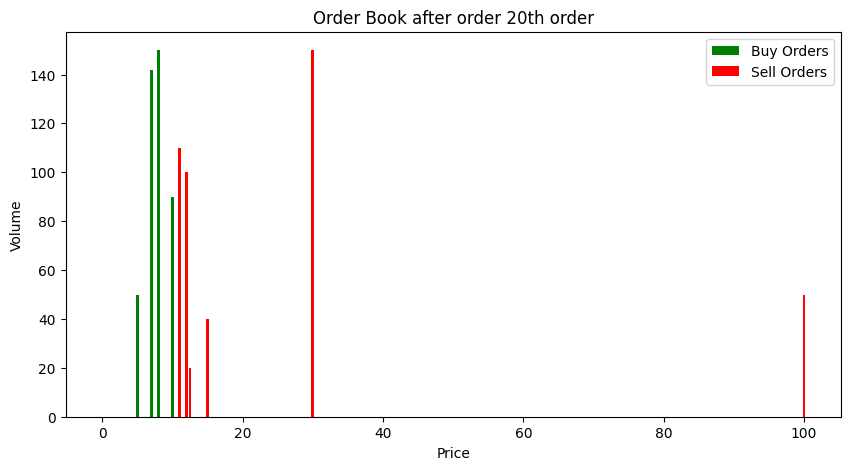

____________________________________________________________________________________
____________________________________________________________________________________

Order Book after 100th order:
    Bid Size  Bid Price  Ask Price  Ask Size
0        140      10.00      10.10        70
1         25       9.99      10.50       200
2          5       9.80      10.60        10
3          5       9.75      10.75        40
4          5       9.70      10.76        20
5          5       9.65      10.77        40
6        505       9.60      10.80        10
7          5       9.55      10.90        10
8         10       9.53      10.99        10
9         30       9.50      11.00       200
10       270       9.10      11.01       100
11        20       9.02      11.50        20
12       347       9.00      11.75        25
13        25       8.88      11.95        15
14        35       8.80      12.00       260
15        20       8.70      12.50        20
16        10       8.60      13.00

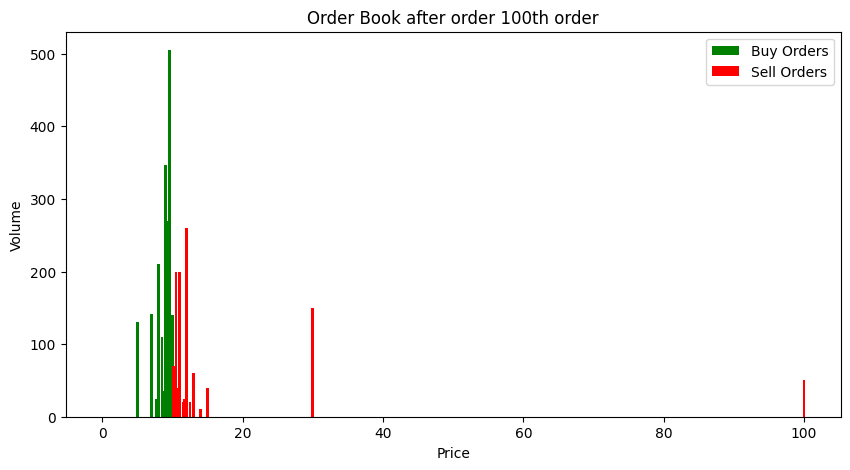

____________________________________________________________________________________


In [8]:
class CLOB:
    def __init__(self):
        self.bids = deque()  # Buy orders: sorted by descending price
        self.asks = deque()  # Sell orders: sorted by ascending price
        self.trade_log = []  # Store trade details
        self.spreads_ticks = []  # Store bid-ask spread details in ticks
        self.spreads_bps = []  # Store bid-ask spread details in bps
        self.depths = []  # Store market depth details
        self.order_book_states = []  # Store order book states for each order

    def add_order(self, timestamp, side, price, size, group_number):
        order = {'timestamp': timestamp, 'price': price, 'size': size, 'group': group_number}

        if side == 'buy':
            self._match_order(self.asks, order, 'buy')
            if order['size'] > 0:
                self._insert_order(self.bids, order, descending=True)

        elif side == 'sell':
            self._match_order(self.bids, order, 'sell')
            if order['size'] > 0:
                self._insert_order(self.asks, order, descending=False)
                
        self.calculate_bid_ask_spread()
        self.calculate_market_depth()
        self.capture_order_book_state(timestamp)

    def _insert_order(self, order_list, order, descending):
        # Insert order while keeping the list sorted
        pos = 0
        while pos < len(order_list):
            if (descending and order['price'] > order_list[pos]['price']) or \
               (not descending and order['price'] < order_list[pos]['price']):
                break
            pos += 1
        order_list.insert(pos, order)

    def _match_order(self, opposite_list, order, order_side):
        while order['size'] > 0 and opposite_list:
            top_order = opposite_list[0]

            # Check if orders can be matched
            if (order_side == 'buy' and order['price'] >= top_order['price']) or \
               (order_side == 'sell' and order['price'] <= top_order['price']):
                
                trade_size = min(order['size'], top_order['size'])
                trade = {
                    'timestamp': order['timestamp'],
                    'buy_group': order['group'] if order_side == 'buy' else top_order['group'],
                    'sell_group': order['group'] if order_side == 'sell' else top_order['group'],
                    'price': top_order['price'],
                    'size': trade_size
                }
                self.trade_log.append(trade)

                # Adjust the remaining sizes
                order['size'] -= trade_size
                top_order['size'] -= trade_size

                if top_order['size'] == 0:
                    opposite_list.popleft()  # Remove filled order
            else:
                break
            
    def calculate_bid_ask_spread(self):
        if self.bids and self.asks:
            best_bid = self.bids[0]['price']
            best_ask = self.asks[0]['price']

            # Calculate spread in ticks and basis points
            tick_size = 0.01
            spread_ticks = round(best_ask - best_bid, 2) / tick_size
            mid_price = (best_bid + best_ask) / 2
            spread_bps = ((best_ask - best_bid) / mid_price) * 10000
            
            self.spreads_ticks.append(spread_ticks)
            self.spreads_bps.append(spread_bps)
        else:
            self.spreads_ticks.append(0)
            self.spreads_bps.append(0)

    def calculate_market_depth(self):
        if self.bids and self.asks:
            best_bid = self.bids[0]
            best_ask = self.asks[0]

            # Calculate the dollar value of the best bid and ask depth
            bid_depth = best_bid['price'] * best_bid['size']
            ask_depth = best_ask['price'] * best_ask['size']
            market_depth = (bid_depth + ask_depth)/2

            self.depths.append(market_depth)
        else:
            self.depths.append(0)
         
    def capture_order_book_state(self, timestamp):
        best_bid = self.bids[0]['price'] if self.bids else None
        best_ask = self.asks[0]['price'] if self.asks else None
        tick_size = 0.01
        bid_ask_spread_ticks = round(best_ask - best_bid, 2) / tick_size if best_bid is not None and best_ask is not None else np.nan
        mid_price = (best_bid + best_ask) / 2 if best_bid is not None and best_ask is not None else None
        bid_ask_spread_bps = ((best_ask - best_bid) / mid_price) * 10000 if mid_price else np.nan
        market_depth = (self.depths[-1]) if self.depths else 0

        self.order_book_states.append([timestamp, best_bid, best_ask, bid_ask_spread_ticks, bid_ask_spread_bps, market_depth])
       
    # Convert the order book state log to a DataFrame
    def order_book_state_to_dataframe(self):
        ob_state_df = pd.DataFrame(self.order_book_states, columns=['Timestamp', 'best_bid', 'best_ask', 'bid_ask_spread_ticks', 'bid_ask_spread_bps', 'market_depth'])
        return ob_state_df
    
    def print_order_book(self, stage):
        print(f"\nOrder Book after {stage}:")
        # Merge volumes of the same prices in bids
        merged_bids = {}
        for order in self.bids:
            if order['price'] in merged_bids:
                merged_bids[order['price']]['size'] += order['size']
            else:
                merged_bids[order['price']] = {'size': order['size'], 'price': order['price']}
        
        # Merge volumes of the same prices in asks
        merged_asks = {}
        for order in self.asks:
            if order['price'] in merged_asks:
                merged_asks[order['price']]['size'] += order['size']
            else:
                merged_asks[order['price']] = {'size': order['size'], 'price': order['price']}
        
        # Create dataframes for merged bids and asks
        bids_data = [{'Size': order['size'], 'Price': order['price']} for order in merged_bids.values()]
        asks_data = [{'Price': order['price'], 'Size': order['size']} for order in merged_asks.values()]
        bids_df = pd.DataFrame(bids_data)
        asks_df = pd.DataFrame(asks_data)

        # Ensure both dataframes have the same number of rows by padding with NaNs
        max_len = max(len(bids_df), len(asks_df))
        bids_df = bids_df.reindex(range(max_len))
        asks_df = asks_df.reindex(range(max_len))
        
        # If bids or asks are empty, fill with NaNs to ensure same number of rows
        if bids_df.empty:
            bids_df = pd.DataFrame(index=range(max_len), columns=['Size', 'Price'])
        if asks_df.empty:
            asks_df = pd.DataFrame(index=range(max_len), columns=['Price', 'Size'])
        
        # Concatenate side by side
        order_book_df = pd.concat([bids_df.reset_index(drop=True), asks_df.reset_index(drop=True)], axis=1)
        order_book_df.columns = ['Bid Size', 'Bid Price', 'Ask Price', 'Ask Size']
        order_book_df[['Bid Size', 'Ask Size']] = order_book_df[['Bid Size', 'Ask Size']].astype('Int64')
        print(order_book_df)

        # Print the trade log
        self.print_trade_log()
        # Plot the bar charts for bids and asks
        self.plot_order_book_bars(bids_df, asks_df, stage)

    def plot_order_book_bars(self, bids_df, asks_df,stage):
        plt.figure(figsize=(10, 5))
        # Replace missing or empty values with 0 before converting to float
        buy_volumes = pd.to_numeric(bids_df['Size'], errors='coerce').fillna(0)
        sell_volumes = pd.to_numeric(asks_df['Size'], errors='coerce').fillna(0)
        buy_prices = pd.to_numeric(bids_df['Price'], errors='coerce').fillna(0)
        sell_prices = pd.to_numeric(asks_df['Price'], errors='coerce').fillna(0)

        # Plot buy orders
        plt.bar(buy_prices, buy_volumes, color='green', label='Buy Orders', width=0.4, align='center')

        # Plot sell orders
        plt.bar(sell_prices, sell_volumes, color='red', label='Sell Orders', width=0.4, align='center')

        plt.title(f"Order Book after order {stage}")
        plt.xlabel('Price')
        plt.ylabel('Volume')
        plt.legend()
        plt.show()
        
    def print_trade_log(self):
        print("\nTrade Log:")
        tradeLog_df = pd.DataFrame(self.trade_log)
        print(tradeLog_df)
        
    def print_spread_and_depth(self):
        print("\nSpread and Market Depth:")
        spread_depth_df = pd.DataFrame({'Spread (ticks)': self.spreads_ticks, 'Spread (bps)': self.spreads_bps, 'Market Depth': self.depths})
        spread_depth_df = spread_depth_df.round(2)
        print(spread_depth_df)
        

# Initialize the Order Book
order_book = CLOB()

# Add orders from the CSV file
for i, row in orders_df.iterrows():
    timestamp = row['Timestamp']
    side = row['Side'].lower()
    price = row['Price']
    size = row['Size']
    group_number = row['Group ID']

    order_book.add_order(timestamp, side, price, size, group_number)
    
    # Print order book and trade log at required stages
    if i + 1 in [5, 20, len(orders_df)]:
        print("____________________________________________________________________________________")
        order_book.print_order_book(f"{i + 1}th order")
        print("____________________________________________________________________________________")

### Final Trade Log

In [9]:
# Print the trade log
order_book.print_trade_log()


Trade Log:
             timestamp  buy_group  sell_group  price  size
0   9/30/2024 20:26:34         11          12  10.00    40
1   9/30/2024 20:26:39          9          12  10.00    10
2   9/30/2024 20:26:39          9           4  10.00    50
3   9/30/2024 20:26:47          3           4  10.00    10
4   9/30/2024 20:27:20          1          14  11.00    10
5   9/30/2024 20:31:47          3          18  10.00    40
6   9/30/2024 20:31:47         13          18  10.00    50
7   9/30/2024 20:32:59          3          16   9.50    50
8   9/30/2024 20:33:46         15          16   9.50    50
9   9/30/2024 20:33:46         15          18  10.00    10
10  9/30/2024 20:33:46         15          20  10.00    40
11  9/30/2024 20:33:48          9           8  10.00    30
12  9/30/2024 20:33:48          9          14  11.00    10
13  9/30/2024 20:33:48          9          10  11.00    60
14  9/30/2024 20:40:07          1          16  10.00    70
15  9/30/2024 20:40:07          1           

### Bid-Ask spread in ticks and bps alog with Market depth at each order book state

In [10]:
# Print the spread and market depth after each order
order_book.print_spread_and_depth()


Spread and Market Depth:
    Spread (ticks)  Spread (bps)  Market Depth
0              0.0          0.00           0.0
1            300.0       3157.89         310.0
2            300.0       3157.89         310.0
3            200.0       2222.22         450.0
4            200.0       2222.22         450.0
..             ...           ...           ...
95            10.0         99.50        1053.5
96            10.0         99.50        1053.5
97            10.0         99.50        1053.5
98            10.0         99.50        1053.5
99            10.0         99.50        1053.5

[100 rows x 3 columns]


### Calculating Weighted Bid-Ask Spread

In [11]:
ob_state_df=order_book.order_book_state_to_dataframe()
ob_state_df

,Timestamp,best_bid,best_ask,bid_ask_spread_ticks,bid_ask_spread_bps,market_depth
0,9/30/2024 20:26:01,8.0,NaN,NaN,NaN,0.0
1,9/30/2024 20:26:11,8.0,11.0,300.0,3157.894737,310.0
2,9/30/2024 20:26:14,8.0,11.0,300.0,3157.894737,310.0
3,9/30/2024 20:26:15,8.0,10.0,200.0,2222.222222,450.0
4,9/30/2024 20:26:16,8.0,10.0,200.0,2222.222222,450.0
...,...,...,...,...,...,...
95,9/30/2024 20:42:24,10.0,10.1,10.0,99.502488,1053.5
96,9/30/2024 20:42:24,10.0,10.1,10.0,99.502488,1053.5
97,9/30/2024 20:42:41,10.0,10.1,10.0,99.502488,1053.5
98,9/30/2024 20:43:00,10.0,10.1,10.0,99.502488,1053.5


In [12]:
ob_state_df['Timestamp'] = pd.to_datetime(ob_state_df['Timestamp'])

In [13]:
ob_state_df.mean()

Timestamp               2024-09-30 20:36:43.260000768
best_bid                                       9.4261
best_ask                                    10.138384
bid_ask_spread_ticks                        69.787879
bid_ask_spread_bps                         732.594171
market_depth                                594.95125
dtype: object

In [14]:
# Calculate the weighted bid-ask spread using time difference between orders
def calculate_weighted_spread(results):
    weighted_spreads = []
    previous_timestamp = None

    for i in range(len(results)-1):  # Iterate through each state except the last
        current_state = results.iloc[i]
        next_state = results.iloc[i+1]
        
        # Calculate time difference between current and next timestamp
        time_diff = pd.to_datetime(next_state['Timestamp']) - pd.to_datetime(current_state['Timestamp'])
        time_diff_seconds = time_diff.total_seconds()
        
        # Calculate weighted bid-ask spread
        if current_state['bid_ask_spread_ticks'] is not None:
            weighted_spread = current_state['bid_ask_spread_ticks'] * time_diff_seconds
        else:
            weighted_spread = None
        
        # Append the result
        weighted_spreads.append({
            'Timestamp': current_state['Timestamp'],
            'Bid-Ask Spread (ticks)': current_state['bid_ask_spread_ticks'],
            'Time Diff (s)': time_diff_seconds,
            'Weighted Spread (ticks)': weighted_spread,
            'Bid-Ask Spread (bps)': round(current_state['bid_ask_spread_bps'],2),
            'Market Depth': current_state['market_depth']
        })
    
    # Convert results to DataFrame and print
    weighted_spread_df = pd.DataFrame(weighted_spreads)
    #print(weighted_spread_df)
    return weighted_spread_df

In [15]:
print("\nBid-Ask Spread and Market Depth by Order Book State:")
weighted_spread_df=calculate_weighted_spread(ob_state_df)
weighted_spread_df


Bid-Ask Spread and Market Depth by Order Book State:


,Timestamp,Bid-Ask Spread (ticks),Time Diff (s),Weighted Spread (ticks),Bid-Ask Spread (bps),Market Depth
0,2024-09-30 20:26:01,NaN,10.0,NaN,NaN,0.0
1,2024-09-30 20:26:11,300.0,3.0,900.0,3157.89,310.0
2,2024-09-30 20:26:14,300.0,1.0,300.0,3157.89,310.0
3,2024-09-30 20:26:15,200.0,1.0,200.0,2222.22,450.0
4,2024-09-30 20:26:16,200.0,4.0,800.0,2222.22,450.0
...,...,...,...,...,...,...
94,2024-09-30 20:42:18,10.0,6.0,60.0,99.50,1128.5
95,2024-09-30 20:42:24,10.0,0.0,0.0,99.50,1053.5
96,2024-09-30 20:42:24,10.0,17.0,170.0,99.50,1053.5
97,2024-09-30 20:42:41,10.0,19.0,190.0,99.50,1053.5


In [16]:
weighted_spread_df.mean()

Timestamp                  2024-09-30 20:36:39.313131776
Bid-Ask Spread (ticks)                         70.397959
Time Diff (s)                                  10.434343
Weighted Spread (ticks)                      1251.030612
Bid-Ask Spread (bps)                          739.054388
Market Depth                                  590.319444
dtype: object

### Result:
1. Bid-Ask Spread (Ticks and Bps):
* Mean Bid-Ask Spread (ticks): 69.79 ticks (first table) and 70.40 ticks (second table).
* Mean Bid-Ask Spread (bps): 732.59 bps.
* **Interpretation:** The bid-ask spread in ticks shows the price difference between the best bid and ask expressed in ticks, with a value of approximately 69.79 to 70.40 ticks. This suggests that liquidity conditions are fairly consistent across states. The bid-ask spread in bps (basis points) offers a percentage-based view of the spread. The values of approximately 732-739 bps indicate the relative cost of trading across states. 

2. Time Difference Between Order Book States:
* Mean Time Difference: 10.43 seconds
* **Interpretation:** On average, there’s a 10.43-second gap between changes in the order book. This reflects a dynamic market where order book states are frequently updated, possibly due to high-frequency trading or periods of market activity.

4. Weighted Spread (Ticks):
* Mean Weighted Spread (ticks): 1251.03 ticks
* **Interpretation:** The weighted spread is significantly larger than the simple bid-ask spread (69.79 to 70.40 ticks). This implies that larger orders are placed farther from the best bid and ask prices, leading to a higher weighted spread. It suggests that while small trades can occur at narrow spreads, large trades will encounter higher costs due to liquidity being concentrated away from the top of the order book.

5. Market Depth:
* Market Depth (first table): 594.95
* Market Depth (second table): 590.32
* **Interpretation:** Market depth represents the total quantity of buy and sell orders near the best bid and ask. Values close to 590-595 suggest that liquidity remains relatively stable across states, with a slight dip when time is considered in the second table. The relatively stable market depth indicates that liquidity is generally accessible, though the high weighted spread suggests that large orders may still face challenges in terms of slippage.


### Analysis:

1. Stable Liquidity: The market depth remains stable between the two tables (around 590-595), and the bid-ask spreads are fairly consistent, showing no significant fluctuations in liquidity. The market depth and bid-ask spread suggest that liquidity is concentrated at the top levels of the order book, but deeper liquidity lies further away, as indicated by the weighted spread.

2. Order Book Dynamics: The high weighted spread of 1251 ticks compared to the bid-ask spread of 70 ticks shows that while smaller trades may occur at lower costs, larger trades will face significantly higher costs. The time difference of 10.43 seconds per state suggests a fast-moving market, possibly driven by algorithmic or high-frequency traders who update the order book frequently.

3. Trading Costs: The bid-ask spread values (both ticks and bps) indicate the cost of executing trades. With an average spread of around 70 ticks or 732-739 bps, trades are relatively expensive, especially for larger orders that face the wider weighted spread. Traders looking to execute large trades must be prepared for higher costs, as liquidity is available but at worse prices further away from the best bid and ask.

### Conclusion:
The analysis of these 99 order book states reveals a market with stable liquidity at the top levels, though deeper liquidity comes with higher trading costs as reflected in the weighted spread. The fast-moving order book with a 10-second refresh rate suggests an active trading environment, likely dominated by high-frequency trading. Traders should be mindful of the high cost of executing large orders due to the wide weighted spread.

### All 100 Order Book States

____________________________________________________________________________________

Order Book after 1th order:
   Bid Size  Bid Price Ask Price  Ask Size
0        50        8.0       NaN      <NA>

Trade Log:
Empty DataFrame
Columns: []
Index: []


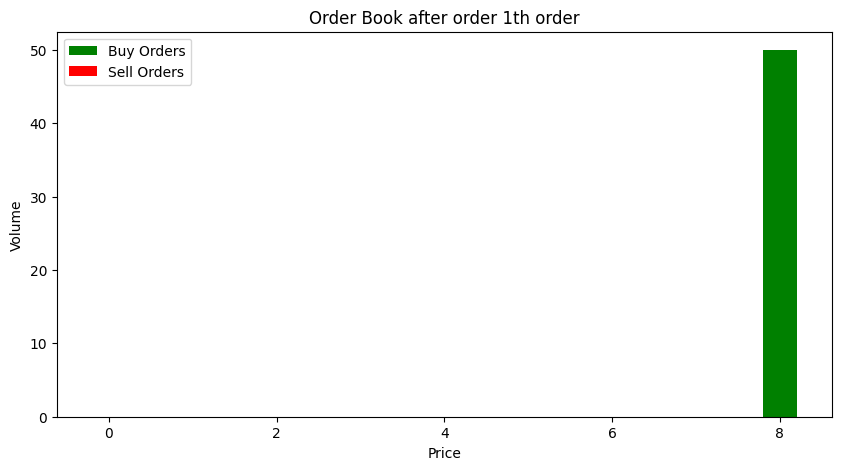

____________________________________________________________________________________
____________________________________________________________________________________

Order Book after 2th order:
   Bid Size  Bid Price  Ask Price  Ask Size
0        50        8.0       11.0        20

Trade Log:
Empty DataFrame
Columns: []
Index: []


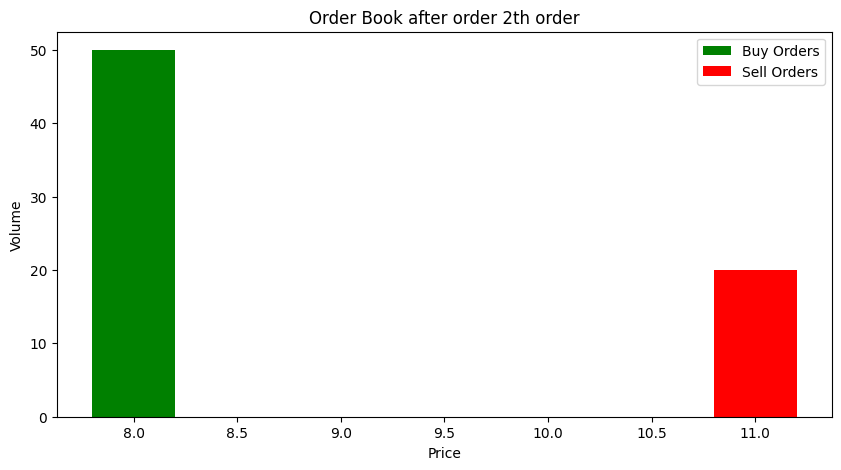

____________________________________________________________________________________
____________________________________________________________________________________

Order Book after 3th order:
   Bid Size  Bid Price  Ask Price  Ask Size
0        50        8.0       11.0       120

Trade Log:
Empty DataFrame
Columns: []
Index: []


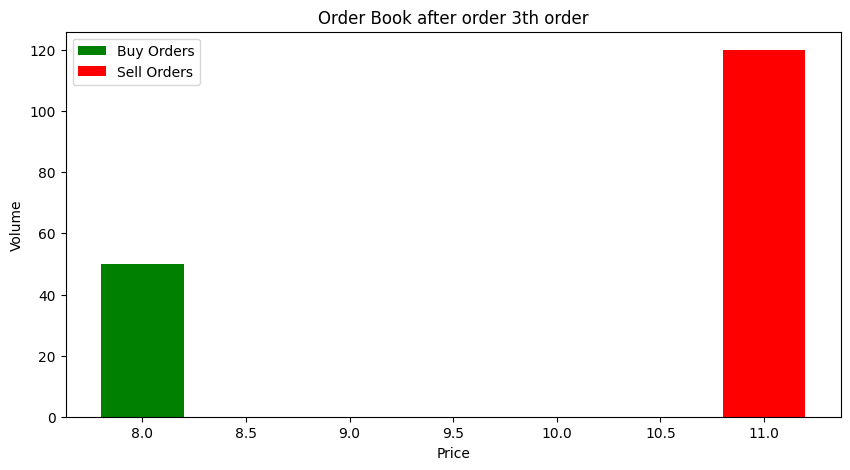

____________________________________________________________________________________
____________________________________________________________________________________

Order Book after 4th order:
   Bid Size  Bid Price  Ask Price  Ask Size
0        50        8.0       10.0        50
1      <NA>        NaN       11.0       120

Trade Log:
Empty DataFrame
Columns: []
Index: []


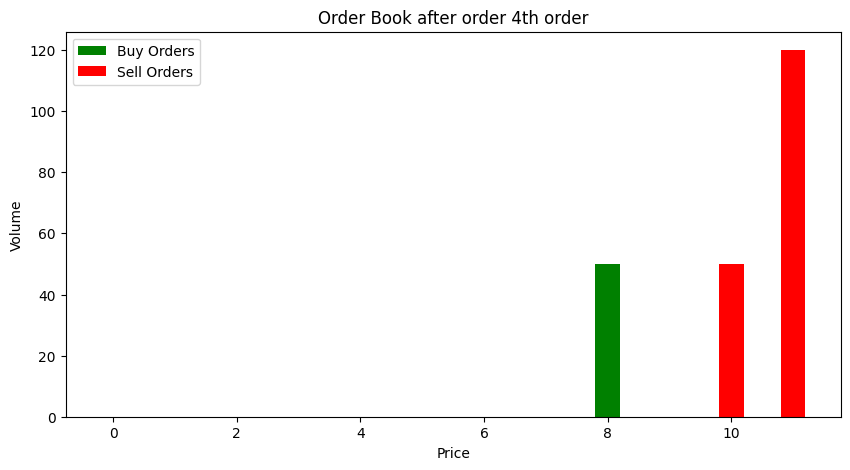

____________________________________________________________________________________
____________________________________________________________________________________

Order Book after 5th order:
   Bid Size  Bid Price  Ask Price  Ask Size
0        50        8.0       10.0        50
1        50        5.0       11.0       120

Trade Log:
Empty DataFrame
Columns: []
Index: []


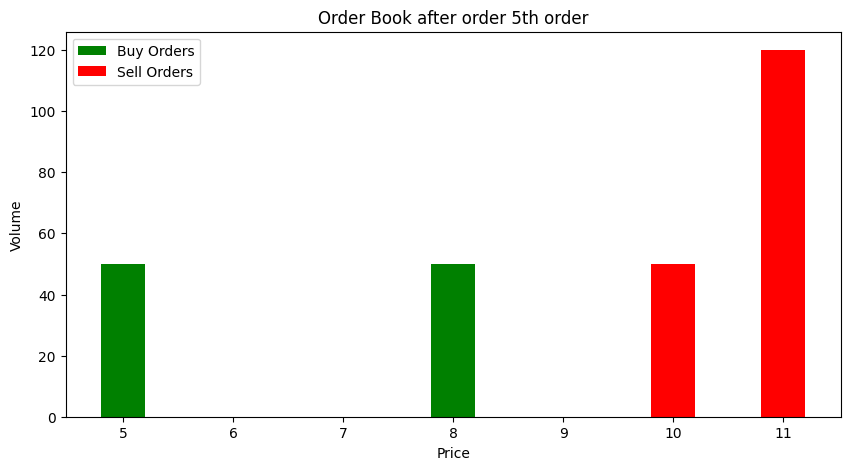

____________________________________________________________________________________
____________________________________________________________________________________

Order Book after 6th order:
   Bid Size  Bid Price  Ask Price  Ask Size
0        50        8.0       10.0        50
1        50        5.0       11.0       120
2      <NA>        NaN       12.5        20

Trade Log:
Empty DataFrame
Columns: []
Index: []


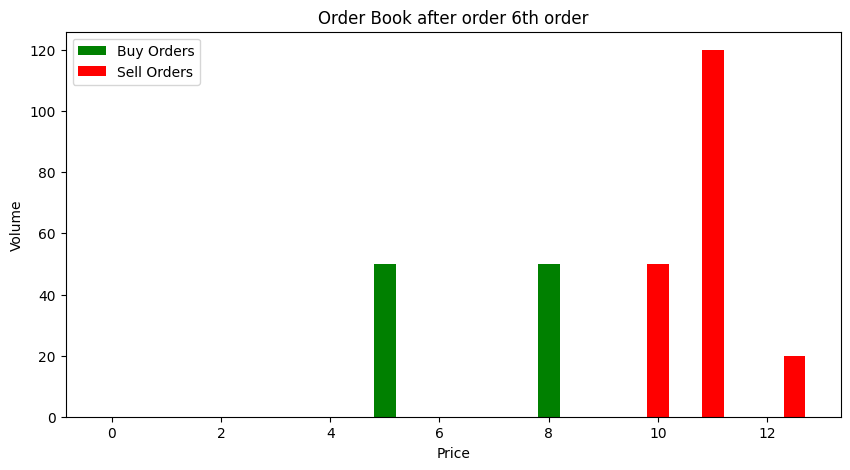

____________________________________________________________________________________
____________________________________________________________________________________

Order Book after 7th order:
   Bid Size  Bid Price  Ask Price  Ask Size
0        50        8.0       10.0        50
1        50        5.0       11.0       120
2      <NA>        NaN       12.5        20
3      <NA>        NaN       15.0        40

Trade Log:
Empty DataFrame
Columns: []
Index: []


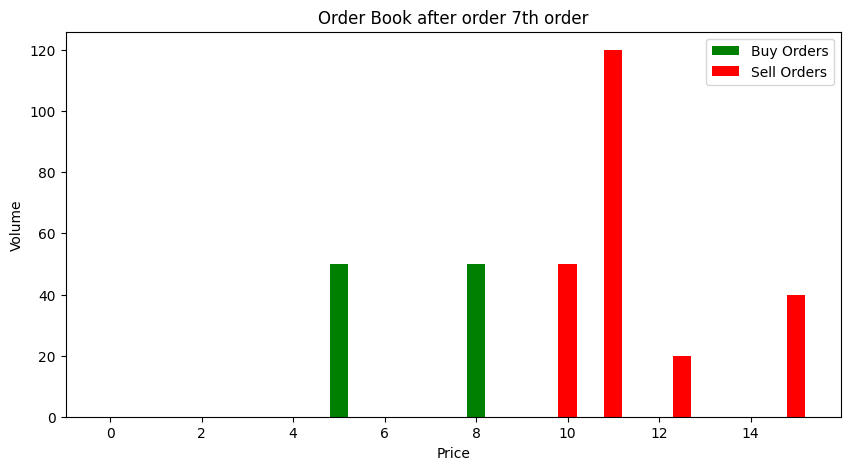

____________________________________________________________________________________
____________________________________________________________________________________

Order Book after 8th order:
   Bid Size  Bid Price  Ask Price  Ask Size
0        50        8.0       10.0        50
1       142        7.0       11.0       120
2        50        5.0       12.5        20
3      <NA>        NaN       15.0        40

Trade Log:
Empty DataFrame
Columns: []
Index: []


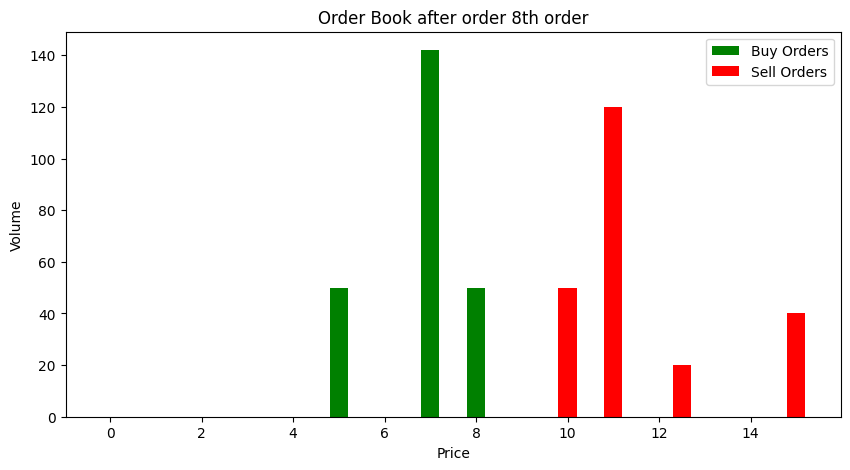

____________________________________________________________________________________
____________________________________________________________________________________

Order Book after 9th order:
   Bid Size  Bid Price  Ask Price  Ask Size
0       100        8.0       10.0        50
1       142        7.0       11.0       120
2        50        5.0       12.5        20
3      <NA>        NaN       15.0        40

Trade Log:
Empty DataFrame
Columns: []
Index: []


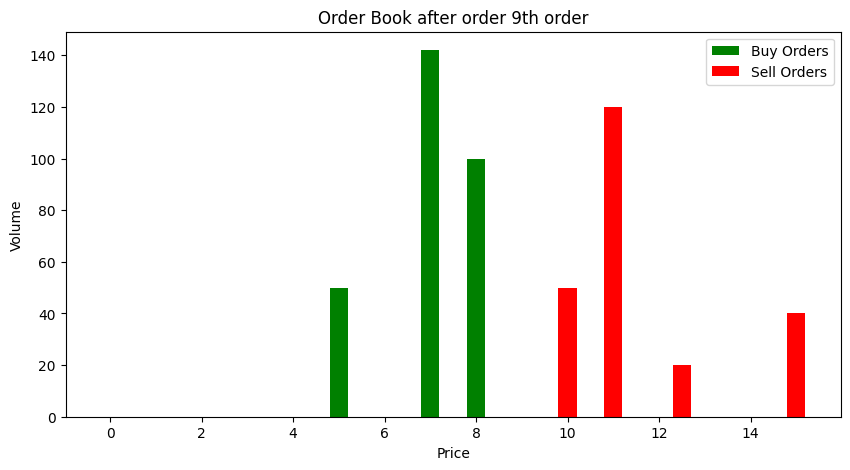

____________________________________________________________________________________
____________________________________________________________________________________

Order Book after 10th order:
   Bid Size  Bid Price  Ask Price  Ask Size
0       100        8.0       10.0        50
1       142        7.0       11.0       120
2        50        5.0       12.5        20
3      <NA>        NaN       15.0        40
4      <NA>        NaN       30.0       100

Trade Log:
Empty DataFrame
Columns: []
Index: []


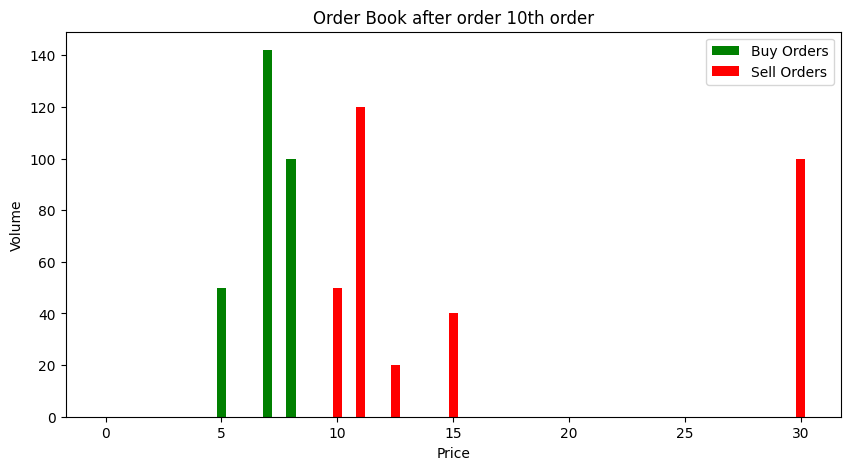

____________________________________________________________________________________
____________________________________________________________________________________

Order Book after 11th order:
   Bid Size  Bid Price  Ask Price  Ask Size
0       100        8.0       10.0        50
1       142        7.0       11.0       120
2        50        5.0       12.5        20
3      <NA>        NaN       15.0        40
4      <NA>        NaN       30.0       100
5      <NA>        NaN      100.0        50

Trade Log:
Empty DataFrame
Columns: []
Index: []


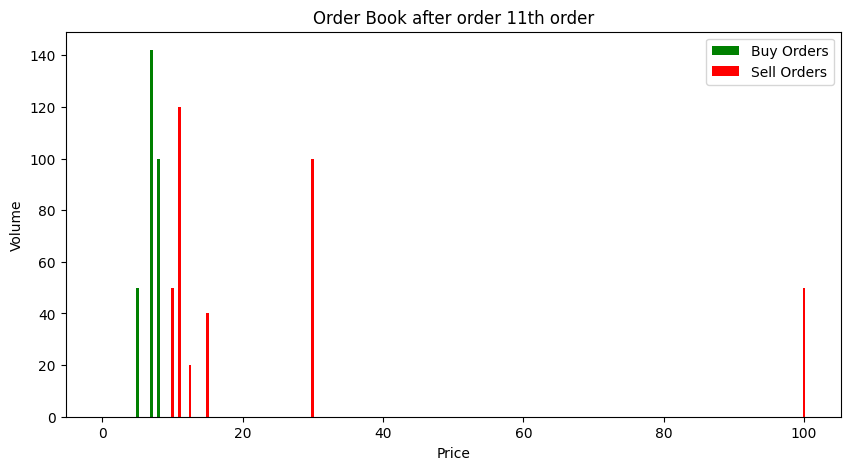

____________________________________________________________________________________
____________________________________________________________________________________

Order Book after 12th order:
   Bid Size  Bid Price  Ask Price  Ask Size
0       100        8.0       10.0       110
1       142        7.0       11.0       120
2        50        5.0       12.5        20
3      <NA>        NaN       15.0        40
4      <NA>        NaN       30.0       100
5      <NA>        NaN      100.0        50

Trade Log:
Empty DataFrame
Columns: []
Index: []


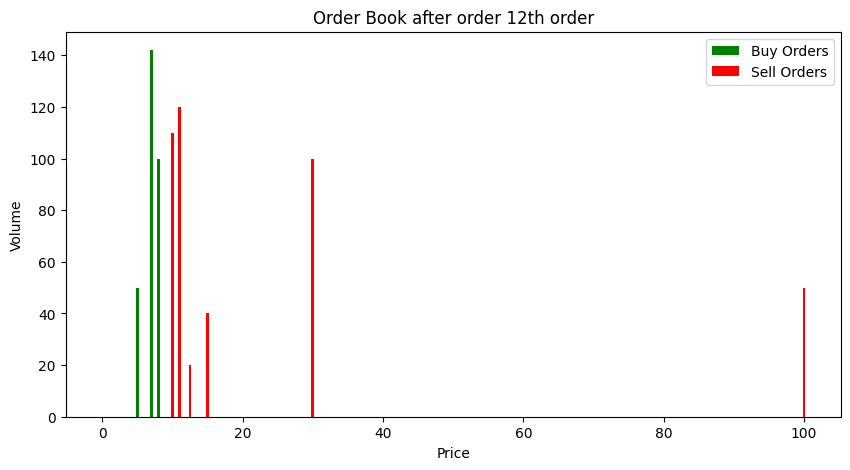

____________________________________________________________________________________
____________________________________________________________________________________

Order Book after 13th order:
   Bid Size  Bid Price  Ask Price  Ask Size
0       100        8.0       10.0        70
1       142        7.0       11.0       120
2        50        5.0       12.5        20
3      <NA>        NaN       15.0        40
4      <NA>        NaN       30.0       100
5      <NA>        NaN      100.0        50

Trade Log:
            timestamp  buy_group  sell_group  price  size
0  9/30/2024 20:26:34         11          12   10.0    40


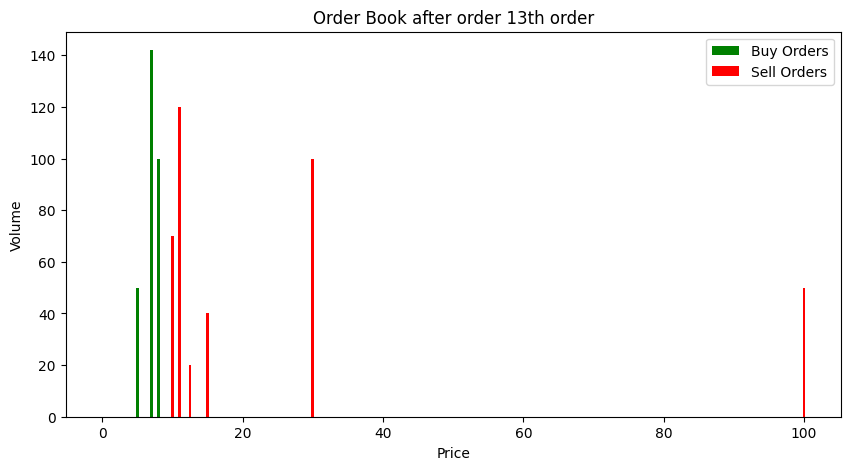

____________________________________________________________________________________
____________________________________________________________________________________

Order Book after 14th order:
   Bid Size  Bid Price  Ask Price  Ask Size
0       100        8.0       10.0        10
1       142        7.0       11.0       120
2        50        5.0       12.5        20
3      <NA>        NaN       15.0        40
4      <NA>        NaN       30.0       100
5      <NA>        NaN      100.0        50

Trade Log:
            timestamp  buy_group  sell_group  price  size
0  9/30/2024 20:26:34         11          12   10.0    40
1  9/30/2024 20:26:39          9          12   10.0    10
2  9/30/2024 20:26:39          9           4   10.0    50


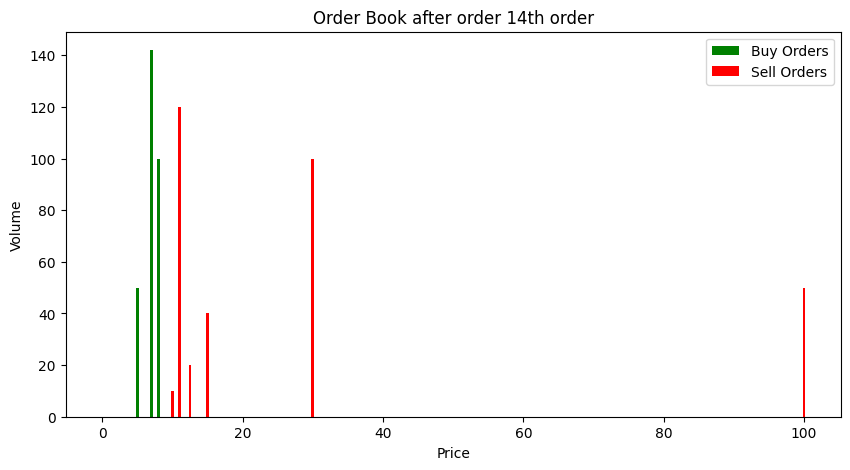

____________________________________________________________________________________
____________________________________________________________________________________

Order Book after 15th order:
   Bid Size  Bid Price  Ask Price  Ask Size
0        40       10.0       11.0       120
1       100        8.0       12.5        20
2       142        7.0       15.0        40
3        50        5.0       30.0       100
4      <NA>        NaN      100.0        50

Trade Log:
            timestamp  buy_group  sell_group  price  size
0  9/30/2024 20:26:34         11          12   10.0    40
1  9/30/2024 20:26:39          9          12   10.0    10
2  9/30/2024 20:26:39          9           4   10.0    50
3  9/30/2024 20:26:47          3           4   10.0    10


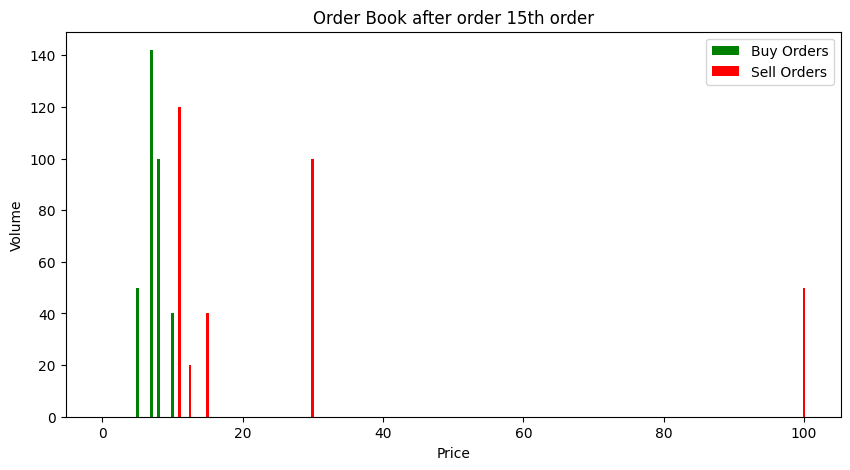

____________________________________________________________________________________
____________________________________________________________________________________

Order Book after 16th order:
   Bid Size  Bid Price  Ask Price  Ask Size
0        90       10.0       11.0       120
1       100        8.0       12.5        20
2       142        7.0       15.0        40
3        50        5.0       30.0       100
4      <NA>        NaN      100.0        50

Trade Log:
            timestamp  buy_group  sell_group  price  size
0  9/30/2024 20:26:34         11          12   10.0    40
1  9/30/2024 20:26:39          9          12   10.0    10
2  9/30/2024 20:26:39          9           4   10.0    50
3  9/30/2024 20:26:47          3           4   10.0    10


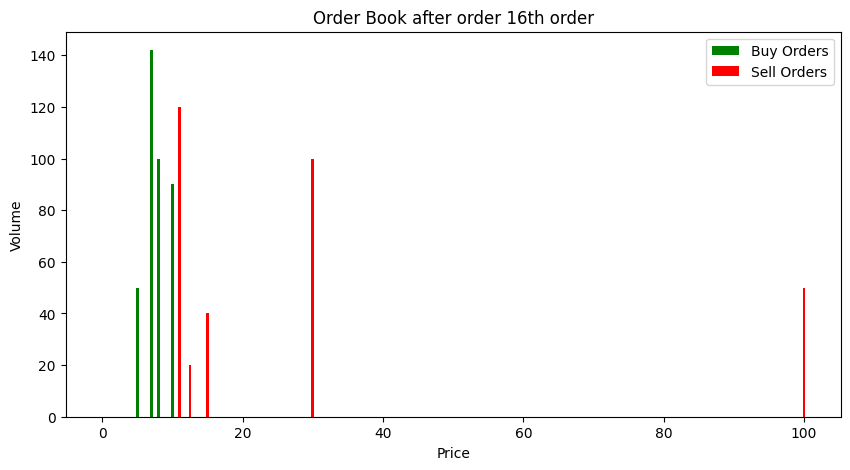

____________________________________________________________________________________
____________________________________________________________________________________

Order Book after 17th order:
   Bid Size  Bid Price  Ask Price  Ask Size
0        90       10.0       11.0       120
1       100        8.0       12.0       100
2       142        7.0       12.5        20
3        50        5.0       15.0        40
4      <NA>        NaN       30.0       100
5      <NA>        NaN      100.0        50

Trade Log:
            timestamp  buy_group  sell_group  price  size
0  9/30/2024 20:26:34         11          12   10.0    40
1  9/30/2024 20:26:39          9          12   10.0    10
2  9/30/2024 20:26:39          9           4   10.0    50
3  9/30/2024 20:26:47          3           4   10.0    10


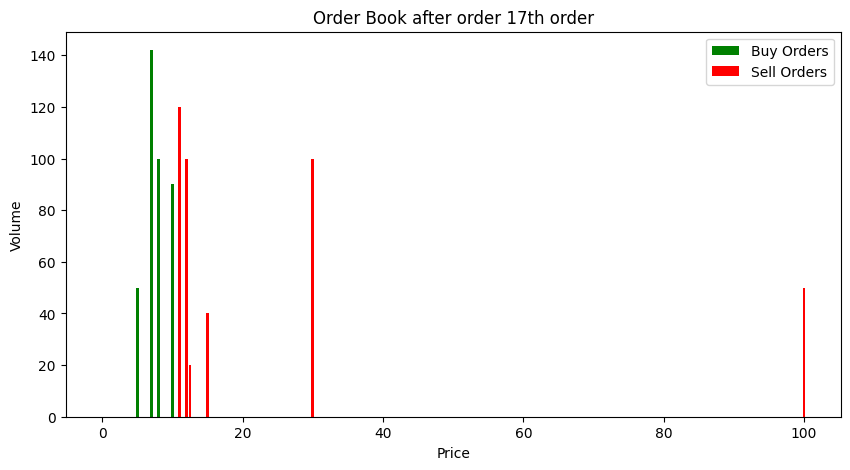

____________________________________________________________________________________
____________________________________________________________________________________

Order Book after 18th order:
   Bid Size  Bid Price  Ask Price  Ask Size
0        90       10.0       11.0       120
1       100        8.0       12.0       100
2       142        7.0       12.5        20
3        50        5.0       15.0        40
4      <NA>        NaN       30.0       150
5      <NA>        NaN      100.0        50

Trade Log:
            timestamp  buy_group  sell_group  price  size
0  9/30/2024 20:26:34         11          12   10.0    40
1  9/30/2024 20:26:39          9          12   10.0    10
2  9/30/2024 20:26:39          9           4   10.0    50
3  9/30/2024 20:26:47          3           4   10.0    10


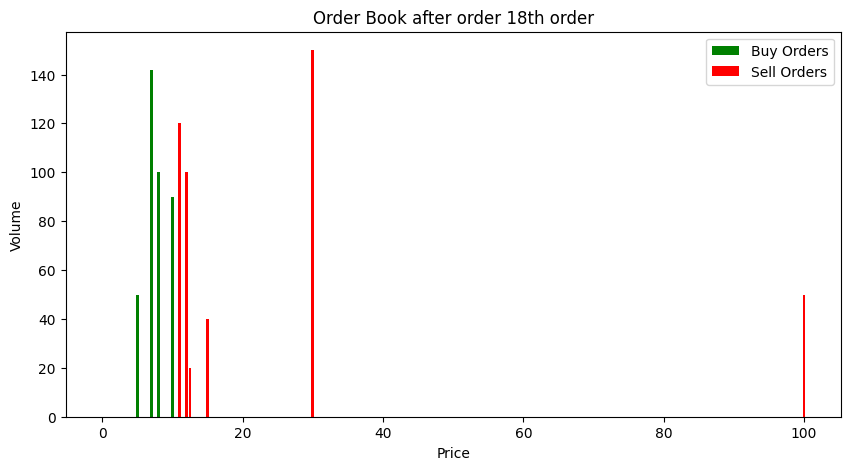

____________________________________________________________________________________
____________________________________________________________________________________

Order Book after 19th order:
   Bid Size  Bid Price  Ask Price  Ask Size
0        90       10.0       11.0       110
1       100        8.0       12.0       100
2       142        7.0       12.5        20
3        50        5.0       15.0        40
4      <NA>        NaN       30.0       150
5      <NA>        NaN      100.0        50

Trade Log:
            timestamp  buy_group  sell_group  price  size
0  9/30/2024 20:26:34         11          12   10.0    40
1  9/30/2024 20:26:39          9          12   10.0    10
2  9/30/2024 20:26:39          9           4   10.0    50
3  9/30/2024 20:26:47          3           4   10.0    10
4  9/30/2024 20:27:20          1          14   11.0    10


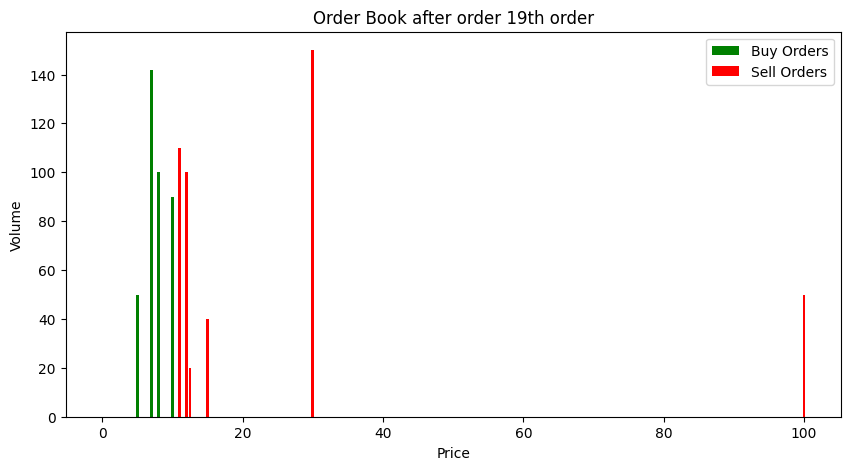

____________________________________________________________________________________
____________________________________________________________________________________

Order Book after 20th order:
   Bid Size  Bid Price  Ask Price  Ask Size
0        90       10.0       11.0       110
1       150        8.0       12.0       100
2       142        7.0       12.5        20
3        50        5.0       15.0        40
4      <NA>        NaN       30.0       150
5      <NA>        NaN      100.0        50

Trade Log:
            timestamp  buy_group  sell_group  price  size
0  9/30/2024 20:26:34         11          12   10.0    40
1  9/30/2024 20:26:39          9          12   10.0    10
2  9/30/2024 20:26:39          9           4   10.0    50
3  9/30/2024 20:26:47          3           4   10.0    10
4  9/30/2024 20:27:20          1          14   11.0    10


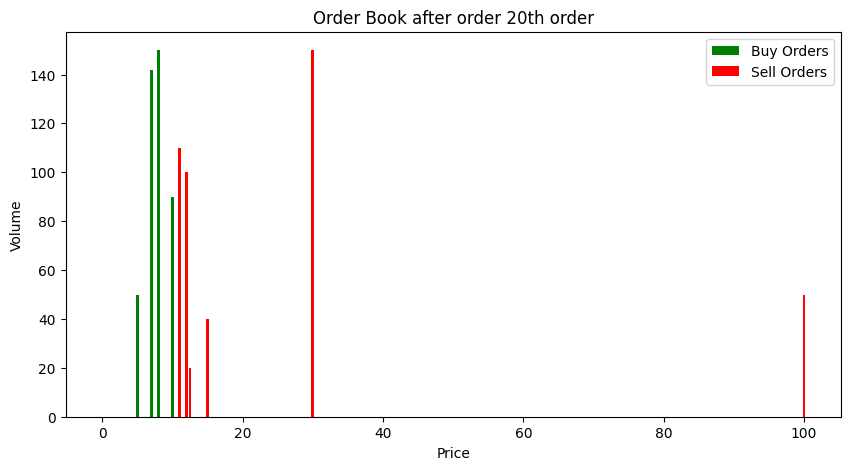

____________________________________________________________________________________
____________________________________________________________________________________

Order Book after 21th order:
   Bid Size  Bid Price  Ask Price  Ask Size
0        90       10.0       11.0       110
1       100        9.0       12.0       100
2       150        8.0       12.5        20
3       142        7.0       15.0        40
4        50        5.0       30.0       150
5      <NA>        NaN      100.0        50

Trade Log:
            timestamp  buy_group  sell_group  price  size
0  9/30/2024 20:26:34         11          12   10.0    40
1  9/30/2024 20:26:39          9          12   10.0    10
2  9/30/2024 20:26:39          9           4   10.0    50
3  9/30/2024 20:26:47          3           4   10.0    10
4  9/30/2024 20:27:20          1          14   11.0    10


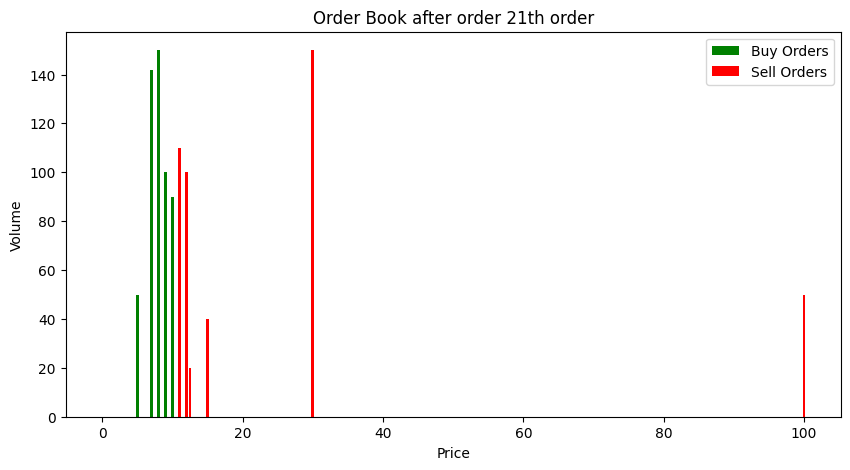

____________________________________________________________________________________
____________________________________________________________________________________

Order Book after 22th order:
   Bid Size  Bid Price  Ask Price  Ask Size
0        90       10.0       11.0       110
1       200        9.0       12.0       100
2       150        8.0       12.5        20
3       142        7.0       15.0        40
4        50        5.0       30.0       150
5      <NA>        NaN      100.0        50

Trade Log:
            timestamp  buy_group  sell_group  price  size
0  9/30/2024 20:26:34         11          12   10.0    40
1  9/30/2024 20:26:39          9          12   10.0    10
2  9/30/2024 20:26:39          9           4   10.0    50
3  9/30/2024 20:26:47          3           4   10.0    10
4  9/30/2024 20:27:20          1          14   11.0    10


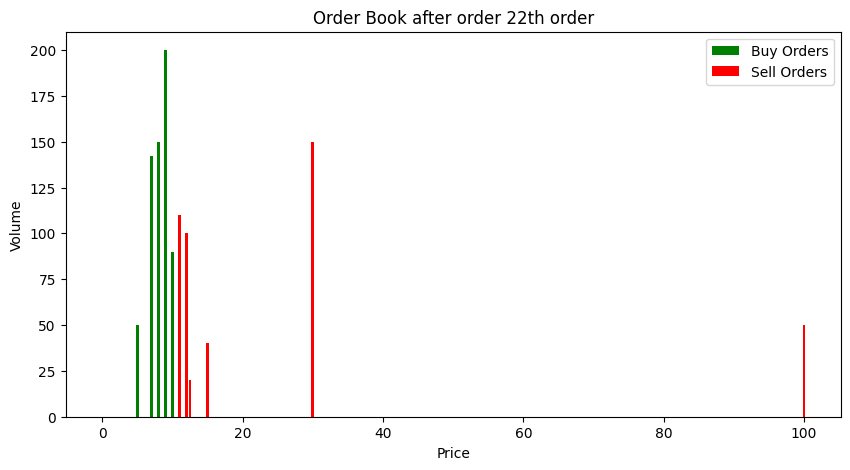

____________________________________________________________________________________
____________________________________________________________________________________

Order Book after 23th order:
   Bid Size  Bid Price  Ask Price  Ask Size
0        90       10.0       11.0       110
1       200        9.0       12.0       200
2       150        8.0       12.5        20
3       142        7.0       15.0        40
4        50        5.0       30.0       150
5      <NA>        NaN      100.0        50

Trade Log:
            timestamp  buy_group  sell_group  price  size
0  9/30/2024 20:26:34         11          12   10.0    40
1  9/30/2024 20:26:39          9          12   10.0    10
2  9/30/2024 20:26:39          9           4   10.0    50
3  9/30/2024 20:26:47          3           4   10.0    10
4  9/30/2024 20:27:20          1          14   11.0    10


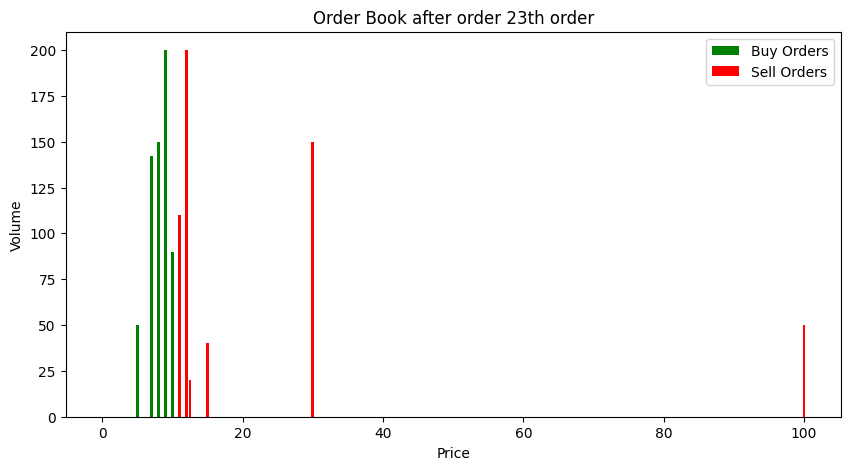

____________________________________________________________________________________
____________________________________________________________________________________

Order Book after 24th order:
   Bid Size  Bid Price  Ask Price  Ask Size
0        90       10.0       11.0       160
1       200        9.0       12.0       200
2       150        8.0       12.5        20
3       142        7.0       15.0        40
4        50        5.0       30.0       150
5      <NA>        NaN      100.0        50

Trade Log:
            timestamp  buy_group  sell_group  price  size
0  9/30/2024 20:26:34         11          12   10.0    40
1  9/30/2024 20:26:39          9          12   10.0    10
2  9/30/2024 20:26:39          9           4   10.0    50
3  9/30/2024 20:26:47          3           4   10.0    10
4  9/30/2024 20:27:20          1          14   11.0    10


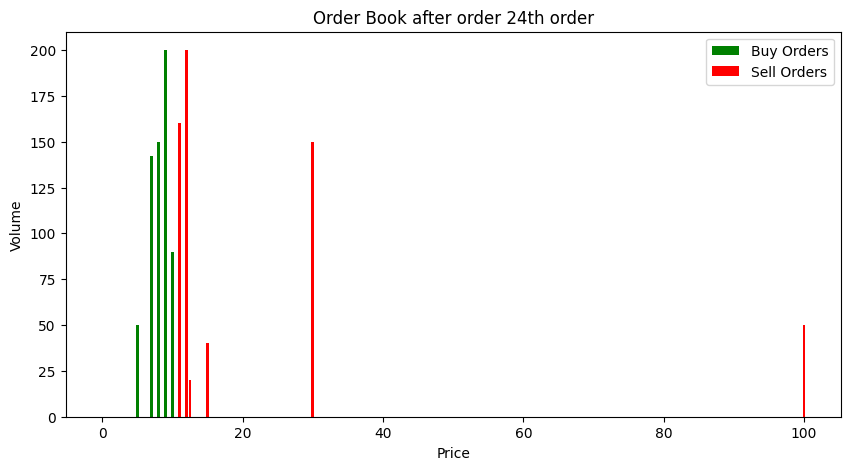

____________________________________________________________________________________
____________________________________________________________________________________

Order Book after 25th order:
   Bid Size  Bid Price  Ask Price  Ask Size
0       200        9.0       10.0        10
1       150        8.0       11.0       160
2       142        7.0       12.0       200
3        50        5.0       12.5        20
4      <NA>        NaN       15.0        40
5      <NA>        NaN       30.0       150
6      <NA>        NaN      100.0        50

Trade Log:
            timestamp  buy_group  sell_group  price  size
0  9/30/2024 20:26:34         11          12   10.0    40
1  9/30/2024 20:26:39          9          12   10.0    10
2  9/30/2024 20:26:39          9           4   10.0    50
3  9/30/2024 20:26:47          3           4   10.0    10
4  9/30/2024 20:27:20          1          14   11.0    10
5  9/30/2024 20:31:47          3          18   10.0    40
6  9/30/2024 20:31:47         

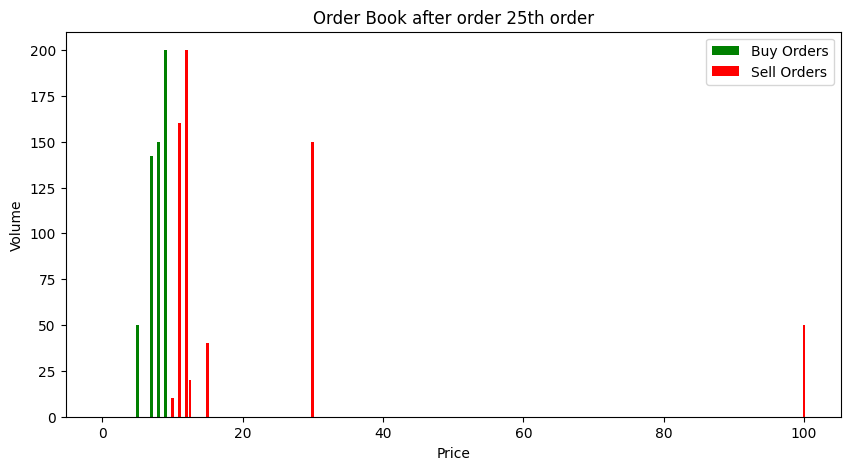

____________________________________________________________________________________
____________________________________________________________________________________

Order Book after 26th order:
   Bid Size  Bid Price  Ask Price  Ask Size
0       200        9.0       10.0        10
1       150        8.0       11.0       160
2       142        7.0       12.0       220
3        50        5.0       12.5        20
4      <NA>        NaN       15.0        40
5      <NA>        NaN       30.0       150
6      <NA>        NaN      100.0        50

Trade Log:
            timestamp  buy_group  sell_group  price  size
0  9/30/2024 20:26:34         11          12   10.0    40
1  9/30/2024 20:26:39          9          12   10.0    10
2  9/30/2024 20:26:39          9           4   10.0    50
3  9/30/2024 20:26:47          3           4   10.0    10
4  9/30/2024 20:27:20          1          14   11.0    10
5  9/30/2024 20:31:47          3          18   10.0    40
6  9/30/2024 20:31:47         

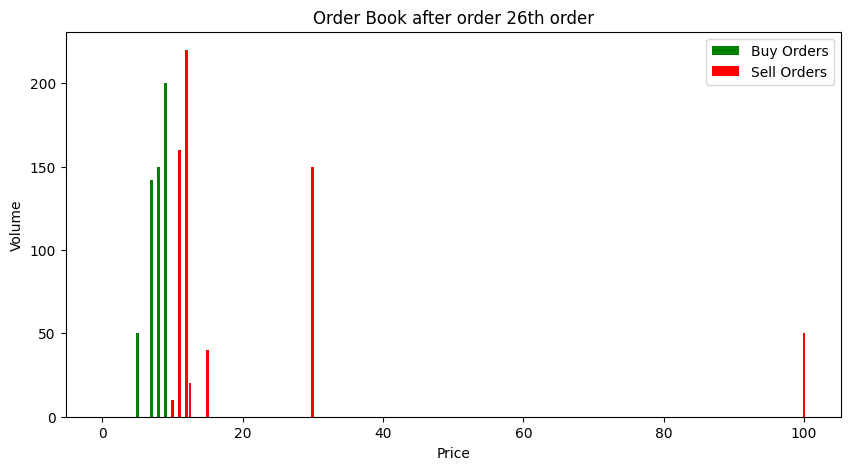

____________________________________________________________________________________
____________________________________________________________________________________

Order Book after 27th order:
   Bid Size  Bid Price  Ask Price  Ask Size
0       200        9.0       10.0        10
1       200        8.0       11.0       160
2       142        7.0       12.0       220
3        50        5.0       12.5        20
4      <NA>        NaN       15.0        40
5      <NA>        NaN       30.0       150
6      <NA>        NaN      100.0        50

Trade Log:
            timestamp  buy_group  sell_group  price  size
0  9/30/2024 20:26:34         11          12   10.0    40
1  9/30/2024 20:26:39          9          12   10.0    10
2  9/30/2024 20:26:39          9           4   10.0    50
3  9/30/2024 20:26:47          3           4   10.0    10
4  9/30/2024 20:27:20          1          14   11.0    10
5  9/30/2024 20:31:47          3          18   10.0    40
6  9/30/2024 20:31:47         

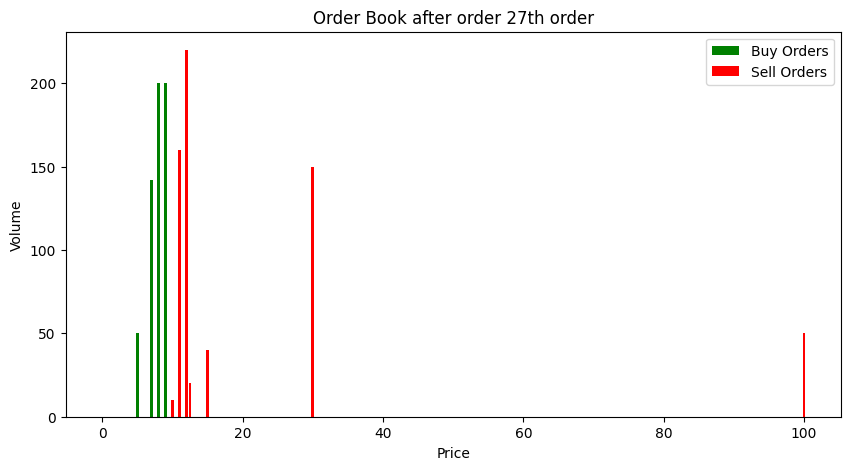

____________________________________________________________________________________
____________________________________________________________________________________

Order Book after 28th order:
   Bid Size  Bid Price  Ask Price  Ask Size
0       200        9.0        9.5       100
1       200        8.0       10.0        10
2       142        7.0       11.0       160
3        50        5.0       12.0       220
4      <NA>        NaN       12.5        20
5      <NA>        NaN       15.0        40
6      <NA>        NaN       30.0       150
7      <NA>        NaN      100.0        50

Trade Log:
            timestamp  buy_group  sell_group  price  size
0  9/30/2024 20:26:34         11          12   10.0    40
1  9/30/2024 20:26:39          9          12   10.0    10
2  9/30/2024 20:26:39          9           4   10.0    50
3  9/30/2024 20:26:47          3           4   10.0    10
4  9/30/2024 20:27:20          1          14   11.0    10
5  9/30/2024 20:31:47          3          18

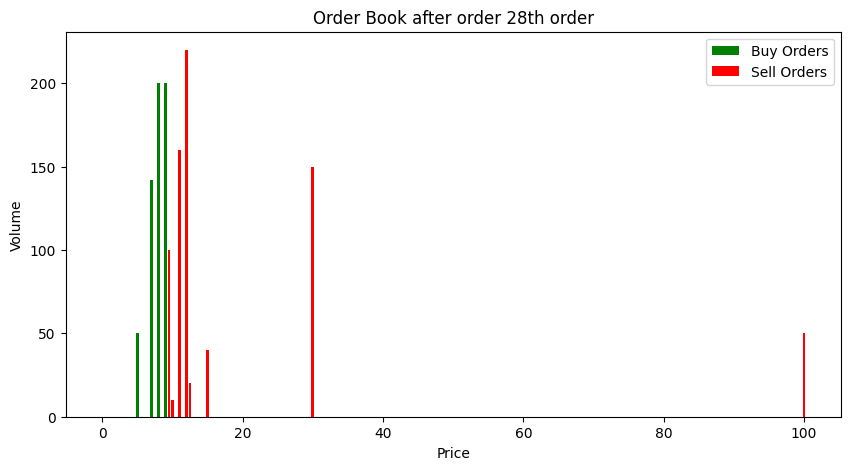

____________________________________________________________________________________
____________________________________________________________________________________

Order Book after 29th order:
   Bid Size  Bid Price  Ask Price  Ask Size
0       200        9.0        9.5       100
1       200        8.0       10.0        50
2       142        7.0       11.0       160
3        50        5.0       12.0       220
4      <NA>        NaN       12.5        20
5      <NA>        NaN       15.0        40
6      <NA>        NaN       30.0       150
7      <NA>        NaN      100.0        50

Trade Log:
            timestamp  buy_group  sell_group  price  size
0  9/30/2024 20:26:34         11          12   10.0    40
1  9/30/2024 20:26:39          9          12   10.0    10
2  9/30/2024 20:26:39          9           4   10.0    50
3  9/30/2024 20:26:47          3           4   10.0    10
4  9/30/2024 20:27:20          1          14   11.0    10
5  9/30/2024 20:31:47          3          18

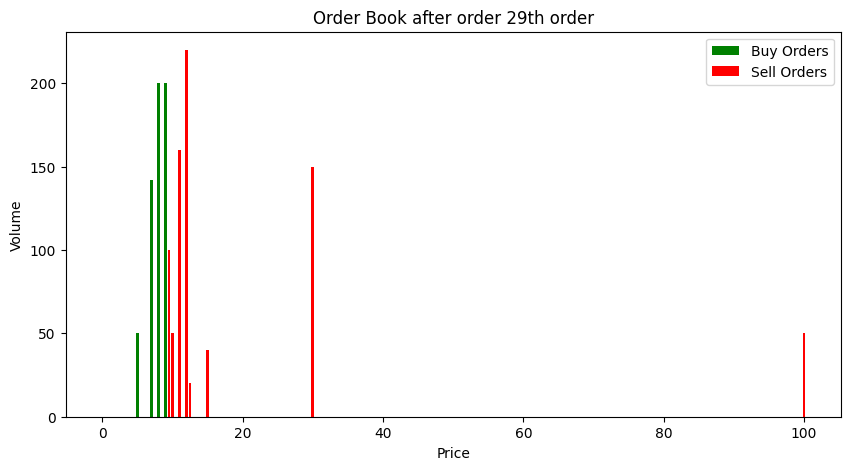

____________________________________________________________________________________
____________________________________________________________________________________

Order Book after 30th order:
   Bid Size  Bid Price  Ask Price  Ask Size
0       200        9.0        9.5       100
1       200        8.0       10.0        50
2       142        7.0       11.0       260
3        50        5.0       12.0       220
4      <NA>        NaN       12.5        20
5      <NA>        NaN       15.0        40
6      <NA>        NaN       30.0       150
7      <NA>        NaN      100.0        50

Trade Log:
            timestamp  buy_group  sell_group  price  size
0  9/30/2024 20:26:34         11          12   10.0    40
1  9/30/2024 20:26:39          9          12   10.0    10
2  9/30/2024 20:26:39          9           4   10.0    50
3  9/30/2024 20:26:47          3           4   10.0    10
4  9/30/2024 20:27:20          1          14   11.0    10
5  9/30/2024 20:31:47          3          18

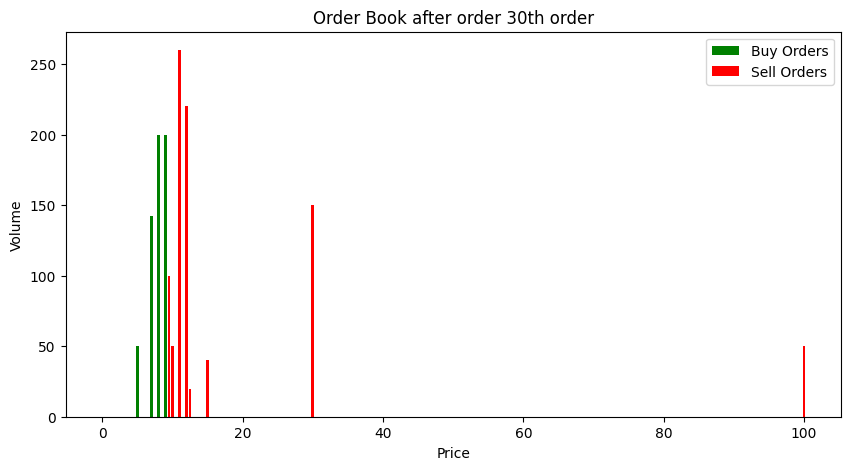

____________________________________________________________________________________
____________________________________________________________________________________

Order Book after 31th order:
   Bid Size  Bid Price  Ask Price  Ask Size
0       200        9.0        9.5        50
1       200        8.0       10.0        50
2       142        7.0       11.0       260
3        50        5.0       12.0       220
4      <NA>        NaN       12.5        20
5      <NA>        NaN       15.0        40
6      <NA>        NaN       30.0       150
7      <NA>        NaN      100.0        50

Trade Log:
            timestamp  buy_group  sell_group  price  size
0  9/30/2024 20:26:34         11          12   10.0    40
1  9/30/2024 20:26:39          9          12   10.0    10
2  9/30/2024 20:26:39          9           4   10.0    50
3  9/30/2024 20:26:47          3           4   10.0    10
4  9/30/2024 20:27:20          1          14   11.0    10
5  9/30/2024 20:31:47          3          18

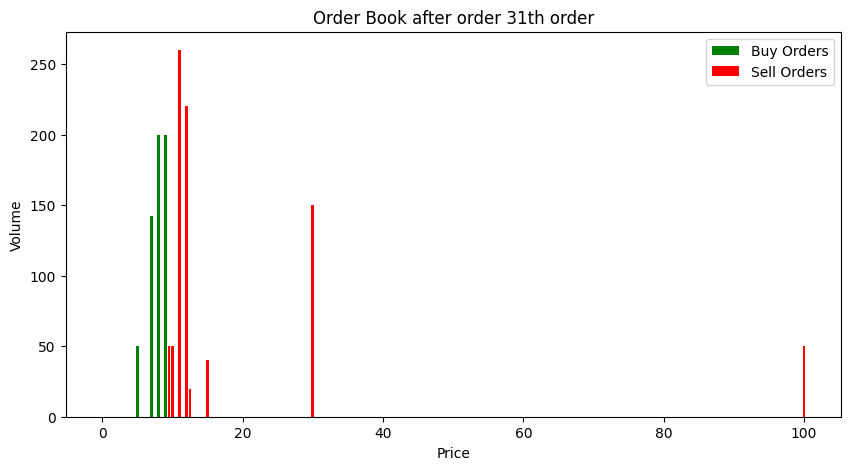

____________________________________________________________________________________
____________________________________________________________________________________

Order Book after 32th order:
   Bid Size  Bid Price  Ask Price  Ask Size
0       200        9.0        9.5        50
1       200        8.0       10.0        50
2       142        7.0       11.0       260
3        50        5.0       11.5        20
4      <NA>        NaN       12.0       220
5      <NA>        NaN       12.5        20
6      <NA>        NaN       15.0        40
7      <NA>        NaN       30.0       150
8      <NA>        NaN      100.0        50

Trade Log:
            timestamp  buy_group  sell_group  price  size
0  9/30/2024 20:26:34         11          12   10.0    40
1  9/30/2024 20:26:39          9          12   10.0    10
2  9/30/2024 20:26:39          9           4   10.0    50
3  9/30/2024 20:26:47          3           4   10.0    10
4  9/30/2024 20:27:20          1          14   11.0    10


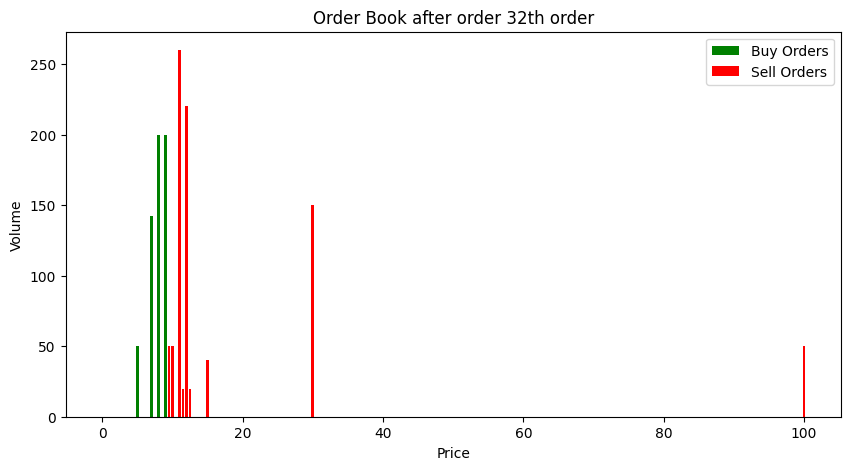

____________________________________________________________________________________
____________________________________________________________________________________

Order Book after 33th order:
   Bid Size  Bid Price  Ask Price  Ask Size
0       200        9.0        9.5        50
1       200        8.0       10.0        80
2       142        7.0       11.0       260
3        50        5.0       11.5        20
4      <NA>        NaN       12.0       220
5      <NA>        NaN       12.5        20
6      <NA>        NaN       15.0        40
7      <NA>        NaN       30.0       150
8      <NA>        NaN      100.0        50

Trade Log:
            timestamp  buy_group  sell_group  price  size
0  9/30/2024 20:26:34         11          12   10.0    40
1  9/30/2024 20:26:39          9          12   10.0    10
2  9/30/2024 20:26:39          9           4   10.0    50
3  9/30/2024 20:26:47          3           4   10.0    10
4  9/30/2024 20:27:20          1          14   11.0    10


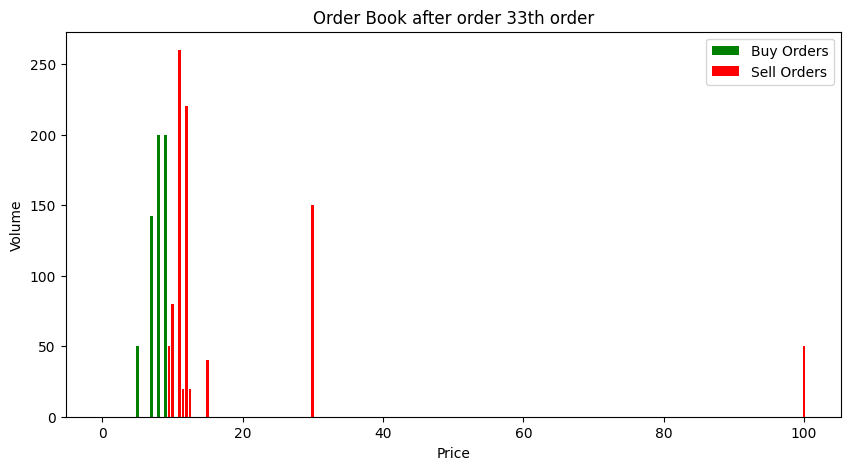

____________________________________________________________________________________
____________________________________________________________________________________

Order Book after 34th order:
   Bid Size  Bid Price  Ask Price  Ask Size
0       200        9.0       9.50        50
1       200        8.0      10.00        80
2       142        7.0      11.00       260
3        50        5.0      11.50        20
4      <NA>        NaN      11.75        25
5      <NA>        NaN      12.00       220
6      <NA>        NaN      12.50        20
7      <NA>        NaN      15.00        40
8      <NA>        NaN      30.00       150
9      <NA>        NaN     100.00        50

Trade Log:
            timestamp  buy_group  sell_group  price  size
0  9/30/2024 20:26:34         11          12   10.0    40
1  9/30/2024 20:26:39          9          12   10.0    10
2  9/30/2024 20:26:39          9           4   10.0    50
3  9/30/2024 20:26:47          3           4   10.0    10
4  9/30/2024 2

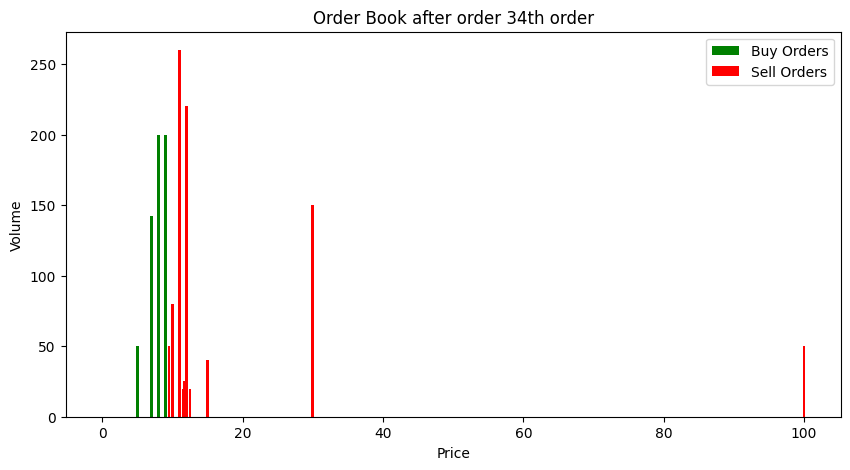

____________________________________________________________________________________
____________________________________________________________________________________

Order Book after 35th order:
    Bid Size  Bid Price  Ask Price  Ask Size
0        200        9.0       9.50        50
1        200        8.0      10.00        80
2        142        7.0      11.00       260
3         50        5.0      11.50        20
4       <NA>        NaN      11.75        25
5       <NA>        NaN      12.00       220
6       <NA>        NaN      12.50        20
7       <NA>        NaN      14.00        10
8       <NA>        NaN      15.00        40
9       <NA>        NaN      30.00       150
10      <NA>        NaN     100.00        50

Trade Log:
            timestamp  buy_group  sell_group  price  size
0  9/30/2024 20:26:34         11          12   10.0    40
1  9/30/2024 20:26:39          9          12   10.0    10
2  9/30/2024 20:26:39          9           4   10.0    50
3  9/30/2024 20:

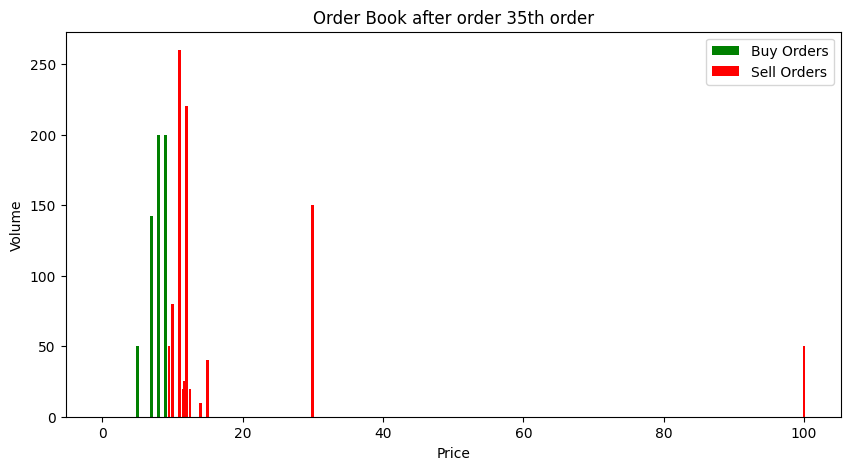

____________________________________________________________________________________
____________________________________________________________________________________

Order Book after 36th order:
    Bid Size  Bid Price  Ask Price  Ask Size
0        250        9.0       9.50        50
1        200        8.0      10.00        80
2        142        7.0      11.00       260
3         50        5.0      11.50        20
4       <NA>        NaN      11.75        25
5       <NA>        NaN      12.00       220
6       <NA>        NaN      12.50        20
7       <NA>        NaN      14.00        10
8       <NA>        NaN      15.00        40
9       <NA>        NaN      30.00       150
10      <NA>        NaN     100.00        50

Trade Log:
            timestamp  buy_group  sell_group  price  size
0  9/30/2024 20:26:34         11          12   10.0    40
1  9/30/2024 20:26:39          9          12   10.0    10
2  9/30/2024 20:26:39          9           4   10.0    50
3  9/30/2024 20:

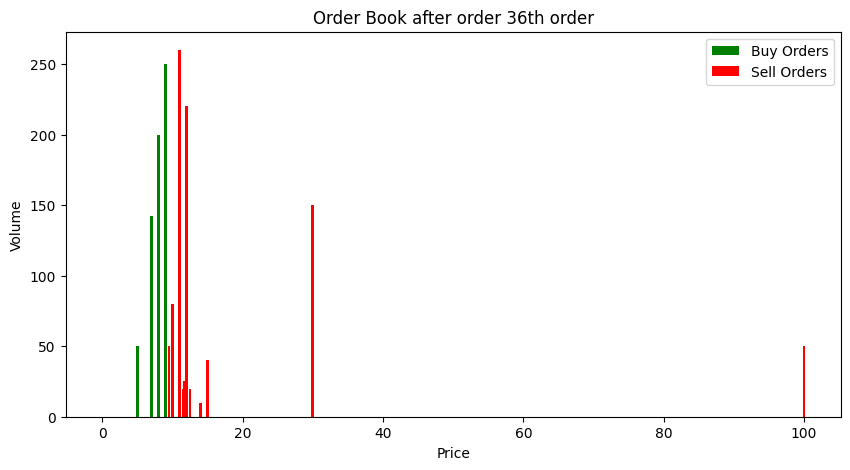

____________________________________________________________________________________
____________________________________________________________________________________

Order Book after 37th order:
   Bid Size  Bid Price  Ask Price  Ask Size
0       250        9.0      10.00        30
1       200        8.0      11.00       260
2       142        7.0      11.50        20
3        50        5.0      11.75        25
4      <NA>        NaN      12.00       220
5      <NA>        NaN      12.50        20
6      <NA>        NaN      14.00        10
7      <NA>        NaN      15.00        40
8      <NA>        NaN      30.00       150
9      <NA>        NaN     100.00        50

Trade Log:
             timestamp  buy_group  sell_group  price  size
0   9/30/2024 20:26:34         11          12   10.0    40
1   9/30/2024 20:26:39          9          12   10.0    10
2   9/30/2024 20:26:39          9           4   10.0    50
3   9/30/2024 20:26:47          3           4   10.0    10
4   9/30/

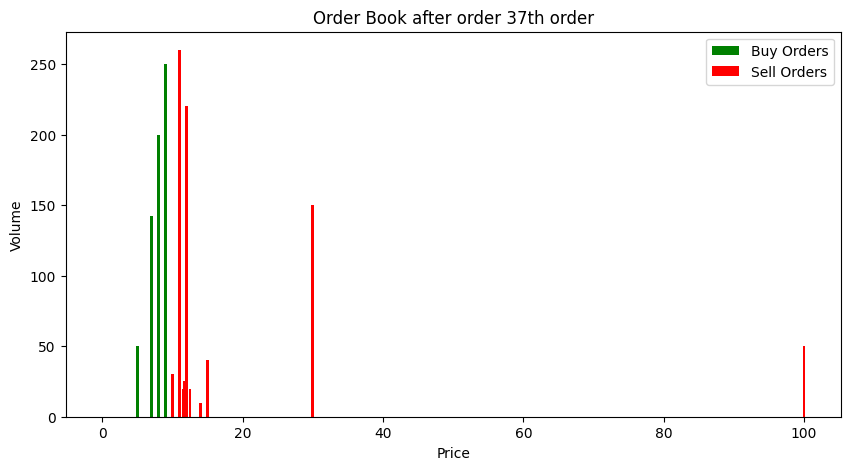

____________________________________________________________________________________
____________________________________________________________________________________

Order Book after 38th order:
   Bid Size  Bid Price  Ask Price  Ask Size
0       250        9.0      11.00       190
1       200        8.0      11.50        20
2       142        7.0      11.75        25
3        50        5.0      12.00       220
4      <NA>        NaN      12.50        20
5      <NA>        NaN      14.00        10
6      <NA>        NaN      15.00        40
7      <NA>        NaN      30.00       150
8      <NA>        NaN     100.00        50

Trade Log:
             timestamp  buy_group  sell_group  price  size
0   9/30/2024 20:26:34         11          12   10.0    40
1   9/30/2024 20:26:39          9          12   10.0    10
2   9/30/2024 20:26:39          9           4   10.0    50
3   9/30/2024 20:26:47          3           4   10.0    10
4   9/30/2024 20:27:20          1          14   11.0 

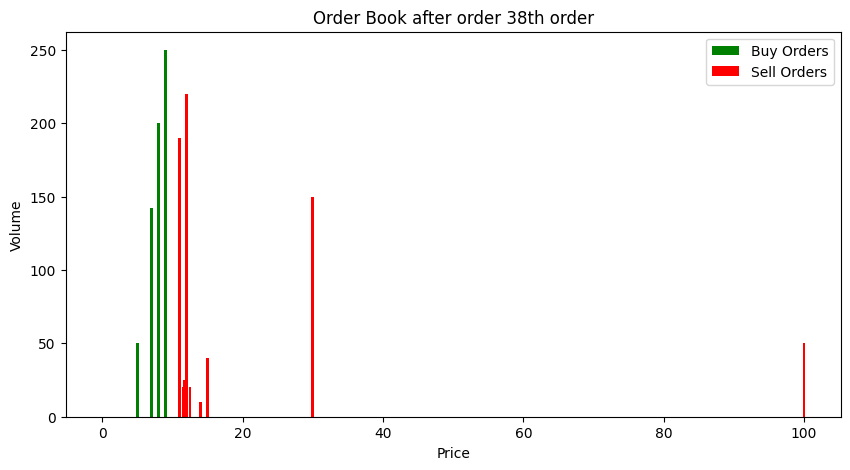

____________________________________________________________________________________
____________________________________________________________________________________

Order Book after 39th order:
   Bid Size  Bid Price  Ask Price  Ask Size
0       250        9.0      11.00       190
1       200        8.0      11.50        20
2       142        7.0      11.75        25
3        50        5.0      11.95        15
4      <NA>        NaN      12.00       220
5      <NA>        NaN      12.50        20
6      <NA>        NaN      14.00        10
7      <NA>        NaN      15.00        40
8      <NA>        NaN      30.00       150
9      <NA>        NaN     100.00        50

Trade Log:
             timestamp  buy_group  sell_group  price  size
0   9/30/2024 20:26:34         11          12   10.0    40
1   9/30/2024 20:26:39          9          12   10.0    10
2   9/30/2024 20:26:39          9           4   10.0    50
3   9/30/2024 20:26:47          3           4   10.0    10
4   9/30/

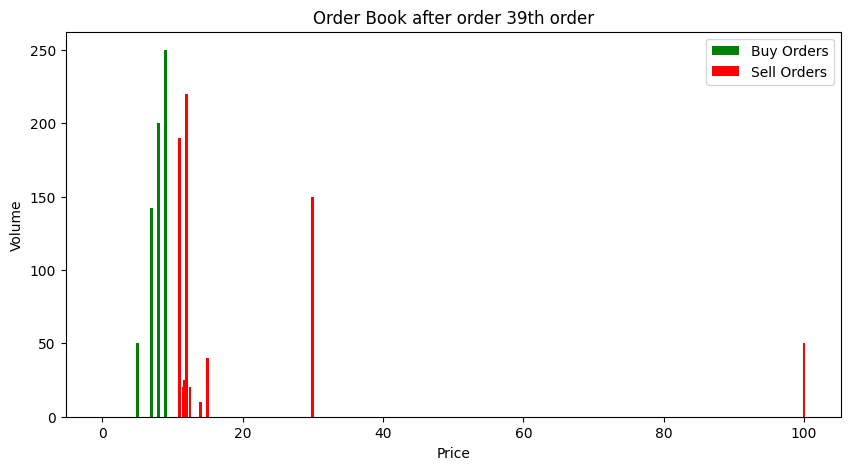

____________________________________________________________________________________
____________________________________________________________________________________

Order Book after 40th order:
    Bid Size  Bid Price  Ask Price  Ask Size
0        250        9.0      10.90        10
1        200        8.0      11.00       190
2        142        7.0      11.50        20
3         50        5.0      11.75        25
4       <NA>        NaN      11.95        15
5       <NA>        NaN      12.00       220
6       <NA>        NaN      12.50        20
7       <NA>        NaN      14.00        10
8       <NA>        NaN      15.00        40
9       <NA>        NaN      30.00       150
10      <NA>        NaN     100.00        50

Trade Log:
             timestamp  buy_group  sell_group  price  size
0   9/30/2024 20:26:34         11          12   10.0    40
1   9/30/2024 20:26:39          9          12   10.0    10
2   9/30/2024 20:26:39          9           4   10.0    50
3   9/30/202

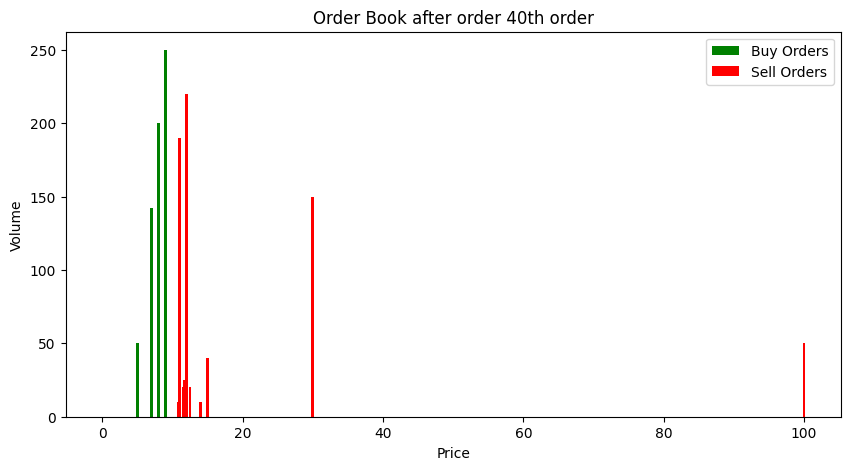

____________________________________________________________________________________
____________________________________________________________________________________

Order Book after 41th order:
    Bid Size  Bid Price  Ask Price  Ask Size
0        250        9.0      10.90        10
1        200        8.0      11.00       190
2        142        7.0      11.01        90
3         50        5.0      11.50        20
4       <NA>        NaN      11.75        25
5       <NA>        NaN      11.95        15
6       <NA>        NaN      12.00       220
7       <NA>        NaN      12.50        20
8       <NA>        NaN      14.00        10
9       <NA>        NaN      15.00        40
10      <NA>        NaN      30.00       150
11      <NA>        NaN     100.00        50

Trade Log:
             timestamp  buy_group  sell_group  price  size
0   9/30/2024 20:26:34         11          12   10.0    40
1   9/30/2024 20:26:39          9          12   10.0    10
2   9/30/2024 20:26:39    

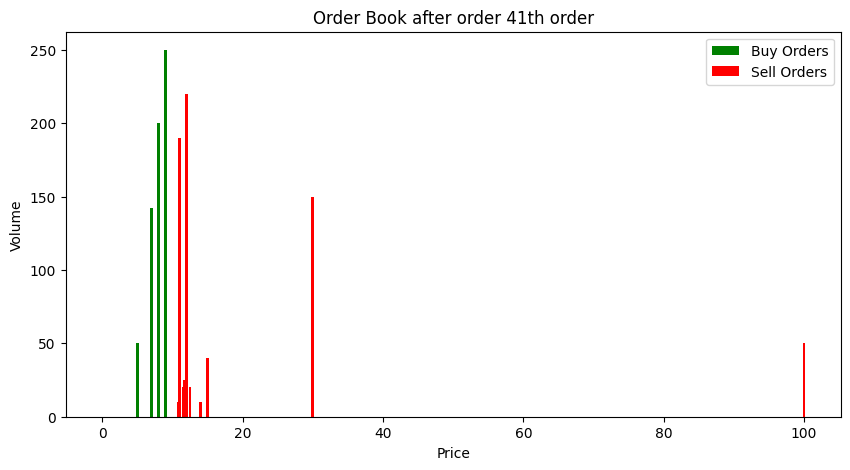

____________________________________________________________________________________
____________________________________________________________________________________

Order Book after 42th order:
    Bid Size  Bid Price  Ask Price  Ask Size
0        250        9.0      10.10       100
1        200        8.0      10.90        10
2        142        7.0      11.00       190
3         50        5.0      11.01        90
4       <NA>        NaN      11.50        20
5       <NA>        NaN      11.75        25
6       <NA>        NaN      11.95        15
7       <NA>        NaN      12.00       220
8       <NA>        NaN      12.50        20
9       <NA>        NaN      14.00        10
10      <NA>        NaN      15.00        40
11      <NA>        NaN      30.00       150
12      <NA>        NaN     100.00        50

Trade Log:
             timestamp  buy_group  sell_group  price  size
0   9/30/2024 20:26:34         11          12   10.0    40
1   9/30/2024 20:26:39          9       

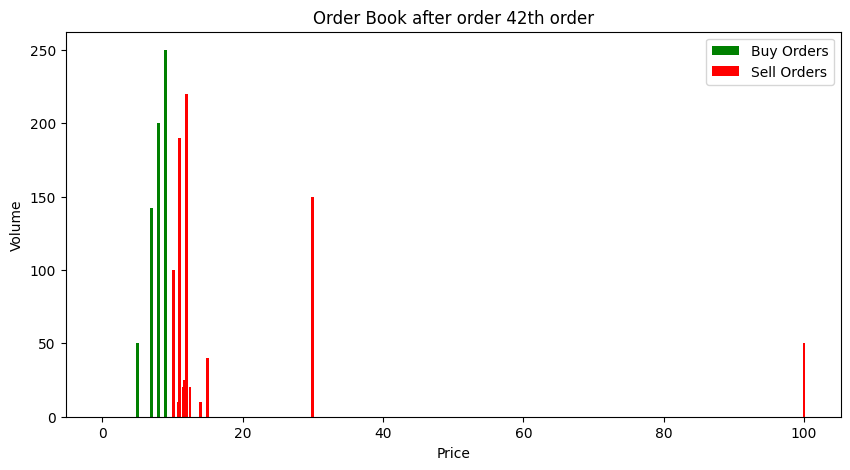

____________________________________________________________________________________
____________________________________________________________________________________

Order Book after 43th order:
    Bid Size  Bid Price  Ask Price  Ask Size
0        250        9.0      10.10       100
1        200        8.0      10.50       100
2        142        7.0      10.90        10
3         50        5.0      11.00       190
4       <NA>        NaN      11.01        90
5       <NA>        NaN      11.50        20
6       <NA>        NaN      11.75        25
7       <NA>        NaN      11.95        15
8       <NA>        NaN      12.00       220
9       <NA>        NaN      12.50        20
10      <NA>        NaN      14.00        10
11      <NA>        NaN      15.00        40
12      <NA>        NaN      30.00       150
13      <NA>        NaN     100.00        50

Trade Log:
             timestamp  buy_group  sell_group  price  size
0   9/30/2024 20:26:34         11          12   10.0  

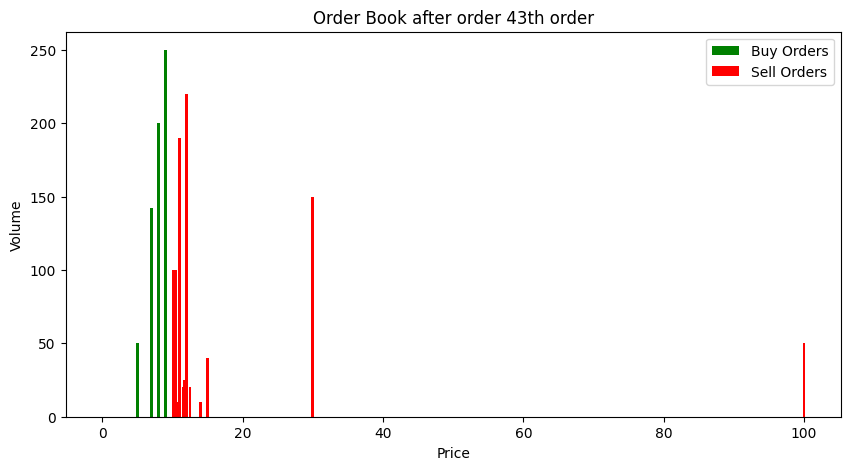

____________________________________________________________________________________
____________________________________________________________________________________

Order Book after 44th order:
    Bid Size  Bid Price  Ask Price  Ask Size
0        250        9.0      10.10       100
1        200        8.0      10.50       100
2        142        7.0      10.90        10
3         50        5.0      11.00       190
4       <NA>        NaN      11.01        90
5       <NA>        NaN      11.50        20
6       <NA>        NaN      11.75        25
7       <NA>        NaN      11.95        15
8       <NA>        NaN      12.00       260
9       <NA>        NaN      12.50        20
10      <NA>        NaN      14.00        10
11      <NA>        NaN      15.00        40
12      <NA>        NaN      30.00       150
13      <NA>        NaN     100.00        50

Trade Log:
             timestamp  buy_group  sell_group  price  size
0   9/30/2024 20:26:34         11          12   10.0  

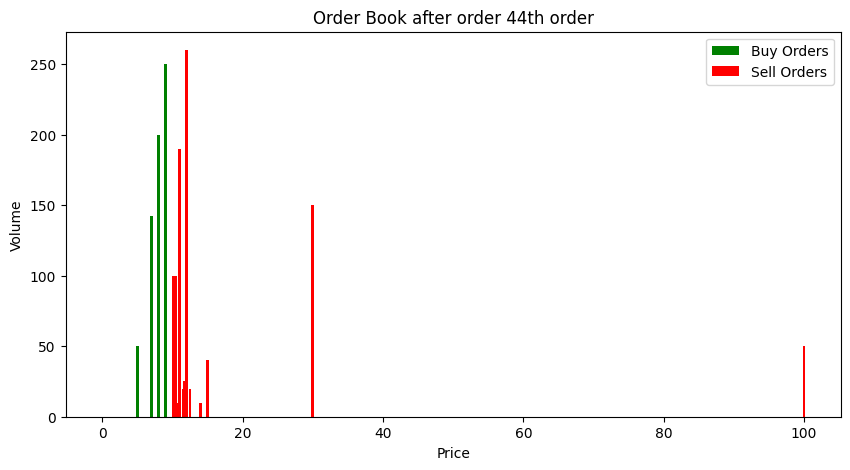

____________________________________________________________________________________
____________________________________________________________________________________

Order Book after 45th order:
    Bid Size  Bid Price  Ask Price  Ask Size
0        250        9.0      10.10       100
1        200        8.0      10.50       100
2        142        7.0      10.60        10
3         50        5.0      10.90        10
4       <NA>        NaN      11.00       190
5       <NA>        NaN      11.01        90
6       <NA>        NaN      11.50        20
7       <NA>        NaN      11.75        25
8       <NA>        NaN      11.95        15
9       <NA>        NaN      12.00       260
10      <NA>        NaN      12.50        20
11      <NA>        NaN      14.00        10
12      <NA>        NaN      15.00        40
13      <NA>        NaN      30.00       150
14      <NA>        NaN     100.00        50

Trade Log:
             timestamp  buy_group  sell_group  price  size
0   9/30/

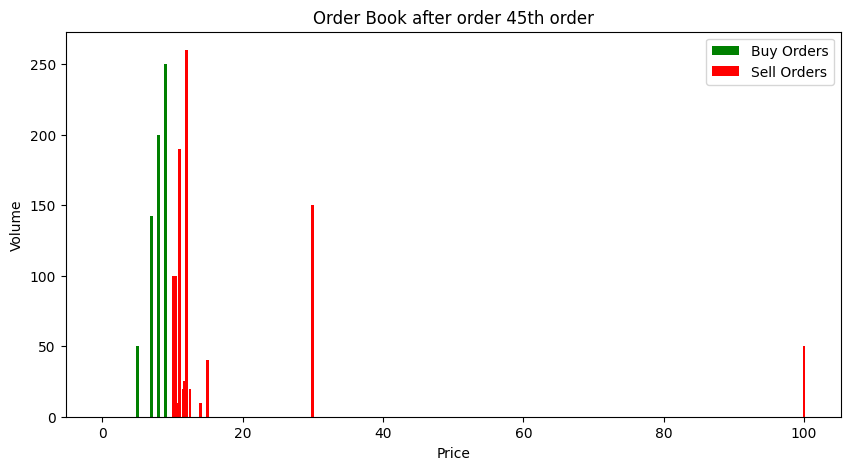

____________________________________________________________________________________
____________________________________________________________________________________

Order Book after 46th order:
    Bid Size  Bid Price  Ask Price  Ask Size
0        250        9.0      10.10       100
1        200        8.0      10.50       130
2        142        7.0      10.60        10
3         50        5.0      10.90        10
4       <NA>        NaN      11.00       190
5       <NA>        NaN      11.01        90
6       <NA>        NaN      11.50        20
7       <NA>        NaN      11.75        25
8       <NA>        NaN      11.95        15
9       <NA>        NaN      12.00       260
10      <NA>        NaN      12.50        20
11      <NA>        NaN      14.00        10
12      <NA>        NaN      15.00        40
13      <NA>        NaN      30.00       150
14      <NA>        NaN     100.00        50

Trade Log:
             timestamp  buy_group  sell_group  price  size
0   9/30/

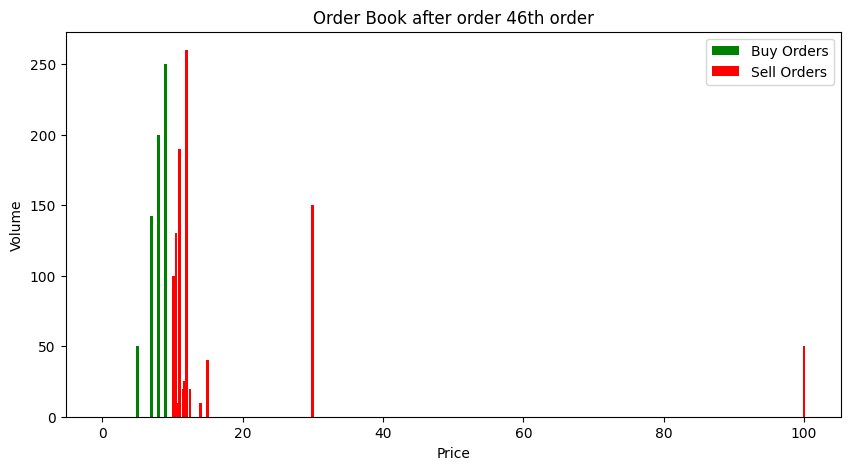

____________________________________________________________________________________
____________________________________________________________________________________

Order Book after 47th order:
    Bid Size  Bid Price  Ask Price  Ask Size
0        250        9.0      10.00        70
1        200        8.0      10.10       100
2        142        7.0      10.50       130
3         50        5.0      10.60        10
4       <NA>        NaN      10.90        10
5       <NA>        NaN      11.00       190
6       <NA>        NaN      11.01        90
7       <NA>        NaN      11.50        20
8       <NA>        NaN      11.75        25
9       <NA>        NaN      11.95        15
10      <NA>        NaN      12.00       260
11      <NA>        NaN      12.50        20
12      <NA>        NaN      14.00        10
13      <NA>        NaN      15.00        40
14      <NA>        NaN      30.00       150
15      <NA>        NaN     100.00        50

Trade Log:
             timestamp 

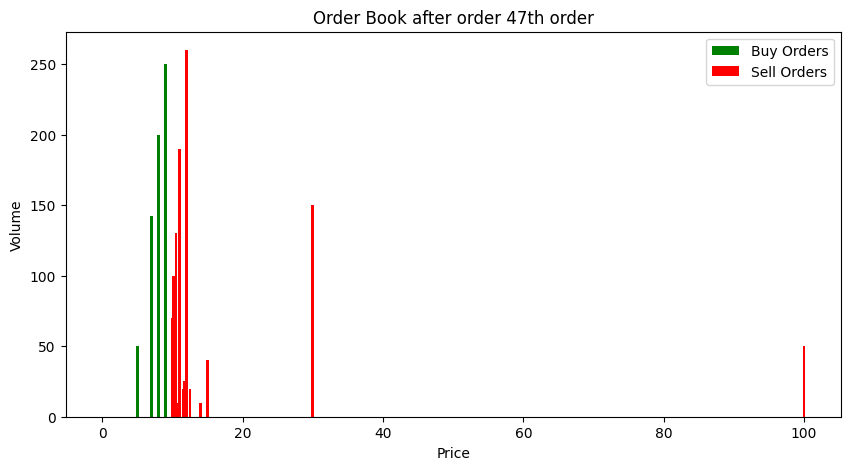

____________________________________________________________________________________
____________________________________________________________________________________

Order Book after 48th order:
    Bid Size  Bid Price  Ask Price  Ask Size
0        250        9.0      10.00        70
1        200        8.0      10.10       100
2        142        7.0      10.50       130
3         50        5.0      10.60        10
4       <NA>        NaN      10.80        10
5       <NA>        NaN      10.90        10
6       <NA>        NaN      11.00       190
7       <NA>        NaN      11.01        90
8       <NA>        NaN      11.50        20
9       <NA>        NaN      11.75        25
10      <NA>        NaN      11.95        15
11      <NA>        NaN      12.00       260
12      <NA>        NaN      12.50        20
13      <NA>        NaN      14.00        10
14      <NA>        NaN      15.00        40
15      <NA>        NaN      30.00       150
16      <NA>        NaN     100.00 

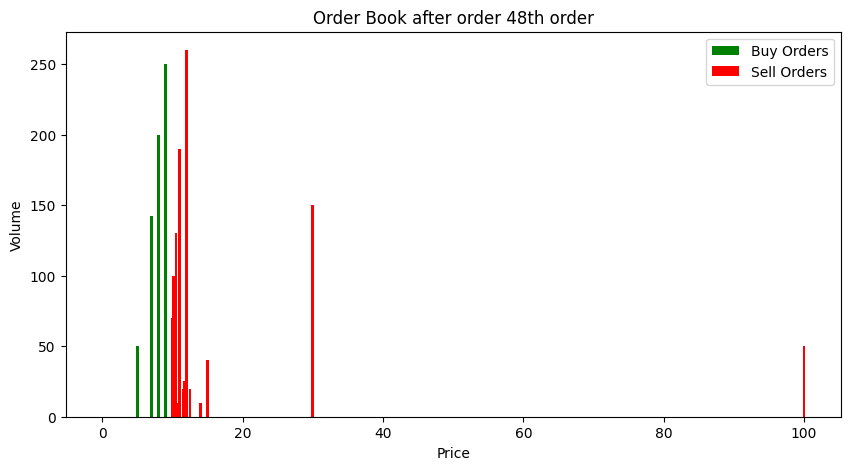

____________________________________________________________________________________
____________________________________________________________________________________

Order Book after 49th order:
    Bid Size  Bid Price  Ask Price  Ask Size
0          5        9.9      10.00        70
1        250        9.0      10.10       100
2        200        8.0      10.50       130
3        142        7.0      10.60        10
4         50        5.0      10.80        10
5       <NA>        NaN      10.90        10
6       <NA>        NaN      11.00       190
7       <NA>        NaN      11.01        90
8       <NA>        NaN      11.50        20
9       <NA>        NaN      11.75        25
10      <NA>        NaN      11.95        15
11      <NA>        NaN      12.00       260
12      <NA>        NaN      12.50        20
13      <NA>        NaN      14.00        10
14      <NA>        NaN      15.00        40
15      <NA>        NaN      30.00       150
16      <NA>        NaN     100.00 

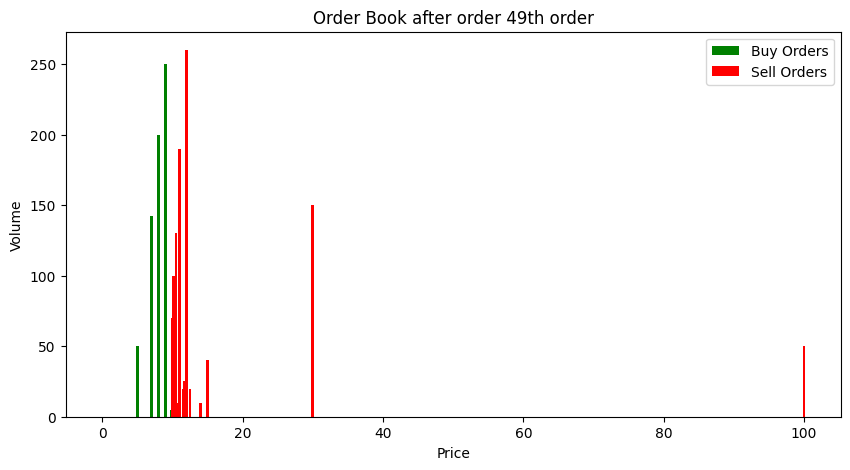

____________________________________________________________________________________
____________________________________________________________________________________

Order Book after 50th order:
    Bid Size  Bid Price  Ask Price  Ask Size
0          5        9.9      10.10        90
1        250        9.0      10.50       130
2        200        8.0      10.60        10
3        142        7.0      10.80        10
4         50        5.0      10.90        10
5       <NA>        NaN      11.00       190
6       <NA>        NaN      11.01        90
7       <NA>        NaN      11.50        20
8       <NA>        NaN      11.75        25
9       <NA>        NaN      11.95        15
10      <NA>        NaN      12.00       260
11      <NA>        NaN      12.50        20
12      <NA>        NaN      14.00        10
13      <NA>        NaN      15.00        40
14      <NA>        NaN      30.00       150
15      <NA>        NaN     100.00        50

Trade Log:
             timestamp 

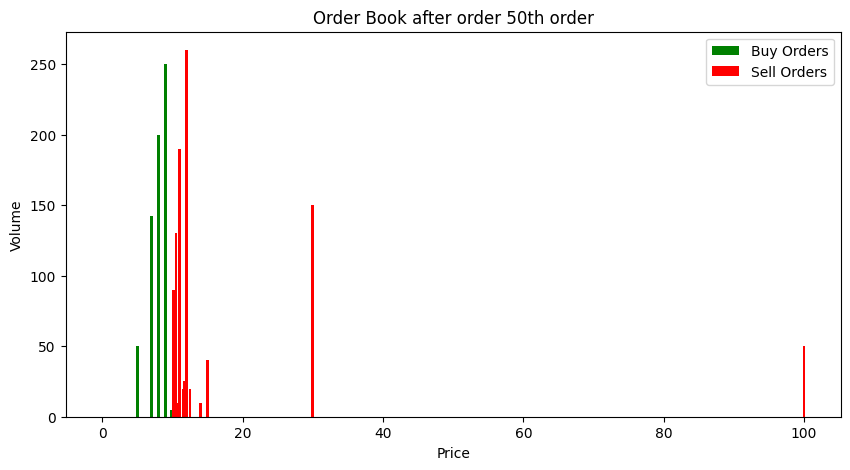

____________________________________________________________________________________
____________________________________________________________________________________

Order Book after 51th order:
    Bid Size  Bid Price  Ask Price  Ask Size
0          5        9.9      10.10        90
1        250        9.0      10.50       140
2        200        8.0      10.60        10
3        142        7.0      10.80        10
4         50        5.0      10.90        10
5       <NA>        NaN      11.00       190
6       <NA>        NaN      11.01        90
7       <NA>        NaN      11.50        20
8       <NA>        NaN      11.75        25
9       <NA>        NaN      11.95        15
10      <NA>        NaN      12.00       260
11      <NA>        NaN      12.50        20
12      <NA>        NaN      14.00        10
13      <NA>        NaN      15.00        40
14      <NA>        NaN      30.00       150
15      <NA>        NaN     100.00        50

Trade Log:
             timestamp 

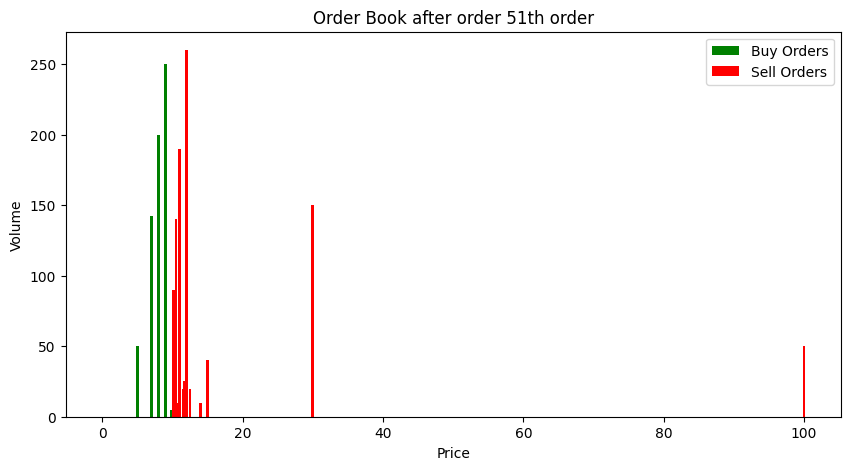

____________________________________________________________________________________
____________________________________________________________________________________

Order Book after 52th order:
    Bid Size  Bid Price  Ask Price  Ask Size
0          5       9.90      10.10        90
1          5       9.85      10.50       140
2        250       9.00      10.60        10
3        200       8.00      10.80        10
4        142       7.00      10.90        10
5         50       5.00      11.00       190
6       <NA>        NaN      11.01        90
7       <NA>        NaN      11.50        20
8       <NA>        NaN      11.75        25
9       <NA>        NaN      11.95        15
10      <NA>        NaN      12.00       260
11      <NA>        NaN      12.50        20
12      <NA>        NaN      14.00        10
13      <NA>        NaN      15.00        40
14      <NA>        NaN      30.00       150
15      <NA>        NaN     100.00        50

Trade Log:
             timestamp 

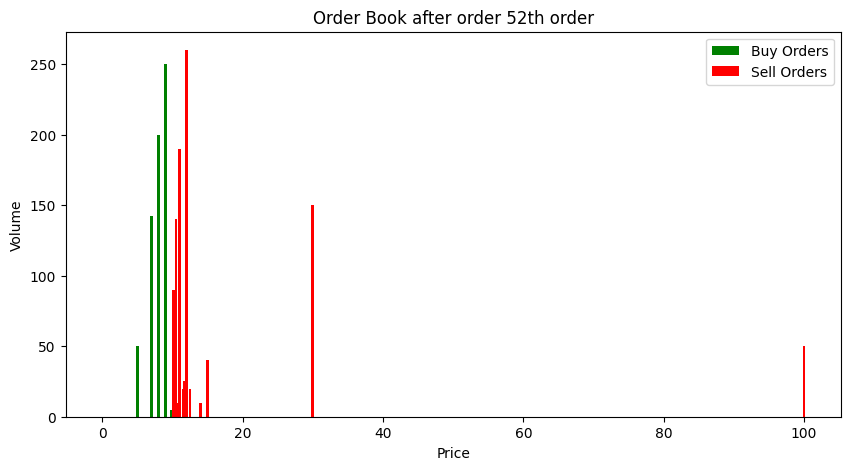

____________________________________________________________________________________
____________________________________________________________________________________

Order Book after 53th order:
    Bid Size  Bid Price  Ask Price  Ask Size
0          5       9.90      10.10        90
1          5       9.85      10.50       140
2        250       9.00      10.60        10
3        200       8.00      10.80        10
4         25       7.77      10.90        10
5        142       7.00      11.00       190
6         50       5.00      11.01        90
7       <NA>        NaN      11.50        20
8       <NA>        NaN      11.75        25
9       <NA>        NaN      11.95        15
10      <NA>        NaN      12.00       260
11      <NA>        NaN      12.50        20
12      <NA>        NaN      14.00        10
13      <NA>        NaN      15.00        40
14      <NA>        NaN      30.00       150
15      <NA>        NaN     100.00        50

Trade Log:
             timestamp 

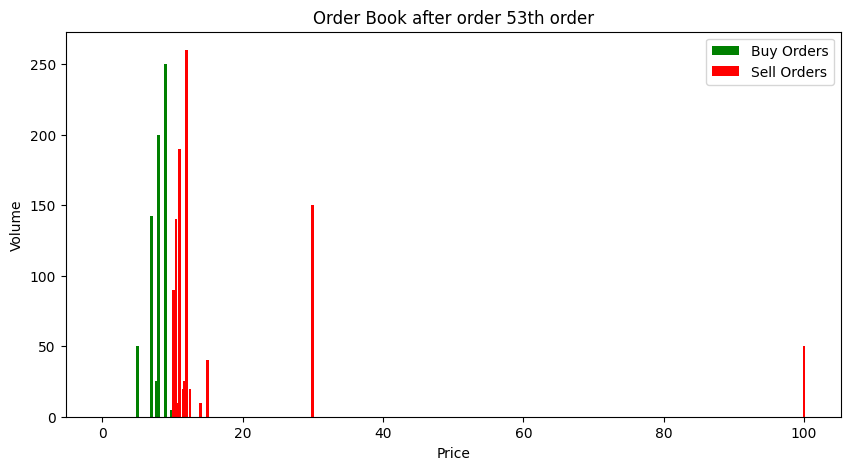

____________________________________________________________________________________
____________________________________________________________________________________

Order Book after 54th order:
    Bid Size  Bid Price  Ask Price  Ask Size
0          5       9.95      10.10        90
1          5       9.90      10.50       140
2          5       9.85      10.60        10
3        250       9.00      10.80        10
4        200       8.00      10.90        10
5         25       7.77      11.00       190
6        142       7.00      11.01        90
7         50       5.00      11.50        20
8       <NA>        NaN      11.75        25
9       <NA>        NaN      11.95        15
10      <NA>        NaN      12.00       260
11      <NA>        NaN      12.50        20
12      <NA>        NaN      14.00        10
13      <NA>        NaN      15.00        40
14      <NA>        NaN      30.00       150
15      <NA>        NaN     100.00        50

Trade Log:
             timestamp 

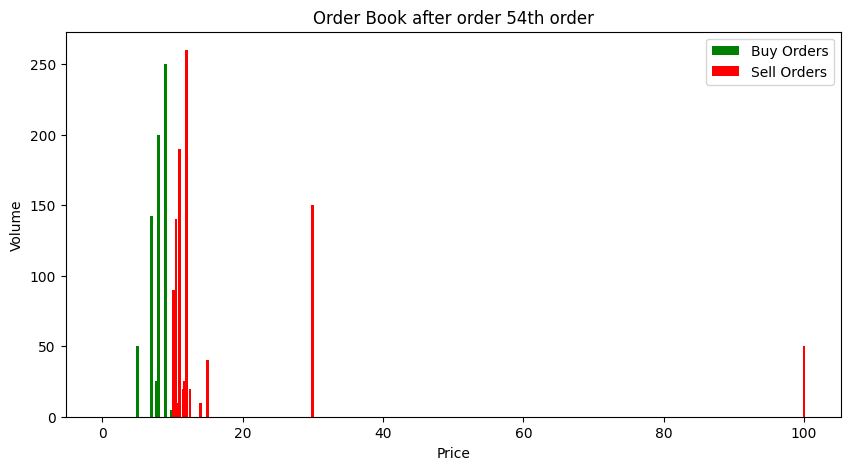

____________________________________________________________________________________
____________________________________________________________________________________

Order Book after 55th order:
    Bid Size  Bid Price  Ask Price  Ask Size
0          5       9.95      10.10        70
1          5       9.90      10.50       140
2          5       9.85      10.60        10
3        250       9.00      10.80        10
4        200       8.00      10.90        10
5         25       7.77      11.00       190
6        142       7.00      11.01        90
7         50       5.00      11.50        20
8       <NA>        NaN      11.75        25
9       <NA>        NaN      11.95        15
10      <NA>        NaN      12.00       260
11      <NA>        NaN      12.50        20
12      <NA>        NaN      14.00        10
13      <NA>        NaN      15.00        40
14      <NA>        NaN      30.00       150
15      <NA>        NaN     100.00        50

Trade Log:
             timestamp 

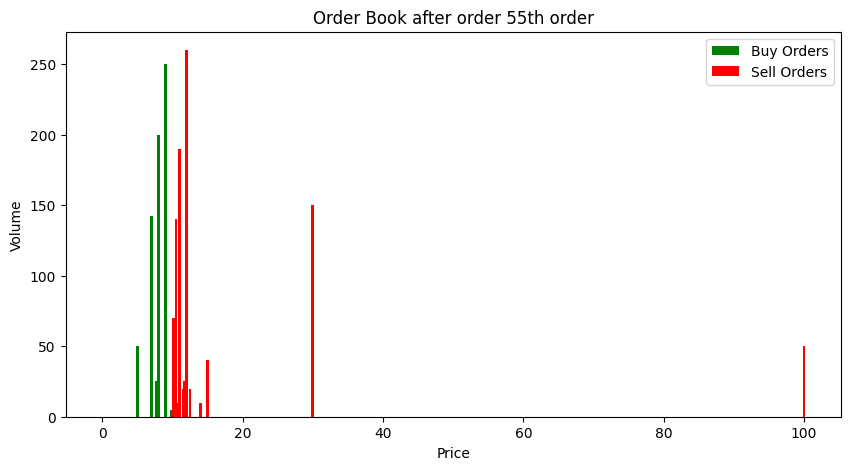

____________________________________________________________________________________
____________________________________________________________________________________

Order Book after 56th order:
    Bid Size  Bid Price  Ask Price  Ask Size
0          5       9.95      10.10        70
1          5       9.90      10.50       140
2          5       9.85      10.60        10
3        250       9.00      10.80        10
4        200       8.00      10.90        10
5         25       7.77      11.00       200
6        142       7.00      11.01        90
7         50       5.00      11.50        20
8       <NA>        NaN      11.75        25
9       <NA>        NaN      11.95        15
10      <NA>        NaN      12.00       260
11      <NA>        NaN      12.50        20
12      <NA>        NaN      14.00        10
13      <NA>        NaN      15.00        40
14      <NA>        NaN      30.00       150
15      <NA>        NaN     100.00        50

Trade Log:
             timestamp 

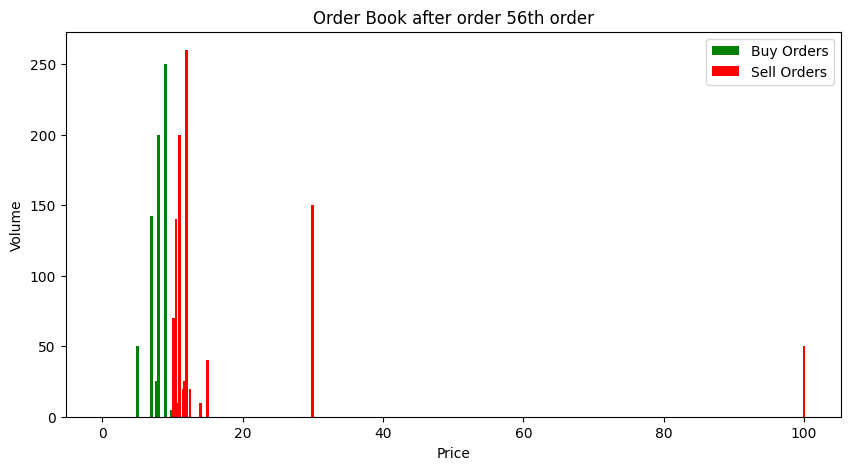

____________________________________________________________________________________
____________________________________________________________________________________

Order Book after 57th order:
    Bid Size  Bid Price  Ask Price  Ask Size
0          5       9.95      10.10        70
1          5       9.90      10.50       140
2          5       9.85      10.60        10
3          5       9.75      10.80        10
4        250       9.00      10.90        10
5        200       8.00      11.00       200
6         25       7.77      11.01        90
7        142       7.00      11.50        20
8         50       5.00      11.75        25
9       <NA>        NaN      11.95        15
10      <NA>        NaN      12.00       260
11      <NA>        NaN      12.50        20
12      <NA>        NaN      14.00        10
13      <NA>        NaN      15.00        40
14      <NA>        NaN      30.00       150
15      <NA>        NaN     100.00        50

Trade Log:
             timestamp 

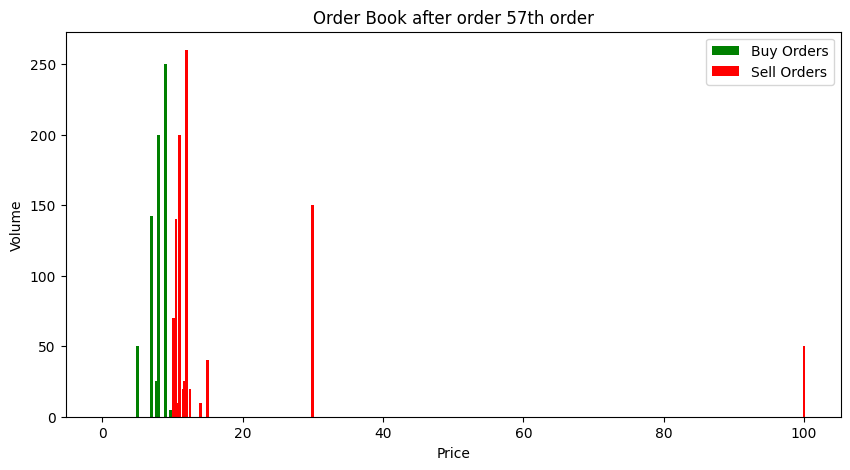

____________________________________________________________________________________
____________________________________________________________________________________

Order Book after 58th order:
    Bid Size  Bid Price  Ask Price  Ask Size
0          5       9.95      10.00       100
1          5       9.90      10.10        70
2          5       9.85      10.50       140
3          5       9.75      10.60        10
4        250       9.00      10.80        10
5        200       8.00      10.90        10
6         25       7.77      11.00       200
7        142       7.00      11.01        90
8         50       5.00      11.50        20
9       <NA>        NaN      11.75        25
10      <NA>        NaN      11.95        15
11      <NA>        NaN      12.00       260
12      <NA>        NaN      12.50        20
13      <NA>        NaN      14.00        10
14      <NA>        NaN      15.00        40
15      <NA>        NaN      30.00       150
16      <NA>        NaN     100.00 

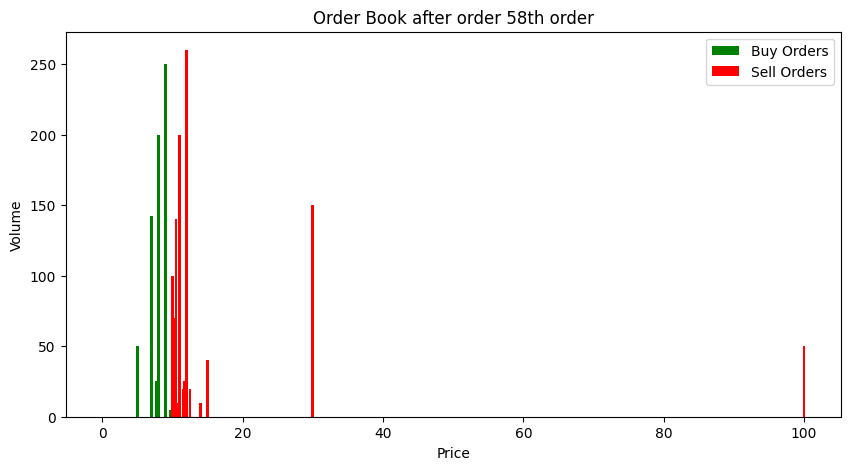

____________________________________________________________________________________
____________________________________________________________________________________

Order Book after 59th order:
    Bid Size  Bid Price  Ask Price  Ask Size
0          5       9.95      10.00       100
1          5       9.90      10.10        70
2          5       9.85      10.50       140
3          5       9.75      10.60        10
4        250       9.00      10.80        10
5         25       8.88      10.90        10
6        200       8.00      11.00       200
7         25       7.77      11.01        90
8        142       7.00      11.50        20
9         50       5.00      11.75        25
10      <NA>        NaN      11.95        15
11      <NA>        NaN      12.00       260
12      <NA>        NaN      12.50        20
13      <NA>        NaN      14.00        10
14      <NA>        NaN      15.00        40
15      <NA>        NaN      30.00       150
16      <NA>        NaN     100.00 

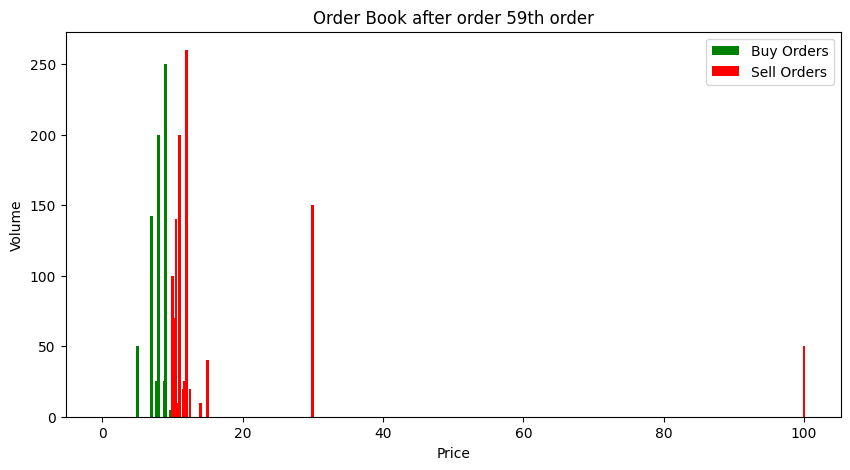

____________________________________________________________________________________
____________________________________________________________________________________

Order Book after 60th order:
    Bid Size  Bid Price  Ask Price  Ask Size
0        250       9.00       9.50        10
1         25       8.88      10.00       100
2        200       8.00      10.10        70
3         25       7.77      10.50       140
4        142       7.00      10.60        10
5         50       5.00      10.80        10
6       <NA>        NaN      10.90        10
7       <NA>        NaN      11.00       200
8       <NA>        NaN      11.01        90
9       <NA>        NaN      11.50        20
10      <NA>        NaN      11.75        25
11      <NA>        NaN      11.95        15
12      <NA>        NaN      12.00       260
13      <NA>        NaN      12.50        20
14      <NA>        NaN      14.00        10
15      <NA>        NaN      15.00        40
16      <NA>        NaN      30.00 

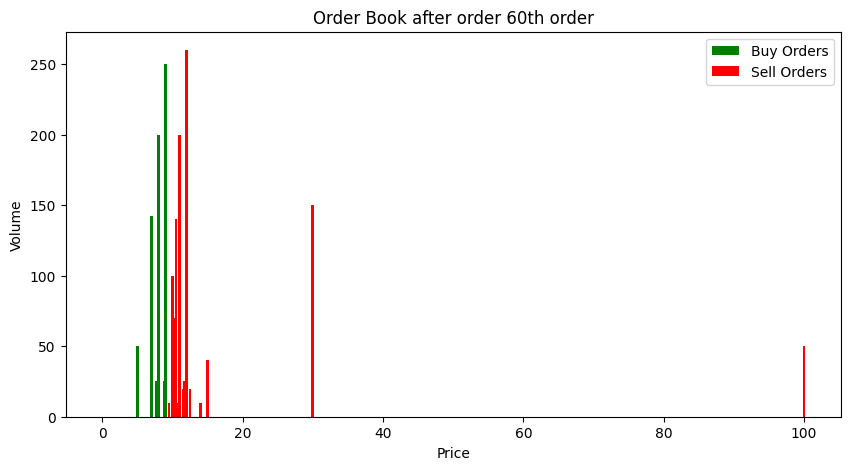

____________________________________________________________________________________
____________________________________________________________________________________

Order Book after 61th order:
    Bid Size  Bid Price  Ask Price  Ask Size
0        250       9.00      10.00       100
1         25       8.88      10.10        70
2        200       8.00      10.50       140
3         25       7.77      10.60        10
4        142       7.00      10.80        10
5         50       5.00      10.90        10
6       <NA>        NaN      11.00       200
7       <NA>        NaN      11.01        90
8       <NA>        NaN      11.50        20
9       <NA>        NaN      11.75        25
10      <NA>        NaN      11.95        15
11      <NA>        NaN      12.00       260
12      <NA>        NaN      12.50        20
13      <NA>        NaN      14.00        10
14      <NA>        NaN      15.00        40
15      <NA>        NaN      30.00       150
16      <NA>        NaN     100.00 

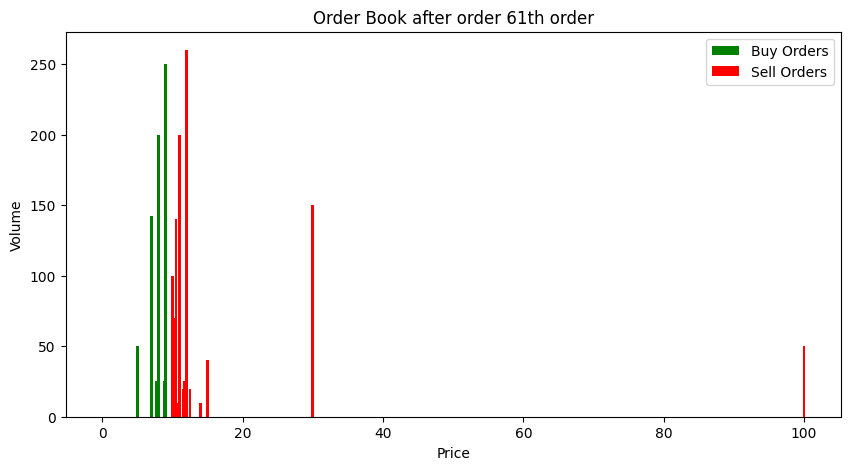

____________________________________________________________________________________
____________________________________________________________________________________

Order Book after 62th order:
    Bid Size  Bid Price  Ask Price  Ask Size
0        250       9.00      10.00        75
1         25       8.88      10.10        70
2        200       8.00      10.50       140
3         25       7.77      10.60        10
4        142       7.00      10.80        10
5         50       5.00      10.90        10
6       <NA>        NaN      11.00       200
7       <NA>        NaN      11.01        90
8       <NA>        NaN      11.50        20
9       <NA>        NaN      11.75        25
10      <NA>        NaN      11.95        15
11      <NA>        NaN      12.00       260
12      <NA>        NaN      12.50        20
13      <NA>        NaN      14.00        10
14      <NA>        NaN      15.00        40
15      <NA>        NaN      30.00       150
16      <NA>        NaN     100.00 

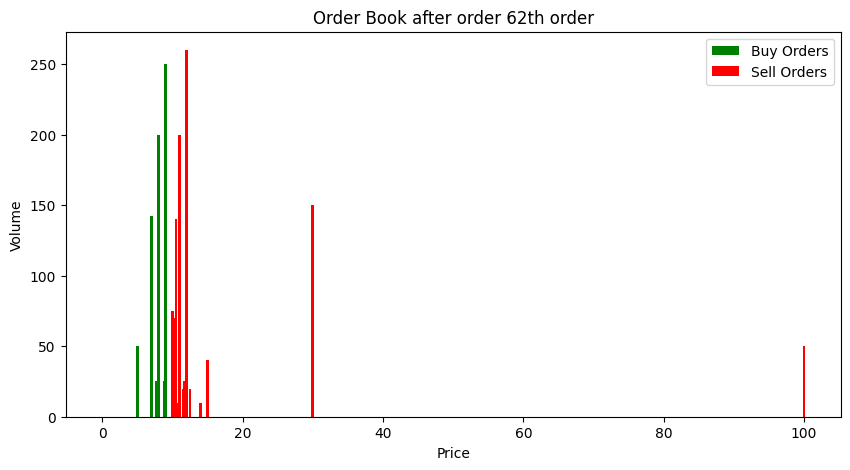

____________________________________________________________________________________
____________________________________________________________________________________

Order Book after 63th order:
    Bid Size  Bid Price  Ask Price  Ask Size
0        250       9.00      10.00        75
1         25       8.88      10.10        70
2        200       8.00      10.50       180
3         25       7.77      10.60        10
4        142       7.00      10.80        10
5         50       5.00      10.90        10
6       <NA>        NaN      11.00       200
7       <NA>        NaN      11.01        90
8       <NA>        NaN      11.50        20
9       <NA>        NaN      11.75        25
10      <NA>        NaN      11.95        15
11      <NA>        NaN      12.00       260
12      <NA>        NaN      12.50        20
13      <NA>        NaN      14.00        10
14      <NA>        NaN      15.00        40
15      <NA>        NaN      30.00       150
16      <NA>        NaN     100.00 

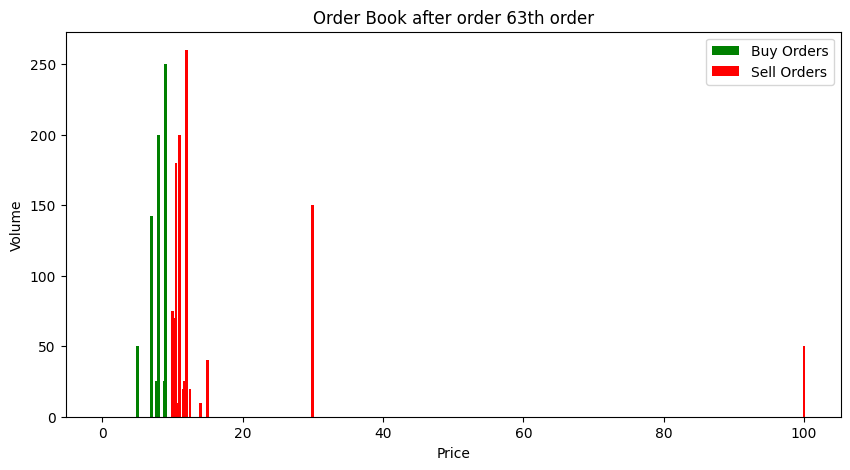

____________________________________________________________________________________
____________________________________________________________________________________

Order Book after 64th order:
    Bid Size  Bid Price  Ask Price  Ask Size
0          5       9.80      10.00        75
1        250       9.00      10.10        70
2         25       8.88      10.50       180
3        200       8.00      10.60        10
4         25       7.77      10.80        10
5        142       7.00      10.90        10
6         50       5.00      11.00       200
7       <NA>        NaN      11.01        90
8       <NA>        NaN      11.50        20
9       <NA>        NaN      11.75        25
10      <NA>        NaN      11.95        15
11      <NA>        NaN      12.00       260
12      <NA>        NaN      12.50        20
13      <NA>        NaN      14.00        10
14      <NA>        NaN      15.00        40
15      <NA>        NaN      30.00       150
16      <NA>        NaN     100.00 

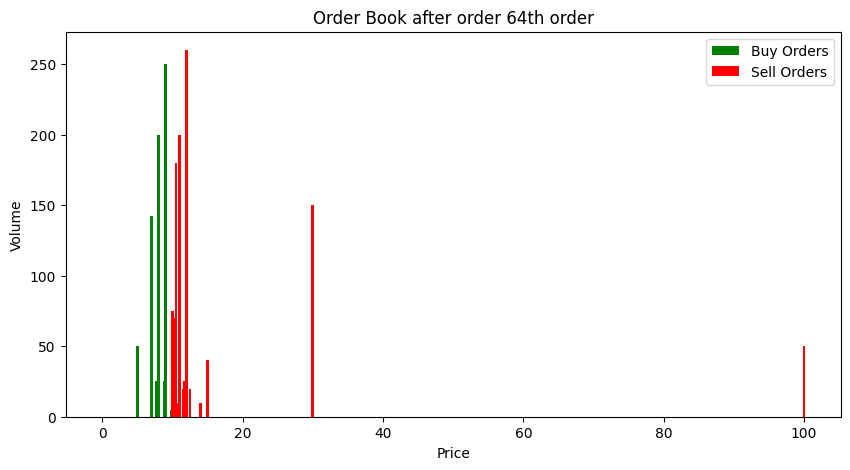

____________________________________________________________________________________
____________________________________________________________________________________

Order Book after 65th order:
    Bid Size  Bid Price  Ask Price  Ask Size
0          5       9.80      10.00        50
1        250       9.00      10.10        70
2         25       8.88      10.50       180
3        200       8.00      10.60        10
4         25       7.77      10.80        10
5        142       7.00      10.90        10
6         50       5.00      11.00       200
7       <NA>        NaN      11.01        90
8       <NA>        NaN      11.50        20
9       <NA>        NaN      11.75        25
10      <NA>        NaN      11.95        15
11      <NA>        NaN      12.00       260
12      <NA>        NaN      12.50        20
13      <NA>        NaN      14.00        10
14      <NA>        NaN      15.00        40
15      <NA>        NaN      30.00       150
16      <NA>        NaN     100.00 

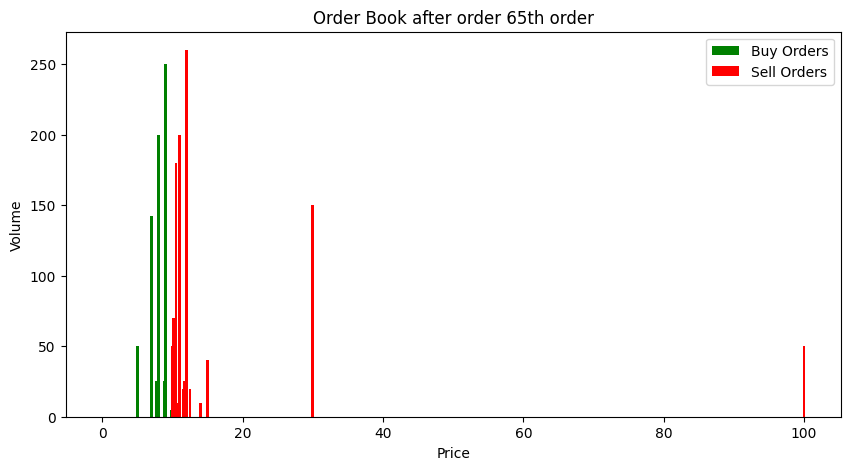

____________________________________________________________________________________
____________________________________________________________________________________

Order Book after 66th order:
    Bid Size  Bid Price  Ask Price  Ask Size
0         25       9.99      10.00        50
1          5       9.80      10.10        70
2        250       9.00      10.50       180
3         25       8.88      10.60        10
4        200       8.00      10.80        10
5         25       7.77      10.90        10
6        142       7.00      11.00       200
7         50       5.00      11.01        90
8       <NA>        NaN      11.50        20
9       <NA>        NaN      11.75        25
10      <NA>        NaN      11.95        15
11      <NA>        NaN      12.00       260
12      <NA>        NaN      12.50        20
13      <NA>        NaN      14.00        10
14      <NA>        NaN      15.00        40
15      <NA>        NaN      30.00       150
16      <NA>        NaN     100.00 

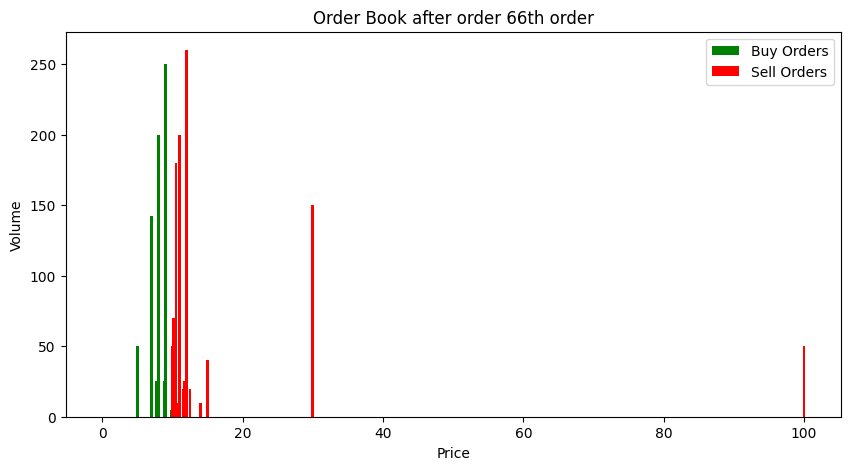

____________________________________________________________________________________
____________________________________________________________________________________

Order Book after 67th order:
    Bid Size  Bid Price  Ask Price  Ask Size
0         25       9.99      10.00        80
1          5       9.80      10.10        70
2        250       9.00      10.50       180
3         25       8.88      10.60        10
4        200       8.00      10.80        10
5         25       7.77      10.90        10
6        142       7.00      11.00       200
7         50       5.00      11.01        90
8       <NA>        NaN      11.50        20
9       <NA>        NaN      11.75        25
10      <NA>        NaN      11.95        15
11      <NA>        NaN      12.00       260
12      <NA>        NaN      12.50        20
13      <NA>        NaN      14.00        10
14      <NA>        NaN      15.00        40
15      <NA>        NaN      30.00       150
16      <NA>        NaN     100.00 

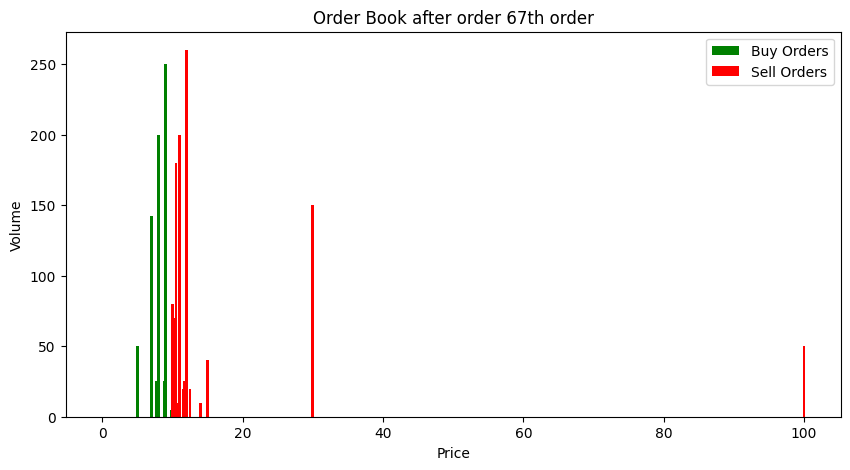

____________________________________________________________________________________
____________________________________________________________________________________

Order Book after 68th order:
    Bid Size  Bid Price  Ask Price  Ask Size
0         25       9.99      10.00        80
1          5       9.80      10.10        70
2          5       9.75      10.50       180
3        250       9.00      10.60        10
4         25       8.88      10.80        10
5        200       8.00      10.90        10
6         25       7.77      11.00       200
7        142       7.00      11.01        90
8         50       5.00      11.50        20
9       <NA>        NaN      11.75        25
10      <NA>        NaN      11.95        15
11      <NA>        NaN      12.00       260
12      <NA>        NaN      12.50        20
13      <NA>        NaN      14.00        10
14      <NA>        NaN      15.00        40
15      <NA>        NaN      30.00       150
16      <NA>        NaN     100.00 

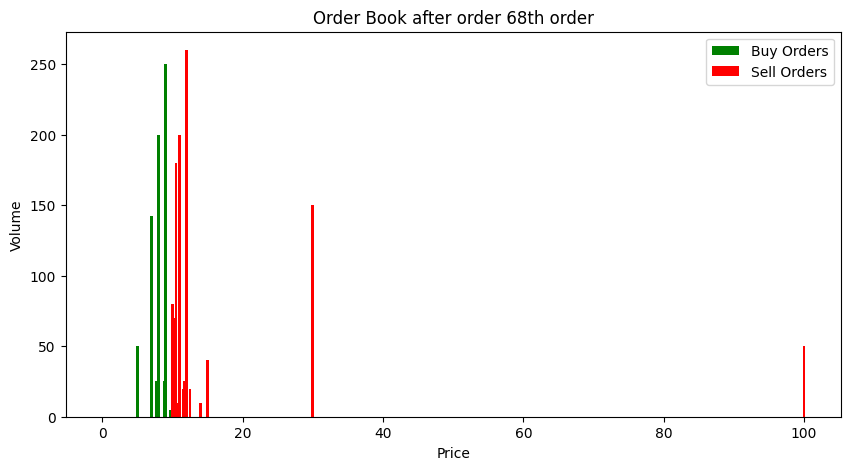

____________________________________________________________________________________
____________________________________________________________________________________

Order Book after 69th order:
    Bid Size  Bid Price  Ask Price  Ask Size
0         25       9.99      10.00        80
1          5       9.80      10.10        70
2          5       9.75      10.50       180
3         20       9.10      10.60        10
4        250       9.00      10.80        10
5         25       8.88      10.90        10
6        200       8.00      11.00       200
7         25       7.77      11.01        90
8        142       7.00      11.50        20
9         50       5.00      11.75        25
10      <NA>        NaN      11.95        15
11      <NA>        NaN      12.00       260
12      <NA>        NaN      12.50        20
13      <NA>        NaN      14.00        10
14      <NA>        NaN      15.00        40
15      <NA>        NaN      30.00       150
16      <NA>        NaN     100.00 

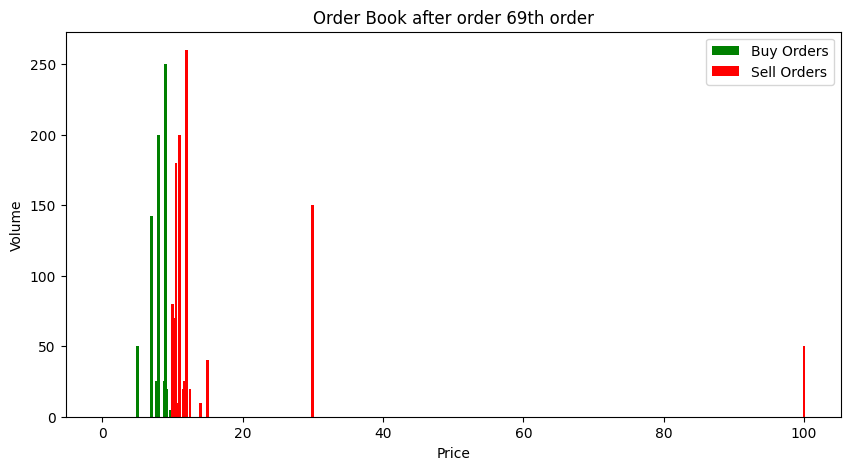

____________________________________________________________________________________
____________________________________________________________________________________

Order Book after 70th order:
    Bid Size  Bid Price  Ask Price  Ask Size
0         25       9.99      10.00        80
1          5       9.80      10.10        70
2          5       9.75      10.50       180
3         10       9.53      10.60        10
4         20       9.10      10.80        10
5        250       9.00      10.90        10
6         25       8.88      11.00       200
7        200       8.00      11.01        90
8         25       7.77      11.50        20
9        142       7.00      11.75        25
10        50       5.00      11.95        15
11      <NA>        NaN      12.00       260
12      <NA>        NaN      12.50        20
13      <NA>        NaN      14.00        10
14      <NA>        NaN      15.00        40
15      <NA>        NaN      30.00       150
16      <NA>        NaN     100.00 

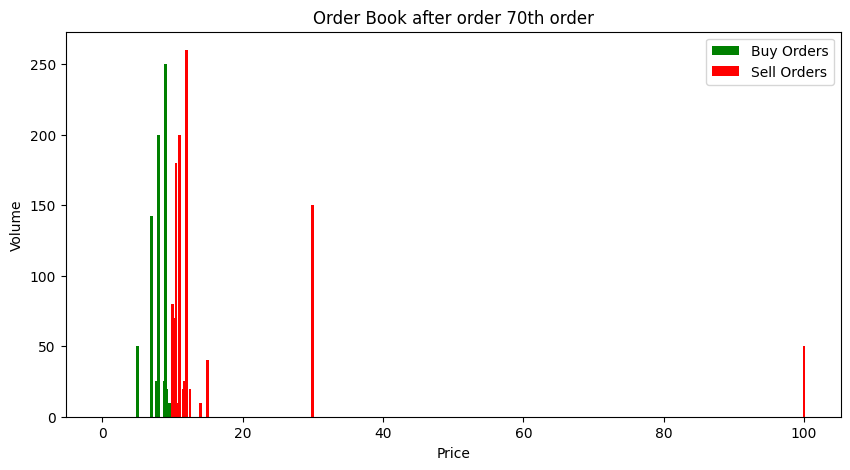

____________________________________________________________________________________
____________________________________________________________________________________

Order Book after 71th order:
    Bid Size  Bid Price  Ask Price  Ask Size
0         25       9.99      10.00        80
1          5       9.80      10.10        70
2          5       9.75      10.50       180
3          5       9.70      10.60        10
4         10       9.53      10.80        10
5         20       9.10      10.90        10
6        250       9.00      11.00       200
7         25       8.88      11.01        90
8        200       8.00      11.50        20
9         25       7.77      11.75        25
10       142       7.00      11.95        15
11        50       5.00      12.00       260
12      <NA>        NaN      12.50        20
13      <NA>        NaN      14.00        10
14      <NA>        NaN      15.00        40
15      <NA>        NaN      30.00       150
16      <NA>        NaN     100.00 

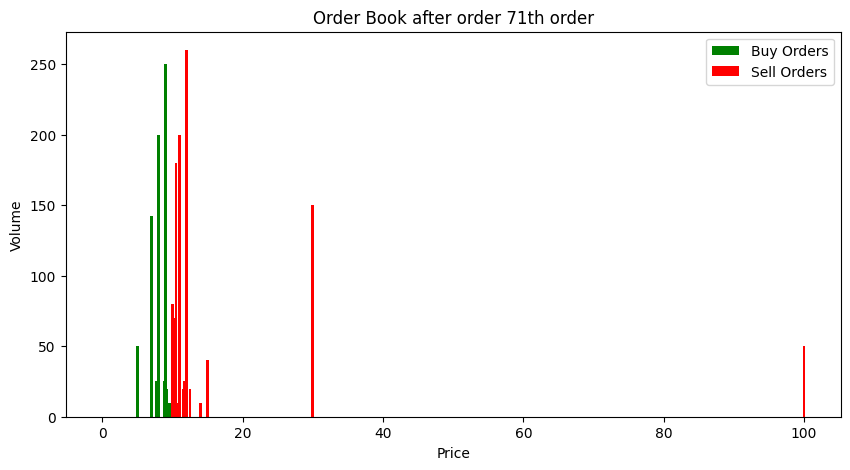

____________________________________________________________________________________
____________________________________________________________________________________

Order Book after 72th order:
    Bid Size  Bid Price  Ask Price  Ask Size
0         25       9.99      10.00        80
1          5       9.80      10.10        70
2          5       9.75      10.50       180
3          5       9.70      10.60        10
4         10       9.53      10.75        20
5         20       9.10      10.80        10
6        250       9.00      10.90        10
7         25       8.88      11.00       200
8        200       8.00      11.01        90
9         25       7.77      11.50        20
10       142       7.00      11.75        25
11        50       5.00      11.95        15
12      <NA>        NaN      12.00       260
13      <NA>        NaN      12.50        20
14      <NA>        NaN      14.00        10
15      <NA>        NaN      15.00        40
16      <NA>        NaN      30.00 

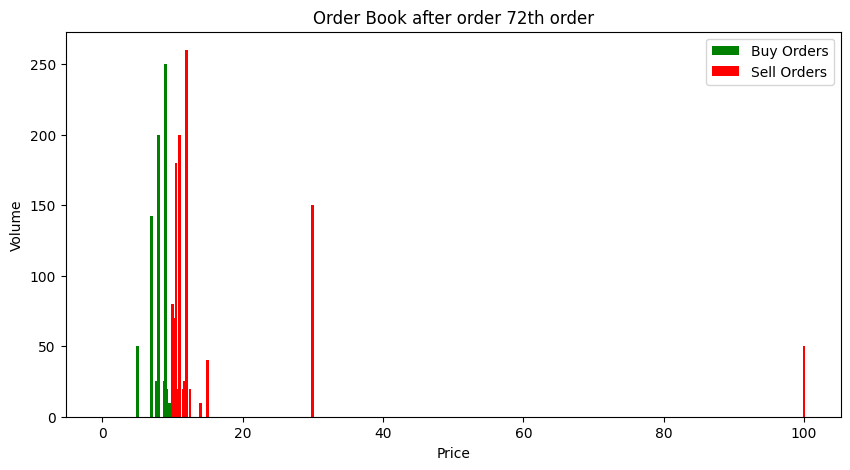

____________________________________________________________________________________
____________________________________________________________________________________

Order Book after 73th order:
    Bid Size  Bid Price  Ask Price  Ask Size
0         25       9.99      10.00        80
1          5       9.80      10.10        70
2          5       9.75      10.50       180
3          5       9.70      10.60        10
4         10       9.53      10.75        20
5         20       9.10      10.80        10
6        280       9.00      10.90        10
7         25       8.88      11.00       200
8        200       8.00      11.01        90
9         25       7.77      11.50        20
10       142       7.00      11.75        25
11        50       5.00      11.95        15
12      <NA>        NaN      12.00       260
13      <NA>        NaN      12.50        20
14      <NA>        NaN      14.00        10
15      <NA>        NaN      15.00        40
16      <NA>        NaN      30.00 

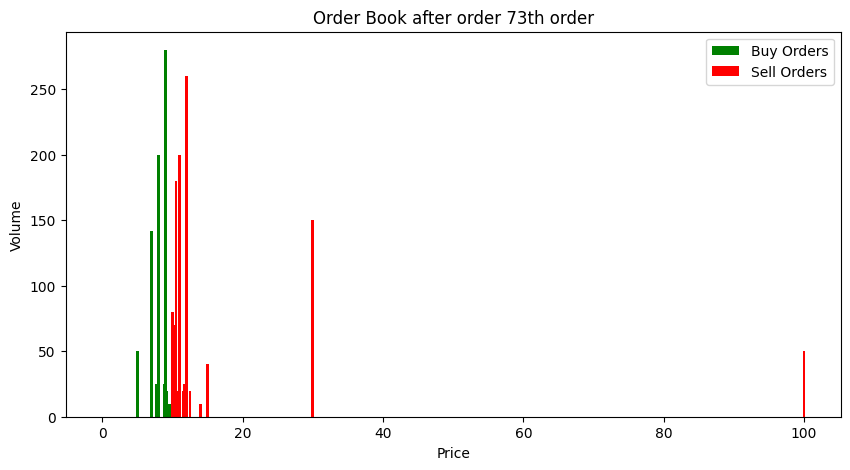

____________________________________________________________________________________
____________________________________________________________________________________

Order Book after 74th order:
    Bid Size  Bid Price  Ask Price  Ask Size
0         25       9.99      10.00        80
1          5       9.80      10.10        70
2          5       9.75      10.50       180
3          5       9.70      10.60        10
4         10       9.53      10.75        20
5         30       9.50      10.80        10
6         20       9.10      10.90        10
7        280       9.00      11.00       200
8         25       8.88      11.01        90
9        200       8.00      11.50        20
10        25       7.77      11.75        25
11       142       7.00      11.95        15
12        50       5.00      12.00       260
13      <NA>        NaN      12.50        20
14      <NA>        NaN      14.00        10
15      <NA>        NaN      15.00        40
16      <NA>        NaN      30.00 

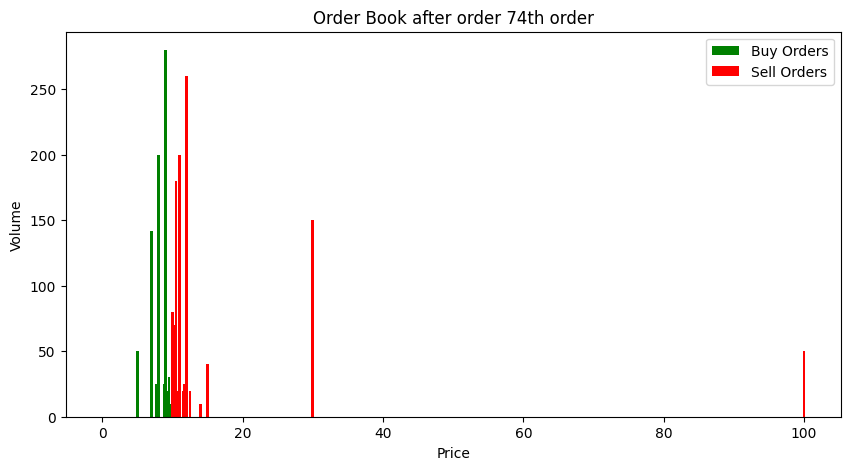

____________________________________________________________________________________
____________________________________________________________________________________

Order Book after 75th order:
    Bid Size  Bid Price  Ask Price  Ask Size
0         25       9.99      10.00        80
1          5       9.80      10.10        70
2          5       9.75      10.50       180
3          5       9.70      10.60        10
4          5       9.65      10.75        20
5         10       9.53      10.80        10
6         30       9.50      10.90        10
7         20       9.10      11.00       200
8        280       9.00      11.01        90
9         25       8.88      11.50        20
10       200       8.00      11.75        25
11        25       7.77      11.95        15
12       142       7.00      12.00       260
13        50       5.00      12.50        20
14      <NA>        NaN      14.00        10
15      <NA>        NaN      15.00        40
16      <NA>        NaN      30.00 

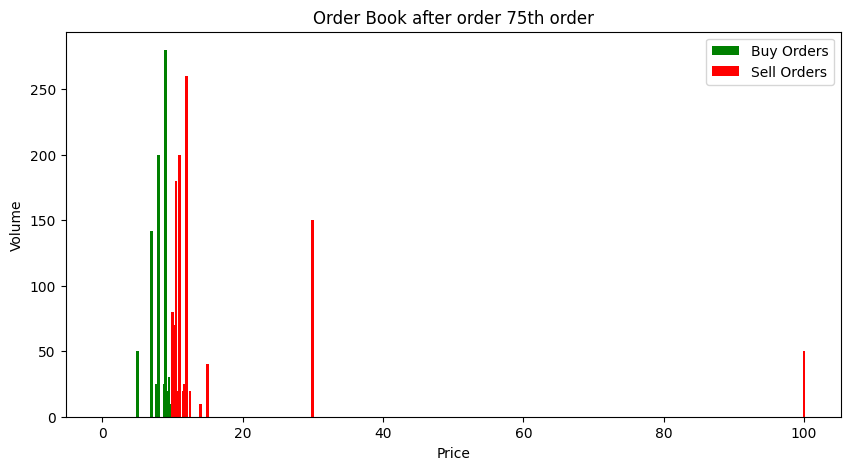

____________________________________________________________________________________
____________________________________________________________________________________

Order Book after 76th order:
    Bid Size  Bid Price  Ask Price  Ask Size
0         25       9.99      10.00        80
1          5       9.80      10.10        70
2          5       9.75      10.50       180
3          5       9.70      10.60        10
4          5       9.65      10.75        20
5         10       9.53      10.80        10
6         30       9.50      10.90        10
7         20       9.10      10.99        10
8        280       9.00      11.00       200
9         25       8.88      11.01        90
10       200       8.00      11.50        20
11        25       7.77      11.75        25
12       142       7.00      11.95        15
13        50       5.00      12.00       260
14      <NA>        NaN      12.50        20
15      <NA>        NaN      14.00        10
16      <NA>        NaN      15.00 

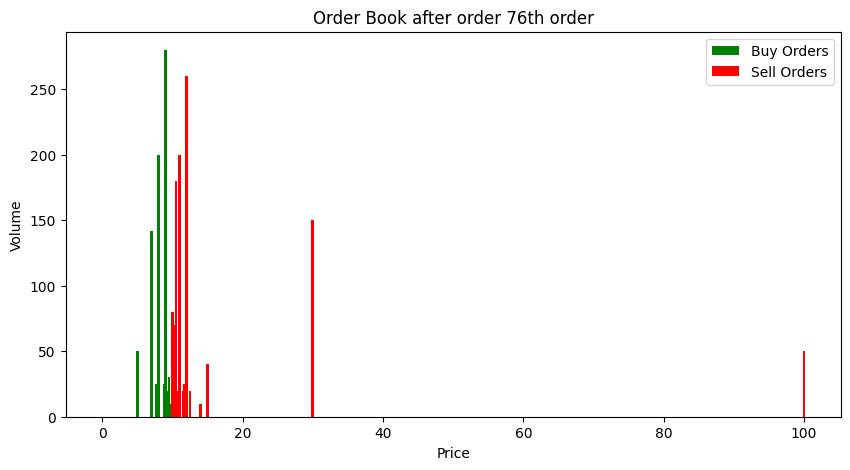

____________________________________________________________________________________
____________________________________________________________________________________

Order Book after 77th order:
    Bid Size  Bid Price  Ask Price  Ask Size
0         25       9.99      10.00        80
1          5       9.80      10.10        70
2          5       9.75      10.50       180
3          5       9.70      10.60        10
4          5       9.65      10.75        20
5         10       9.53      10.80        10
6         30       9.50      10.90        10
7         20       9.10      10.99        10
8        280       9.00      11.00       200
9         25       8.88      11.01        90
10        10       8.80      11.50        20
11       200       8.00      11.75        25
12        25       7.77      11.95        15
13       142       7.00      12.00       260
14        50       5.00      12.50        20
15      <NA>        NaN      14.00        10
16      <NA>        NaN      15.00 

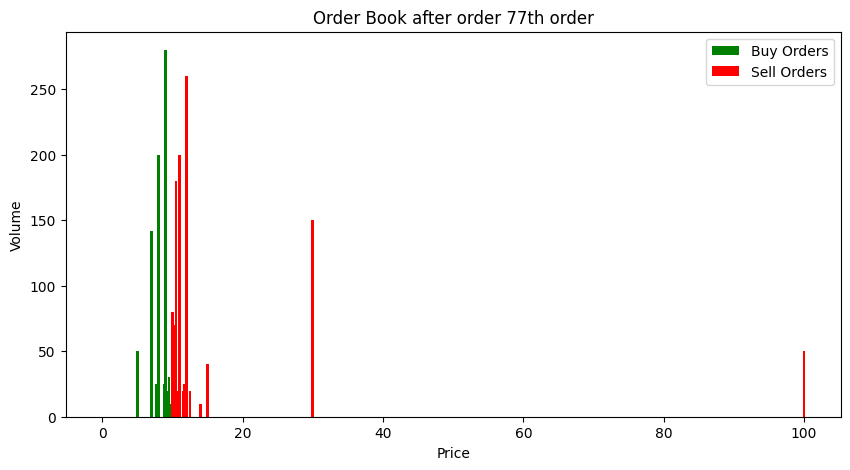

____________________________________________________________________________________
____________________________________________________________________________________

Order Book after 78th order:
    Bid Size  Bid Price  Ask Price  Ask Size
0         25       9.99      10.00        80
1          5       9.80      10.10        70
2          5       9.75      10.50       180
3          5       9.70      10.60        10
4          5       9.65      10.75        20
5         10       9.53      10.80        10
6         30       9.50      10.90        10
7         20       9.10      10.99        10
8        317       9.00      11.00       200
9         25       8.88      11.01        90
10        10       8.80      11.50        20
11       200       8.00      11.75        25
12        25       7.77      11.95        15
13       142       7.00      12.00       260
14        50       5.00      12.50        20
15      <NA>        NaN      14.00        10
16      <NA>        NaN      15.00 

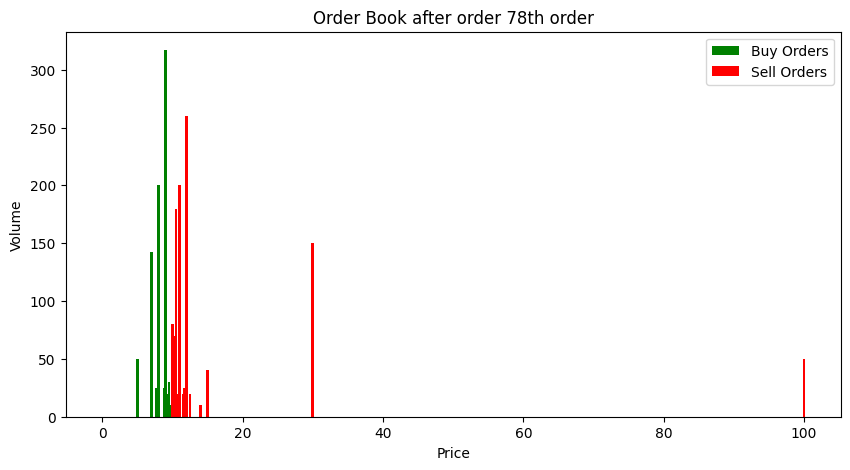

____________________________________________________________________________________
____________________________________________________________________________________

Order Book after 79th order:
    Bid Size  Bid Price  Ask Price  Ask Size
0         25       9.99      10.00        80
1          5       9.80      10.10        70
2          5       9.75      10.50       180
3          5       9.70      10.60        10
4          5       9.65      10.75        20
5         10       9.53      10.80        10
6         30       9.50      10.90        10
7         20       9.10      10.99        10
8        317       9.00      11.00       200
9         25       8.88      11.01        90
10        35       8.80      11.50        20
11       200       8.00      11.75        25
12        25       7.77      11.95        15
13       142       7.00      12.00       260
14        50       5.00      12.50        20
15      <NA>        NaN      14.00        10
16      <NA>        NaN      15.00 

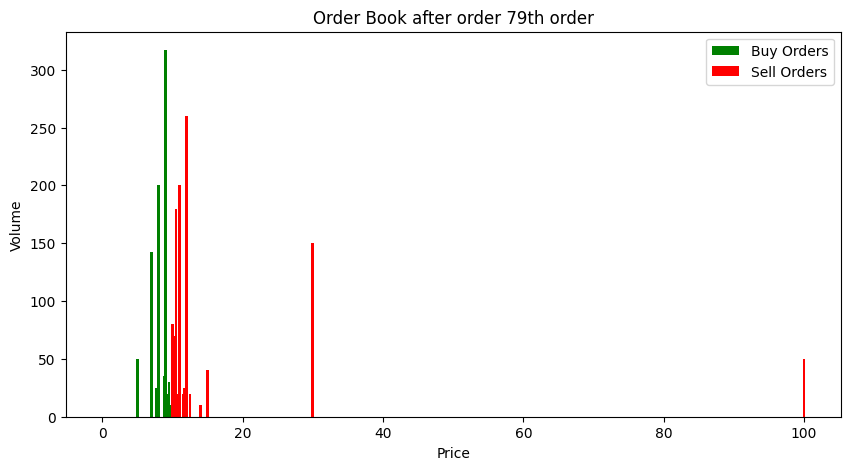

____________________________________________________________________________________
____________________________________________________________________________________

Order Book after 80th order:
    Bid Size  Bid Price  Ask Price  Ask Size
0         25       9.99      10.00        80
1          5       9.80      10.10        70
2          5       9.75      10.50       180
3          5       9.70      10.60        10
4          5       9.65      10.75        20
5          5       9.60      10.80        10
6         10       9.53      10.90        10
7         30       9.50      10.99        10
8         20       9.10      11.00       200
9        317       9.00      11.01        90
10        25       8.88      11.50        20
11        35       8.80      11.75        25
12       200       8.00      11.95        15
13        25       7.77      12.00       260
14       142       7.00      12.50        20
15        50       5.00      14.00        10
16      <NA>        NaN      15.00 

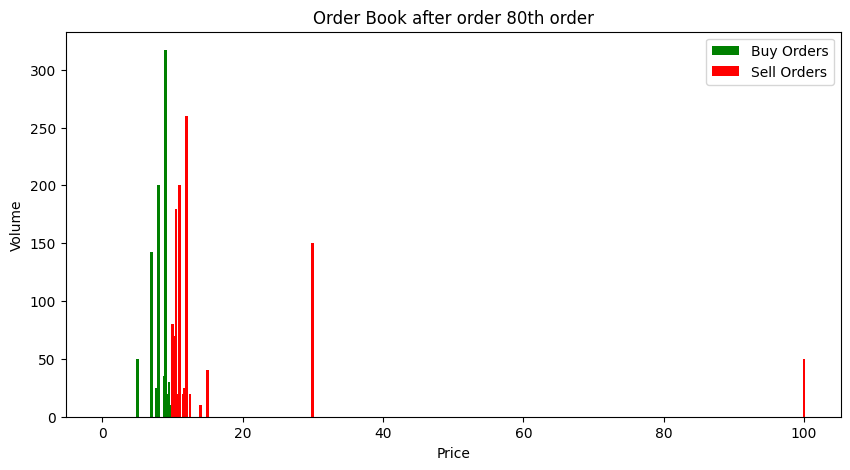

____________________________________________________________________________________
____________________________________________________________________________________

Order Book after 81th order:
    Bid Size  Bid Price  Ask Price  Ask Size
0         25       9.99      10.00        80
1          5       9.80      10.10        70
2          5       9.75      10.50       180
3          5       9.70      10.60        10
4          5       9.65      10.75        20
5          5       9.60      10.80        10
6         10       9.53      10.90        10
7         30       9.50      10.99        10
8         20       9.10      11.00       200
9        317       9.00      11.01        90
10        25       8.88      11.50        20
11        35       8.80      11.75        25
12        20       8.70      11.95        15
13       200       8.00      12.00       260
14        25       7.77      12.50        20
15       142       7.00      14.00        10
16        50       5.00      15.00 

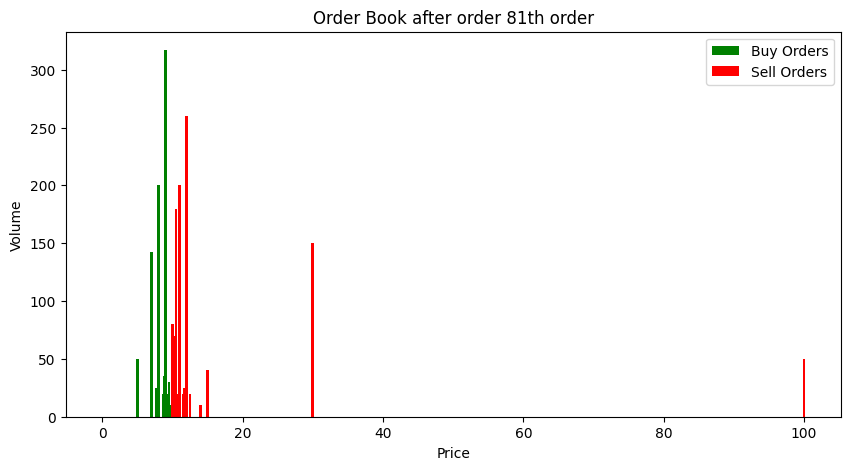

____________________________________________________________________________________
____________________________________________________________________________________

Order Book after 82th order:
    Bid Size  Bid Price  Ask Price  Ask Size
0         25       9.99      10.00        80
1          5       9.80      10.10        70
2          5       9.75      10.50       180
3          5       9.70      10.60        10
4          5       9.65      10.75        20
5          5       9.60      10.80        10
6          5       9.55      10.90        10
7         10       9.53      10.99        10
8         30       9.50      11.00       200
9         20       9.10      11.01        90
10       317       9.00      11.50        20
11        25       8.88      11.75        25
12        35       8.80      11.95        15
13        20       8.70      12.00       260
14       200       8.00      12.50        20
15        25       7.77      14.00        10
16       142       7.00      15.00 

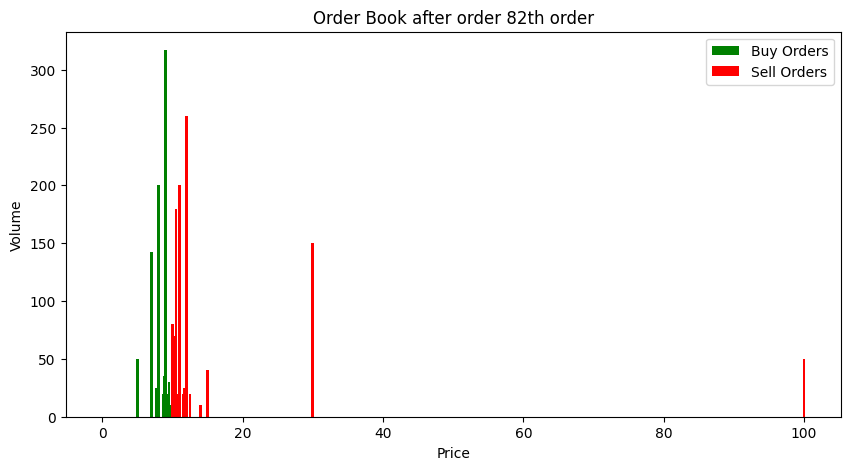

____________________________________________________________________________________
____________________________________________________________________________________

Order Book after 83th order:
    Bid Size  Bid Price  Ask Price  Ask Size
0         25       9.99      10.00        80
1          5       9.80      10.10        70
2          5       9.75      10.50       180
3          5       9.70      10.60        10
4          5       9.65      10.75        20
5          5       9.60      10.76        20
6          5       9.55      10.80        10
7         10       9.53      10.90        10
8         30       9.50      10.99        10
9         20       9.10      11.00       200
10       317       9.00      11.01        90
11        25       8.88      11.50        20
12        35       8.80      11.75        25
13        20       8.70      11.95        15
14       200       8.00      12.00       260
15        25       7.77      12.50        20
16       142       7.00      14.00 

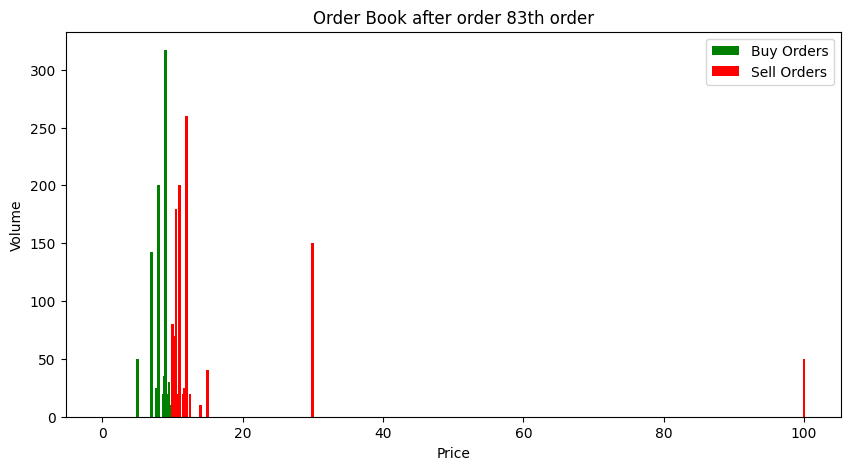

____________________________________________________________________________________
____________________________________________________________________________________

Order Book after 84th order:
    Bid Size  Bid Price  Ask Price  Ask Size
0         25       9.99      10.00        80
1          5       9.80      10.10        70
2          5       9.75      10.50       200
3          5       9.70      10.60        10
4          5       9.65      10.75        20
5          5       9.60      10.76        20
6          5       9.55      10.80        10
7         10       9.53      10.90        10
8         30       9.50      10.99        10
9         20       9.10      11.00       200
10       317       9.00      11.01        90
11        25       8.88      11.50        20
12        35       8.80      11.75        25
13        20       8.70      11.95        15
14       200       8.00      12.00       260
15        25       7.77      12.50        20
16       142       7.00      14.00 

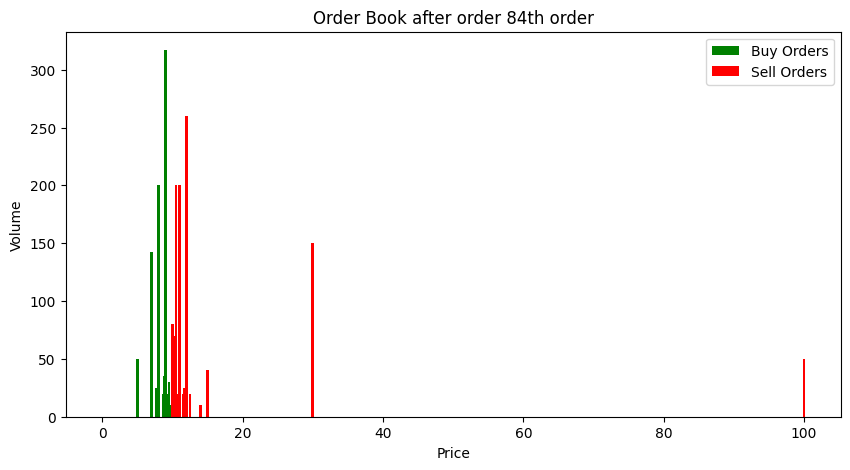

____________________________________________________________________________________
____________________________________________________________________________________

Order Book after 85th order:
    Bid Size  Bid Price  Ask Price  Ask Size
0        170      10.00      10.10        70
1         25       9.99      10.50       200
2          5       9.80      10.60        10
3          5       9.75      10.75        20
4          5       9.70      10.76        20
5          5       9.65      10.80        10
6          5       9.60      10.90        10
7          5       9.55      10.99        10
8         10       9.53      11.00       200
9         30       9.50      11.01        90
10        20       9.10      11.50        20
11       317       9.00      11.75        25
12        25       8.88      11.95        15
13        35       8.80      12.00       260
14        20       8.70      12.50        20
15       200       8.00      14.00        10
16        25       7.77      15.00 

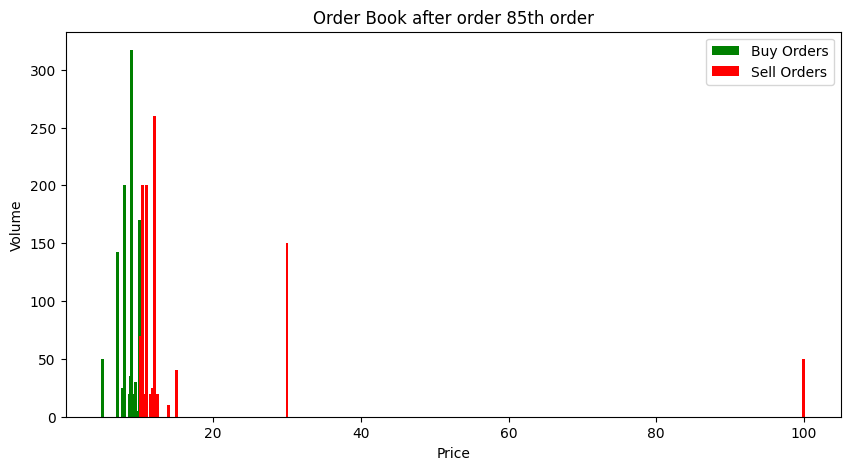

____________________________________________________________________________________
____________________________________________________________________________________

Order Book after 86th order:
    Bid Size  Bid Price  Ask Price  Ask Size
0        170      10.00      10.10        70
1         25       9.99      10.50       200
2          5       9.80      10.60        10
3          5       9.75      10.75        20
4          5       9.70      10.76        20
5          5       9.65      10.80        10
6          5       9.60      10.90        10
7          5       9.55      10.99        10
8         10       9.53      11.00       200
9         30       9.50      11.01        90
10        20       9.10      11.50        20
11       347       9.00      11.75        25
12        25       8.88      11.95        15
13        35       8.80      12.00       260
14        20       8.70      12.50        20
15       200       8.00      14.00        10
16        25       7.77      15.00 

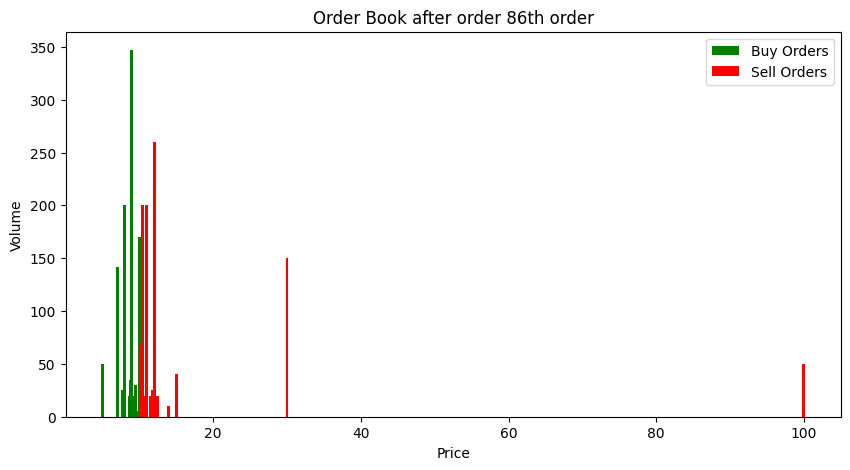

____________________________________________________________________________________
____________________________________________________________________________________

Order Book after 87th order:
    Bid Size  Bid Price  Ask Price  Ask Size
0        170      10.00      10.10        70
1         25       9.99      10.50       200
2          5       9.80      10.60        10
3          5       9.75      10.75        20
4          5       9.70      10.76        20
5          5       9.65      10.80        10
6          5       9.60      10.90        10
7          5       9.55      10.99        10
8         10       9.53      11.00       200
9         30       9.50      11.01        90
10        20       9.10      11.50        20
11       347       9.00      11.75        25
12        25       8.88      11.95        15
13        35       8.80      12.00       260
14        20       8.70      12.50        20
15       200       8.00      14.00        10
16        25       7.77      15.00 

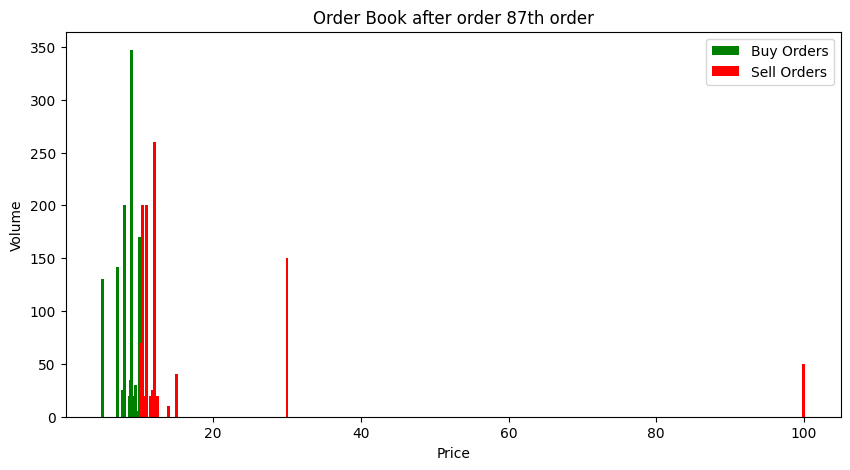

____________________________________________________________________________________
____________________________________________________________________________________

Order Book after 88th order:
    Bid Size  Bid Price  Ask Price  Ask Size
0        170      10.00      10.10        70
1         25       9.99      10.50       200
2          5       9.80      10.60        10
3          5       9.75      10.75        20
4          5       9.70      10.76        20
5          5       9.65      10.80        10
6          5       9.60      10.90        10
7          5       9.55      10.99        10
8         10       9.53      11.00       200
9         30       9.50      11.01        90
10        20       9.10      11.50        20
11       347       9.00      11.75        25
12        25       8.88      11.95        15
13        35       8.80      12.00       260
14        20       8.70      12.50        20
15        10       8.60      14.00        10
16       200       8.00      15.00 

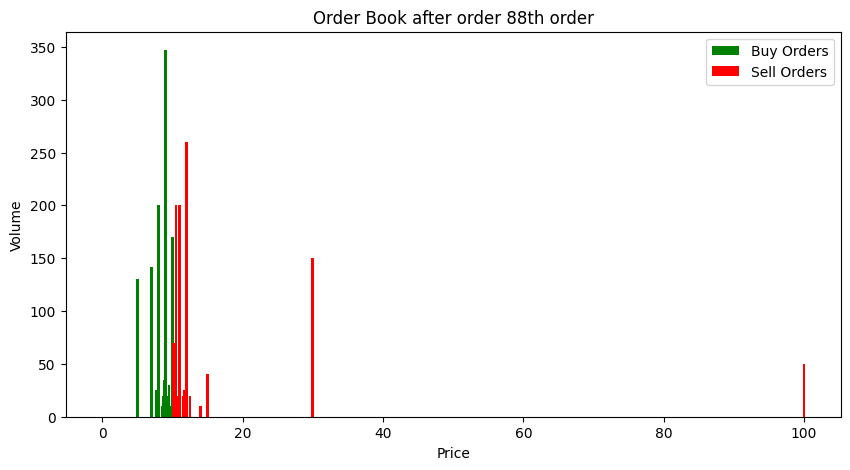

____________________________________________________________________________________
____________________________________________________________________________________

Order Book after 89th order:
    Bid Size  Bid Price  Ask Price  Ask Size
0        155      10.00      10.10        70
1         25       9.99      10.50       200
2          5       9.80      10.60        10
3          5       9.75      10.75        20
4          5       9.70      10.76        20
5          5       9.65      10.80        10
6          5       9.60      10.90        10
7          5       9.55      10.99        10
8         10       9.53      11.00       200
9         30       9.50      11.01        90
10        20       9.10      11.50        20
11       347       9.00      11.75        25
12        25       8.88      11.95        15
13        35       8.80      12.00       260
14        20       8.70      12.50        20
15        10       8.60      14.00        10
16       200       8.00      15.00 

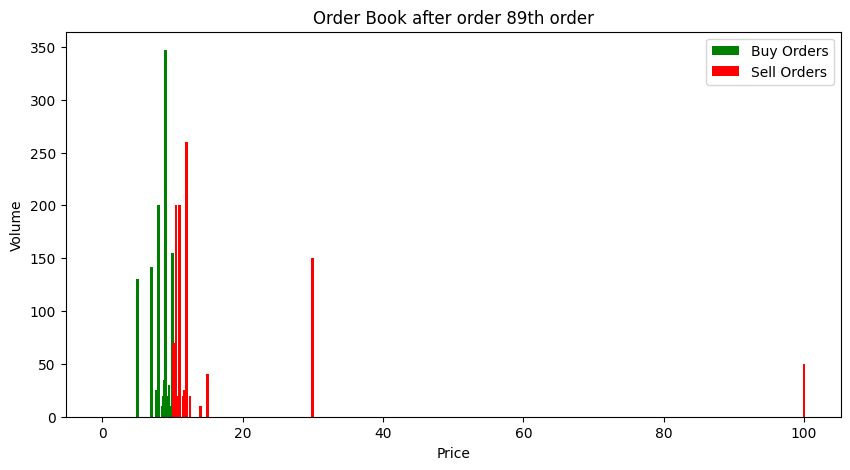

____________________________________________________________________________________
____________________________________________________________________________________

Order Book after 90th order:
    Bid Size  Bid Price  Ask Price  Ask Size
0        155      10.00      10.10        70
1         25       9.99      10.50       200
2          5       9.80      10.60        10
3          5       9.75      10.75        20
4          5       9.70      10.76        20
5          5       9.65      10.80        10
6          5       9.60      10.90        10
7          5       9.55      10.99        10
8         10       9.53      11.00       200
9         30       9.50      11.01        90
10        20       9.10      11.50        20
11       347       9.00      11.75        25
12        25       8.88      11.95        15
13        35       8.80      12.00       260
14        20       8.70      12.50        20
15        10       8.60      14.00        10
16        10       8.50      15.00 

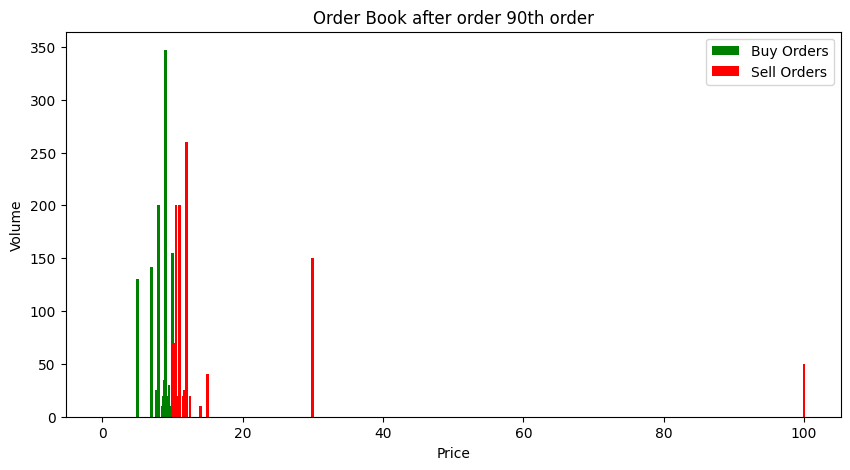

____________________________________________________________________________________
____________________________________________________________________________________

Order Book after 91th order:
    Bid Size  Bid Price  Ask Price  Ask Size
0        155      10.00      10.10        70
1         25       9.99      10.50       200
2          5       9.80      10.60        10
3          5       9.75      10.75        40
4          5       9.70      10.76        20
5          5       9.65      10.80        10
6          5       9.60      10.90        10
7          5       9.55      10.99        10
8         10       9.53      11.00       200
9         30       9.50      11.01        90
10        20       9.10      11.50        20
11       347       9.00      11.75        25
12        25       8.88      11.95        15
13        35       8.80      12.00       260
14        20       8.70      12.50        20
15        10       8.60      14.00        10
16        10       8.50      15.00 

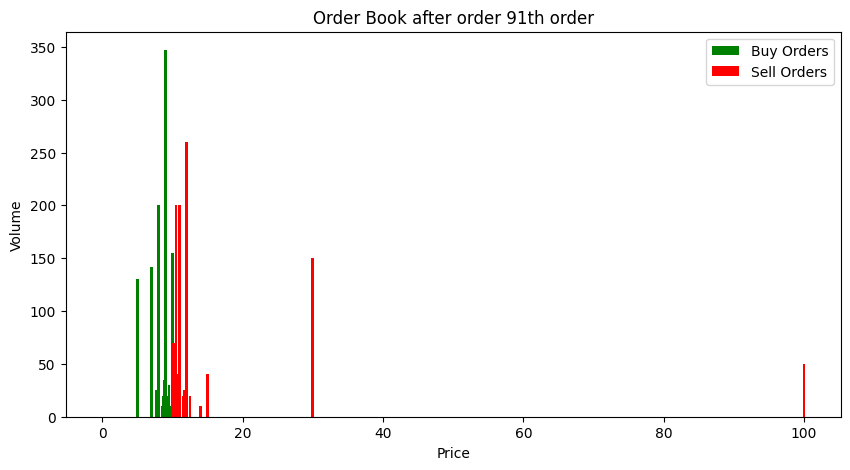

____________________________________________________________________________________
____________________________________________________________________________________

Order Book after 92th order:
    Bid Size  Bid Price  Ask Price  Ask Size
0        155      10.00      10.10        70
1         25       9.99      10.50       200
2          5       9.80      10.60        10
3          5       9.75      10.75        40
4          5       9.70      10.76        20
5          5       9.65      10.77        40
6          5       9.60      10.80        10
7          5       9.55      10.90        10
8         10       9.53      10.99        10
9         30       9.50      11.00       200
10        20       9.10      11.01        90
11       347       9.00      11.50        20
12        25       8.88      11.75        25
13        35       8.80      11.95        15
14        20       8.70      12.00       260
15        10       8.60      12.50        20
16        10       8.50      14.00 

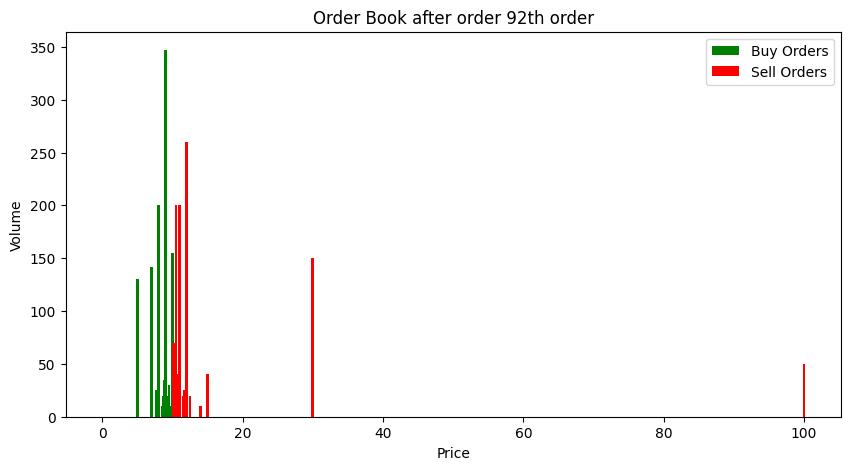

____________________________________________________________________________________
____________________________________________________________________________________

Order Book after 93th order:
    Bid Size  Bid Price  Ask Price  Ask Size
0        155      10.00      10.10        70
1         25       9.99      10.50       200
2          5       9.80      10.60        10
3          5       9.75      10.75        40
4          5       9.70      10.76        20
5          5       9.65      10.77        40
6          5       9.60      10.80        10
7          5       9.55      10.90        10
8         10       9.53      10.99        10
9         30       9.50      11.00       200
10        20       9.10      11.01        90
11       347       9.00      11.50        20
12        25       8.88      11.75        25
13        35       8.80      11.95        15
14        20       8.70      12.00       260
15        10       8.60      12.50        20
16        10       8.50      14.00 

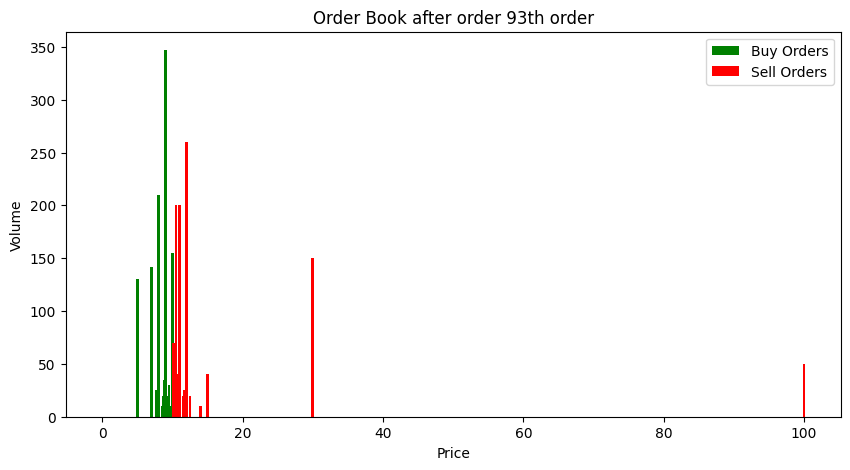

____________________________________________________________________________________
____________________________________________________________________________________

Order Book after 94th order:
    Bid Size  Bid Price  Ask Price  Ask Size
0        155      10.00      10.10        70
1         25       9.99      10.50       200
2          5       9.80      10.60        10
3          5       9.75      10.75        40
4          5       9.70      10.76        20
5          5       9.65      10.77        40
6          5       9.60      10.80        10
7          5       9.55      10.90        10
8         10       9.53      10.99        10
9         30       9.50      11.00       200
10        20       9.10      11.01        90
11        20       9.02      11.50        20
12       347       9.00      11.75        25
13        25       8.88      11.95        15
14        35       8.80      12.00       260
15        20       8.70      12.50        20
16        10       8.60      14.00 

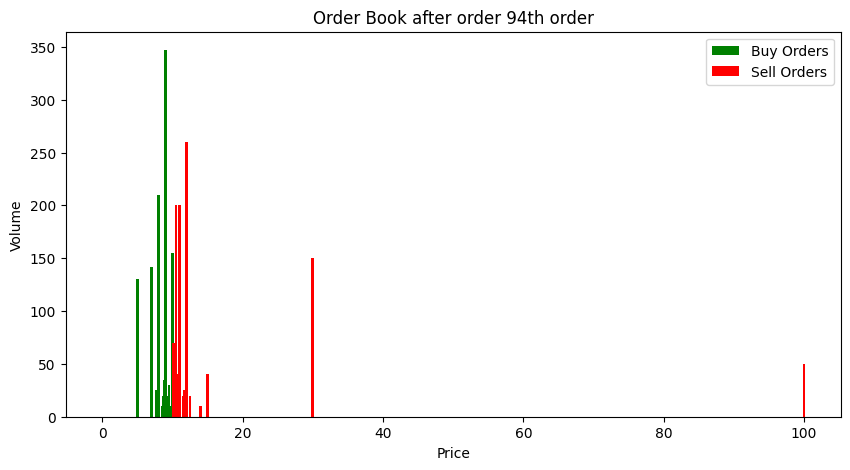

____________________________________________________________________________________
____________________________________________________________________________________

Order Book after 95th order:
    Bid Size  Bid Price  Ask Price  Ask Size
0        155      10.00      10.10        70
1         25       9.99      10.50       200
2          5       9.80      10.60        10
3          5       9.75      10.75        40
4          5       9.70      10.76        20
5          5       9.65      10.77        40
6          5       9.60      10.80        10
7          5       9.55      10.90        10
8         10       9.53      10.99        10
9         30       9.50      11.00       200
10        20       9.10      11.01        90
11        20       9.02      11.50        20
12       347       9.00      11.75        25
13        25       8.88      11.95        15
14        35       8.80      12.00       260
15        20       8.70      12.50        20
16        10       8.60      14.00 

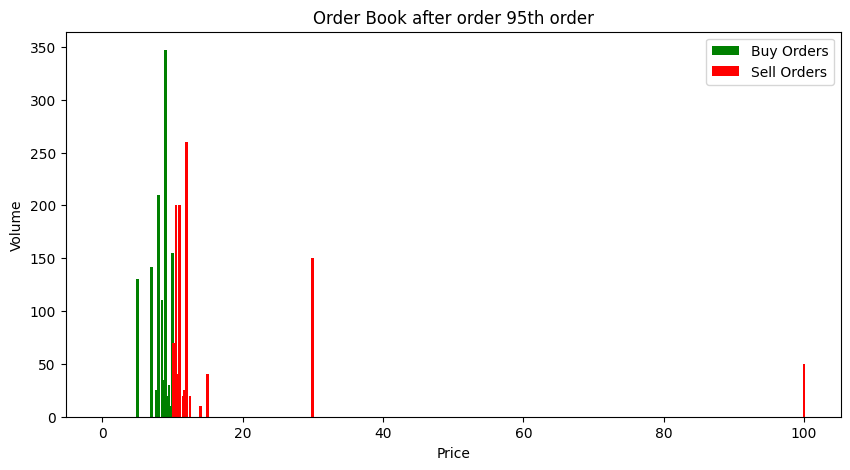

____________________________________________________________________________________
____________________________________________________________________________________

Order Book after 96th order:
    Bid Size  Bid Price  Ask Price  Ask Size
0        140      10.00      10.10        70
1         25       9.99      10.50       200
2          5       9.80      10.60        10
3          5       9.75      10.75        40
4          5       9.70      10.76        20
5          5       9.65      10.77        40
6          5       9.60      10.80        10
7          5       9.55      10.90        10
8         10       9.53      10.99        10
9         30       9.50      11.00       200
10        20       9.10      11.01        90
11        20       9.02      11.50        20
12       347       9.00      11.75        25
13        25       8.88      11.95        15
14        35       8.80      12.00       260
15        20       8.70      12.50        20
16        10       8.60      14.00 

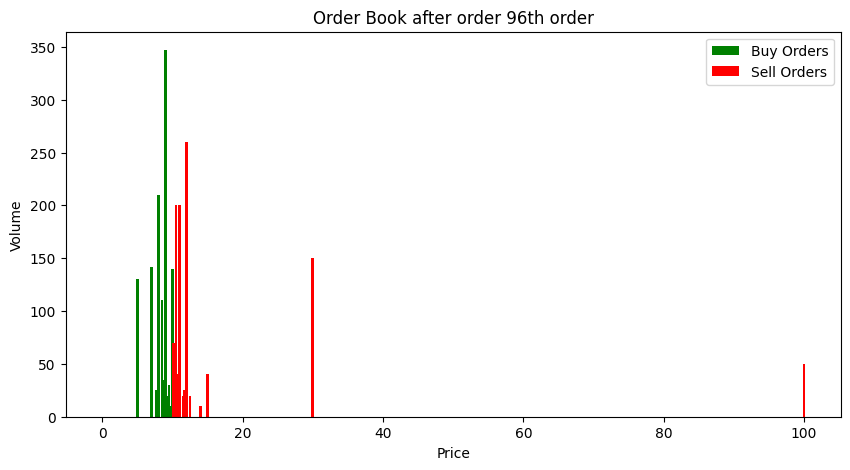

____________________________________________________________________________________
____________________________________________________________________________________

Order Book after 97th order:
    Bid Size  Bid Price  Ask Price  Ask Size
0        140      10.00      10.10        70
1         25       9.99      10.50       200
2          5       9.80      10.60        10
3          5       9.75      10.75        40
4          5       9.70      10.76        20
5          5       9.65      10.77        40
6          5       9.60      10.80        10
7          5       9.55      10.90        10
8         10       9.53      10.99        10
9         30       9.50      11.00       200
10       270       9.10      11.01        90
11        20       9.02      11.50        20
12       347       9.00      11.75        25
13        25       8.88      11.95        15
14        35       8.80      12.00       260
15        20       8.70      12.50        20
16        10       8.60      14.00 

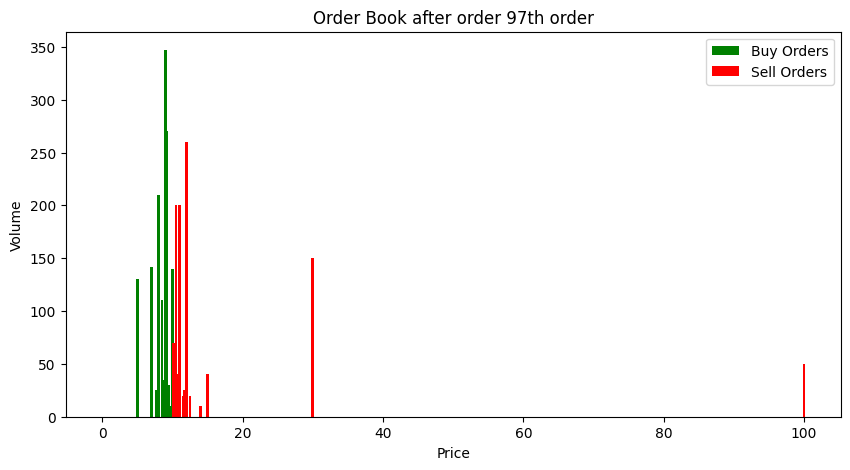

____________________________________________________________________________________
____________________________________________________________________________________

Order Book after 98th order:
    Bid Size  Bid Price  Ask Price  Ask Size
0        140      10.00      10.10        70
1         25       9.99      10.50       200
2          5       9.80      10.60        10
3          5       9.75      10.75        40
4          5       9.70      10.76        20
5          5       9.65      10.77        40
6        505       9.60      10.80        10
7          5       9.55      10.90        10
8         10       9.53      10.99        10
9         30       9.50      11.00       200
10       270       9.10      11.01        90
11        20       9.02      11.50        20
12       347       9.00      11.75        25
13        25       8.88      11.95        15
14        35       8.80      12.00       260
15        20       8.70      12.50        20
16        10       8.60      14.00 

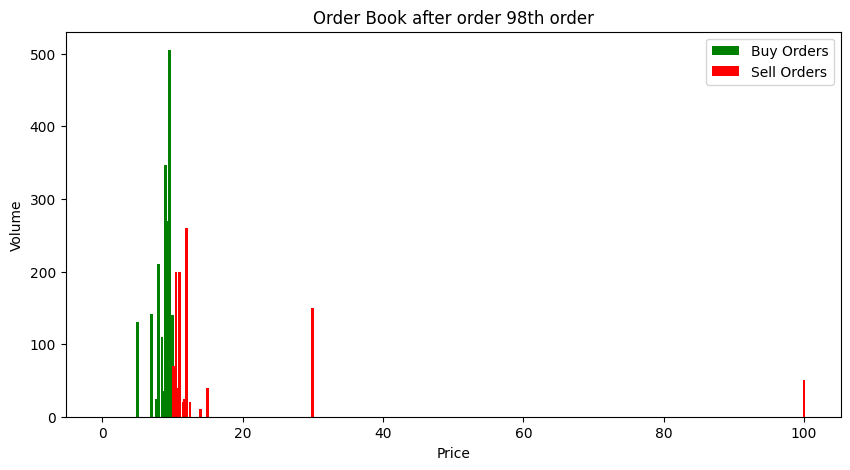

____________________________________________________________________________________
____________________________________________________________________________________

Order Book after 99th order:
    Bid Size  Bid Price  Ask Price  Ask Size
0        140      10.00      10.10        70
1         25       9.99      10.50       200
2          5       9.80      10.60        10
3          5       9.75      10.75        40
4          5       9.70      10.76        20
5          5       9.65      10.77        40
6        505       9.60      10.80        10
7          5       9.55      10.90        10
8         10       9.53      10.99        10
9         30       9.50      11.00       200
10       270       9.10      11.01        90
11        20       9.02      11.50        20
12       347       9.00      11.75        25
13        25       8.88      11.95        15
14        35       8.80      12.00       260
15        20       8.70      12.50        20
16        10       8.60      13.00 

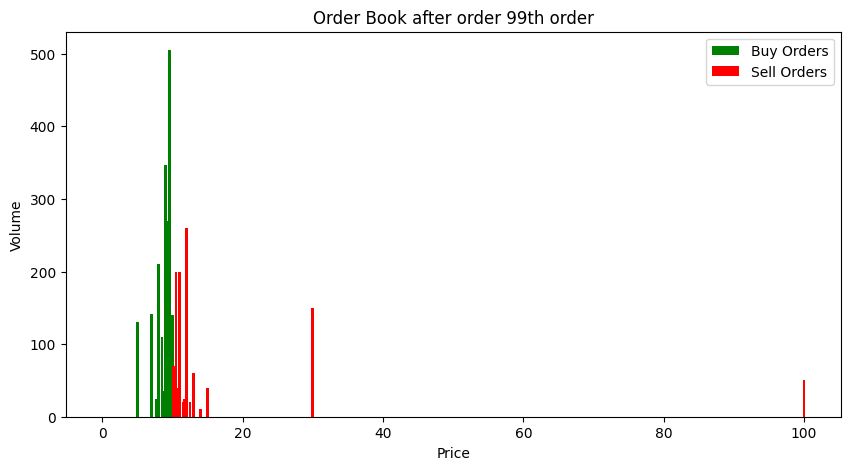

____________________________________________________________________________________
____________________________________________________________________________________

Order Book after 100th order:
    Bid Size  Bid Price  Ask Price  Ask Size
0        140      10.00      10.10        70
1         25       9.99      10.50       200
2          5       9.80      10.60        10
3          5       9.75      10.75        40
4          5       9.70      10.76        20
5          5       9.65      10.77        40
6        505       9.60      10.80        10
7          5       9.55      10.90        10
8         10       9.53      10.99        10
9         30       9.50      11.00       200
10       270       9.10      11.01       100
11        20       9.02      11.50        20
12       347       9.00      11.75        25
13        25       8.88      11.95        15
14        35       8.80      12.00       260
15        20       8.70      12.50        20
16        10       8.60      13.00

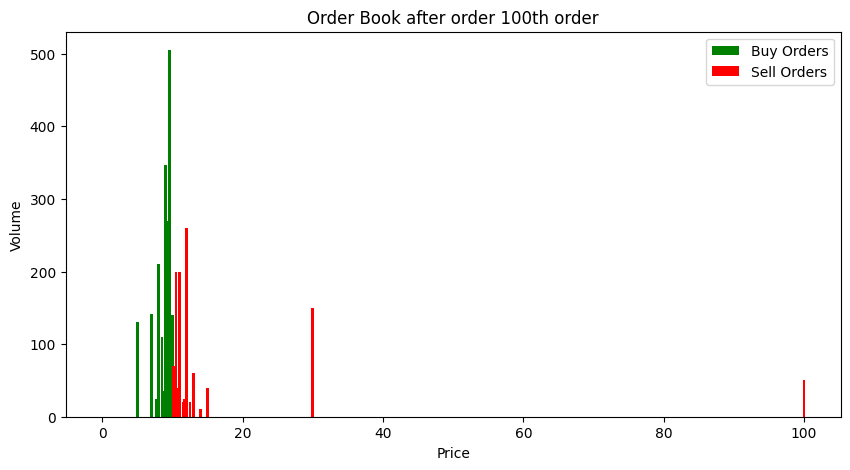

____________________________________________________________________________________


In [17]:
# Initialize the Order Book
order_book = CLOB()

# Add orders from the CSV file
for i, row in orders_df.iterrows():
    timestamp = row['Timestamp']
    side = row['Side'].lower()
    price = row['Price']
    size = row['Size']
    group_number = row['Group ID']

    order_book.add_order(timestamp, side, price, size, group_number)
    
    # Print order book at required stages
    if i in range(len(orders_df)):
        print("____________________________________________________________________________________")
        order_book.print_order_book(f"{i + 1}th order")
        print("____________________________________________________________________________________")